In [193]:
# CHUNK 0 — SETUP + DATA-DRIVEN CLASSIFIER v3
# Validated by K-Means (ARI=0.58) and HMM (ARI=0.62)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import sem, spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, adjusted_rand_score,
                              classification_report)
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from hmmlearn import hmm as hmmlearn
import warnings
import os
warnings.filterwarnings('ignore')

#  Date loading 

Output_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs'
dataframe_path = os.path.join(Output_path, '1-dataframes')

SAVE_PATH = os.path.join(dataframe_path, 'behavioral_states_80_20_updated')
os.makedirs(SAVE_PATH, exist_ok=True)
FIGURE_PATH = os.path.join(Output_path, '2-graphs', 'behavioral_states_80_20_updated')
os.makedirs(FIGURE_PATH, exist_ok=True)

csv_path = os.path.join(SAVE_PATH, 'df_with_states.csv')
df_with_states = pd.read_csv(csv_path)

df_with_states.head()  # optional: inspect

# ── Publication style ─────────────────────────────────────────────────────────
FONTSIZE   = 7
LINE_WIDTH = 0.5
SEED       = 42

# Replace the rcParams font settings with these
plt.rcParams.update({
    'font.size'         : FONTSIZE,
    'axes.linewidth'    : LINE_WIDTH,
    'xtick.major.width' : LINE_WIDTH,
    'ytick.major.width' : LINE_WIDTH,
    'xtick.major.size'  : 3,
    'ytick.major.size'  : 3,
    'font.family'       : 'Arial',     # ← explicit, widely available
    'pdf.fonttype'      : 42,          # ← embeds fonts in PDF
    'svg.fonttype'      : 'none',      # ← convert text to paths in SVG
                                       #   guarantees rendering everywhere
})


# ── Color palettes ────────────────────────────────────────────────────────────
STATE_COLORS = {
    'Engaged'    : '#1abc9c',
    'Exploration': '#f39c12',
    'Left Bias'  : '#3498db',
    'Right Bias' : '#e74c3c',
    'Bias'       : '#8e44ad',
}

ANIMAL_COLORS = {
    'Coral': '#e74c3c',      # Coral/Red
    'Raven': '#2ecc71',      # Green
    'Tuna': '#8b7355',       # Brown/Tan
    'Sonic': '#34495e',      # Dark Gray
    'Griffin': '#9b59b6',    # Purple
    'Sunflower': '#1abc9c',  # Teal/Cyan
    'Zazu': '#3498db',       # Light Blue
    'Salmon': '#f39c12',     # Orange/Yellow
    'Fiona':  '#e91e63',      # Pink/Magenta
    'Knuckles': '#e67e22'    # Orange/Brown
}

CLASSES_V3        = ['Engaged', 'Exploration', 'Left Bias', 'Right Bias']
CLASSES_V3_MERGED = ['Bias', 'Engaged', 'Exploration']

# ── Helper functions ──────────────────────────────────────────────────────────
def hungarian_match(true_labels, cluster_labels, label_names, n_clusters):
    """Match cluster IDs to state names via Hungarian algorithm."""
    n            = len(label_names)
    label_to_idx = {l: i for i, l in enumerate(label_names)}
    true_idx     = np.array([label_to_idx[l] for l in true_labels])
    cost = np.zeros((n, n_clusters))
    for i in range(n):
        for j in range(n_clusters):
            cost[i, j] = -np.sum((true_idx == i) & (cluster_labels == j))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping, matched = {}, set()
    for r, c in zip(row_ind, col_ind):
        mapping[c] = label_names[r]; matched.add(c)
    for j in range(n_clusters):
        if j not in matched:
            mapping[j] = f'Cluster_{j}'
    return mapping

def binary_entropy(p):
    """Binary entropy in bits."""
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def bar_with_dots(ax, data_col, group_col, groups, colors,
                  dot_col='Animal_Name', dot_colors=None,
                  ylabel='', title='', chance=None, ylim=None):
    """Publication bar + per-animal dot plot."""
    x = np.arange(len(groups))
    for i, grp in enumerate(groups):
        vals = data_col[group_col == grp].dropna()
        m, s = vals.mean(), sem(vals) if len(vals) > 1 else 0
        ax.bar(i, m, 0.6, color=colors[grp],
               edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
        ax.errorbar(i, m, yerr=s, fmt='none',
                    color='black', capsize=2, linewidth=LINE_WIDTH, zorder=3)
    if dot_col is not None and dot_colors is not None:
        for animal, adf in data_col.groupby(group_col.loc[data_col.index]
                                             .to_frame()
                                             .assign(animal=dot_col.loc[data_col.index])
                                             .set_index(group_col.name)['animal']):
            pass  # handled below
    ax.set_xticks(x)
    ax.set_xticklabels([g.replace(' ', '\n') for g in groups],
                       fontsize=FONTSIZE - 1)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_title(title, fontsize=FONTSIZE, fontweight='bold', loc='left')
    if chance is not None:
        ax.axhline(chance, color='gray', ls='--', lw=0.8, alpha=0.6)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.spines[['top', 'right']].set_visible(False)

# ── Derived features ──────────────────────────────────────────────────────────
df_with_states['Signed_Deviation'] = (
    df_with_states['Rolling_PRight'] - df_with_states['Expected_PRight']
)
df_with_states['Abs_Deviation'] = df_with_states['Signed_Deviation'].abs()

df_with_states['Chose_High_Prob'] = (
    df_with_states['Choice_Binary'] == df_with_states['High_Prob_Is_Right']
).astype(float)

df_with_states['Choice_Entropy'] = df_with_states['Rolling_PRight'].apply(binary_entropy)

# ── Data-driven classifier v3 ─────────────────────────────────────────────────
def classify_state_v3(row):
    """
    Data-driven behavioral state classifier v3.

    Validated against unsupervised methods:
        K-Means K=4  ARI = 0.58
        HMM K=3      ARI = 0.62

    Key changes from original:
        1. Removed Adapting: positional artefact, not a behavioral state
        2. Merged Directed/Random Exploration: not separable in feature space
        3. Fixed bias detection: Abs_Deviation >= 0.5
           (natural gap — bias=0.71, non-bias=0.19 from K-Means profiles)
        4. Updated Engaged threshold: acc >= 0.6, switch <= 0.2
           (K-Means cluster midpoints: Engaged=0.79/0.08, Explore=0.46/0.42)
    """
    acc     = row['Rolling_Accuracy']
    switch  = row['Rolling_Switch_Rate']
    p_right = row['Rolling_PRight']
    exp_pr  = row['Expected_PRight']
    hpr     = row['High_Prob_Is_Right']

    if pd.isna(acc) or pd.isna(p_right):
        return 'Unknown'

    abs_dev = abs(p_right - exp_pr)

    # ── Bias: persisting on wrong side ────────────────────────────────────────
    # Threshold 0.5: gap between bias (0.71) and non-bias (0.19) clusters
    if abs_dev >= 0.5:
        if hpr == 1 and p_right <= 0.4:
            return 'Left Bias'
        if hpr == 0 and p_right >= 0.6:
            return 'Right Bias'

    # ── Engaged: high accuracy + minimal switching ─────────────────────────
    # Threshold from K-Means: midpoint Engaged(0.79) / Exploration(0.46) ≈ 0.6
    if acc >= 0.6 and switch <= 0.2:
        return 'Engaged'

    # ── Exploration: everything else (includes former DE + RE) ────────────
    return 'Exploration'

df_with_states['Behavioral_State_v3'] = df_with_states.apply(
    classify_state_v3, axis=1
)
df_with_states['States_Merged_v3'] = df_with_states['Behavioral_State_v3'].replace(
    {'Left Bias': 'Bias', 'Right Bias': 'Bias'}
)

# ── Validation ────────────────────────────────────────────────────────────────
print("v3 class distribution:")
print(df_with_states['Behavioral_State_v3'].value_counts())
print()

bias = df_with_states[df_with_states['Behavioral_State_v3'].isin(['Left Bias','Right Bias'])]
print("Bias sanity check:")
print(bias.groupby('Behavioral_State_v3')[['High_Prob_Is_Right','Rolling_PRight']]
      .mean().round(3))
print()
print(f"Unknown trials: {(df_with_states['Behavioral_State_v3']=='Unknown').sum()}")

v3 class distribution:
Behavioral_State_v3
Engaged        17367
Exploration    11653
Left Bias       3736
Right Bias      3717
Unknown          200
Name: count, dtype: int64

Bias sanity check:
                     High_Prob_Is_Right  Rolling_PRight
Behavioral_State_v3                                    
Left Bias                           1.0           0.095
Right Bias                          0.0           0.905

Unknown trials: 200


In [113]:
# ── SHARED TRAIN/TEST SPLIT — defined once, used everywhere ──────────────────
# Session-level split to prevent data leakage
# All phases use the same split for comparability

sessions_all = df_with_states['Session_ID'].unique()

train_sessions, test_sessions = train_test_split(
    sessions_all, test_size=0.2, random_state=SEED
)

df_train = df_with_states[df_with_states['Session_ID'].isin(train_sessions)].copy()
df_test  = df_with_states[df_with_states['Session_ID'].isin(test_sessions)].copy()

print(f"Train: {len(train_sessions)} sessions | {len(df_train)} trials")
print(f"Test:  {len(test_sessions)} sessions  | {len(df_test)} trials")
print(f"\nClass distribution — TEST SET:")
print(df_test[TARGET_V3].value_counts())

Train: 80 sessions | 28942 trials
Test:  20 sessions  | 7731 trials

Class distribution — TEST SET:
Behavioral_State_v3
Engaged        3783
Exploration    2356
Right Bias      806
Left Bias       746
Unknown          40
Name: count, dtype: int64


In [128]:
for col in df_with_states.columns:
    print(col)

Trial
BlockCount
TrialWithinBlock
Block
Condition
TrialError
ReactionTime
AbsoluteTrialStartTime
Year
Month
Day
Hour
Minute
Second
BehavioralCodes
ObjectStatusRecord
RewardRecord
VariableChanges
CycleRate_1
CycleRate_2
Ver
Target1_name
Target1_x
Target1_y
Target1_xsize
Target1_ysize
Target1_path
Target2_name
Target2_x
Target2_y
Target2_xsize
Target2_ysize
Target2_path
RewardVolume
RewardType
BlockLength
RandomValue
Block_Prob
StimuliChosen
ProbReward
Reward
Animal_Name
Session_Filename
CodeTimes_1
CodeTimes_2
CodeTimes_3
CodeTimes_4
CodeNumbers_1
CodeNumbers_2
CodeNumbers_3
CodeNumbers_4
StartTimes
EndTimes
reward_dur
EyeOffset_1
EyeOffset_2
Eye2Offset_1
Eye2Offset_2
CodeTimes_5
CodeTimes_6
CodeTimes_7
CodeNumbers_5
CodeNumbers_6
CodeNumbers_7
Date
Outcome
Target1_location
Target2_location
Session_ID
PhysicalChoice
PrevPhysicalChoice
PhysicalSwitch
prob_Condition
Task_Type
TaskObject1_Type
TaskObject1_Size_1
TaskObject1_Size_2
TaskObject1_Color_1
TaskObject1_Color_2
TaskObject1_Color_3

Train: 80 sessions, 28782 trials
Test:  20 sessions,  7691 trials

Overall accuracy: 0.802
              precision    recall  f1-score   support

     Engaged       0.91      0.80      0.85      3783
 Exploration       0.75      0.72      0.73      2356
   Left Bias       0.67      0.91      0.78       746
  Right Bias       0.70      0.93      0.80       806

    accuracy                           0.80      7691
   macro avg       0.76      0.84      0.79      7691
weighted avg       0.82      0.80      0.80      7691



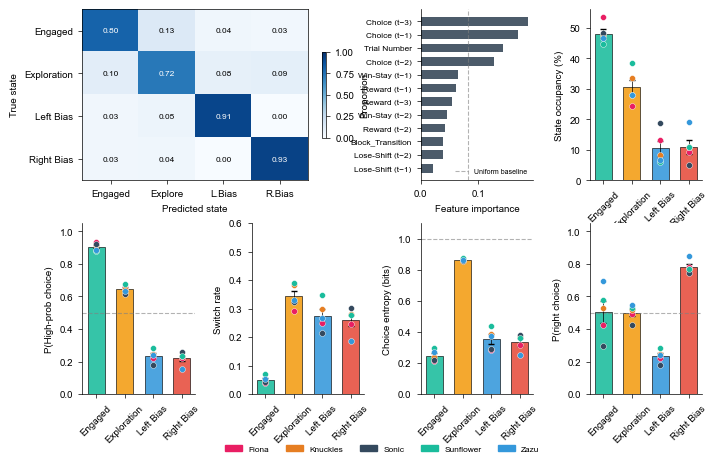

Phase 1 figure saved.


In [194]:
# CHUNK 1 — PHASE 1: SUPERVISED VALIDATION
# Question: Are behavioral states recoverable from raw observable behavior?
# Key result: 82% accuracy from independent features confirms states are real
# ═══════════════════════════════════════════════════════════════════════════════

TARGET_V3 = 'Behavioral_State_v3'

# Raw behavioral features — NOT used to define the labels
FEATURES_PHASE1 = [
    'Reward_Lag1', 'Reward_Lag2', 'Reward_Lag3',
    'Choice_Lag1', 'Choice_Lag2', 'Choice_Lag3',
    'WinStay_Lag1', 'LoseShift_Lag1',
    'WinStay_Lag2', 'LoseShift_Lag2',
    'Block_Transition', 'TrialWithinBlock',
]

FEATURE_LABELS = {
    'Reward_Lag1'      : 'Reward (t−1)',
    'Reward_Lag2'      : 'Reward (t−2)',
    'Reward_Lag3'      : 'Reward (t−3)',
    'Choice_Lag1'      : 'Choice (t−1)',
    'Choice_Lag2'      : 'Choice (t−2)',
    'Choice_Lag3'      : 'Choice (t−3)',
    'WinStay_Lag1'     : 'Win-Stay (t−1)',
    'LoseShift_Lag1'   : 'Lose-Shift (t−1)',
    'WinStay_Lag2'     : 'Win-Stay (t−2)',
    'LoseShift_Lag2'   : 'Lose-Shift (t−2)',
    'High_Prob_Is_Right': 'Block Context',
    'TrialWithinBlock' : 'Trial Number',
}

# ── 1.  Data preparation ──────────────────────────────────────────────────────
df_p1 = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .dropna(subset=FEATURES_PHASE1 + [TARGET_V3,
                                       'Chose_High_Prob',
                                       'PhysicalSwitch',
                                       'Choice_Binary',
                                       'Choice_Entropy'])
    .copy()
)

sessions          = df_p1['Session_ID'].unique()
train_sess, test_sess = train_test_split(sessions, test_size=0.2, random_state=SEED)
train_df = df_p1[df_p1['Session_ID'].isin(train_sess)]
test_df  = df_p1[df_p1['Session_ID'].isin(test_sess)]

print(f"Train: {len(train_sess)} sessions, {len(train_df)} trials")
print(f"Test:  {len(test_sess)} sessions,  {len(test_df)} trials")

# ── 2.  Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(train_df[FEATURES_PHASE1], train_df[TARGET_V3])
y_pred = rf.predict(test_df[FEATURES_PHASE1])

print(f"\nOverall accuracy: {(y_pred == test_df[TARGET_V3]).mean():.3f}")
print(classification_report(test_df[TARGET_V3], y_pred))

cm = confusion_matrix(test_df[TARGET_V3], y_pred,
                      labels=CLASSES_V3, normalize='true')

importances = (
    pd.Series(rf.feature_importances_, index=FEATURES_PHASE1)
    .rename(FEATURE_LABELS)
    .sort_values(ascending=True)
)

# ── 3.  Per-animal state profiles ─────────────────────────────────────────────
profile_rows = []
for animal in animals_ordered:
    adf = df_p1[df_p1['Animal_Name'] == animal]
    total = len(adf)
    for state in CLASSES_V3:
        sdf = adf[adf[TARGET_V3] == state]
        if len(sdf) < 5:
            continue
        profile_rows.append({
            'Animal'      : animal,
            'State'       : state,
            'P_High_Prob' : sdf['Chose_High_Prob'].mean(),
            'Switch_Rate' : sdf['PhysicalSwitch'].mean(),
            'P_Right'     : sdf['Choice_Binary'].mean(),
            'Entropy'     : sdf['Choice_Entropy'].mean(),
            'Occupancy'   : len(sdf) / total * 100,
        })
prof = pd.DataFrame(profile_rows)

# ── 4.  Publication figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 5))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.25,
    wspace        = 0.5,
    # height_ratios = [1.1, 1],
    # width_ratios  = [0.8, 0.8, 1.0, 1.0],  
)

# ── A: Confusion matrix ───────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0:2])

im = ax_A.imshow(cm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax_A.set_xticks(range(len(CLASSES_V3)))
ax_A.set_yticks(range(len(CLASSES_V3)))
labels_short = ['Engaged', 'Explore', 'L.Bias', 'R.Bias']
ax_A.set_xticklabels(labels_short, fontsize=FONTSIZE)
ax_A.set_yticklabels(CLASSES_V3, fontsize=FONTSIZE)
ax_A.set_xlabel('Predicted state', fontsize=FONTSIZE)
ax_A.set_ylabel('True state', fontsize=FONTSIZE)

for i in range(len(CLASSES_V3)):
    for j in range(len(CLASSES_V3)):
        ax_A.text(j, i, f'{cm[i,j]:.2f}',
                  ha='center', va='center', fontsize=FONTSIZE - 1,
                  color='white' if cm[i, j] > 0.55 else 'black')

plt.colorbar(im, ax=ax_A, shrink=0.5, label='Proportion')
acc = np.diag(cm).mean()
# ax_A.set_title(f'A  Confusion matrix  (macro accuracy = {acc:.2f})',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')

# ── B: Feature importance ─────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 2])

colors_imp = ['#c0392b' if 'Context' in n else '#2c3e50'
              for n in importances.index]
ax_B.barh(importances.index, importances.values,
          color=colors_imp, edgecolor='none',
          height=0.65, alpha=0.85)
ax_B.axvline(1 / len(FEATURES_PHASE1), color='gray', ls='--',
             lw=0.8, alpha=0.6, label='Uniform baseline')
ax_B.set_xlabel('Feature importance', fontsize=FONTSIZE)
# ax_B.set_title('B  Feature importance', fontsize=FONTSIZE,
#                fontweight='bold', loc='left')
ax_B.tick_params(axis='y', labelsize=FONTSIZE - 1)
ax_B.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Per-state occupancy per animal ─────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 3])

x       = np.arange(len(CLASSES_V3))
width   = 0.6
means_o = [prof[prof['State'] == s]['Occupancy'].mean() for s in CLASSES_V3]
sems_o  = [sem(prof[prof['State'] == s]['Occupancy'].dropna()) for s in CLASSES_V3]

ax_C.bar(x, means_o, width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_C.errorbar(x, means_o, yerr=sems_o, fmt='none',
              color='black', capsize=2, linewidth=LINE_WIDTH, zorder=3)

for animal in animals_ordered:
    adf_p = prof[prof['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        row = adf_p[adf_p['State'] == state]
        if len(row):
            ax_C.scatter(i, row['Occupancy'].values[0],
                         color=ANIMAL_COLORS[animal], s=18, zorder=5,
                         edgecolors='white', linewidths=0.3)

ax_C.set_xticks(x)
ax_C.set_xticklabels(CLASSES_V3, fontsize=FONTSIZE, rotation=45)
ax_C.set_ylabel('State occupancy (%)', fontsize=FONTSIZE)
# ax_C.set_title('C  Occupancy per animal',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.spines[['top', 'right']].set_visible(False)

# ── D–F: Behavioral profiles ──────────────────────────────────────────────────
profile_panels = [
    ('P_High_Prob', 'D  P(High-prob choice)', 0.5, (0, 1.05), gs[1, 0]),
    ('Switch_Rate', 'E  Switch rate',          None, (0, 0.6),  gs[1, 1]),
    ('Entropy',     'F  Choice entropy (bits)',  1.0, (0, 1.1),  gs[1, 2]),
]

for metric, title, chance, ylim, subplot_spec in profile_panels:
    ax = fig.add_subplot(subplot_spec)
    means_m = [prof[prof['State'] == s][metric].mean() for s in CLASSES_V3]
    sems_m  = [sem(prof[prof['State'] == s][metric].dropna()) for s in CLASSES_V3]

    ax.bar(x, means_m, width,
           color=[STATE_COLORS[s] for s in CLASSES_V3],
           edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
    ax.errorbar(x, means_m, yerr=sems_m, fmt='none',
                color='black', capsize=2, linewidth=LINE_WIDTH, zorder=3)

    for animal in animals_ordered:
        adf_p = prof[prof['Animal'] == animal]
        for i, state in enumerate(CLASSES_V3):
            row = adf_p[adf_p['State'] == state]
            if len(row):
                ax.scatter(i, row[metric].values[0],
                           color=ANIMAL_COLORS[animal], s=18, zorder=5,
                           edgecolors='white', linewidths=0.3)

    if chance is not None:
        ax.axhline(chance, color='gray', ls='--', lw=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASSES_V3, fontsize=FONTSIZE, rotation=45)
    ax.set_ylabel(title.split('  ')[1], fontsize=FONTSIZE)
    # ax.set_title(title, fontsize=FONTSIZE, fontweight='bold', loc='left')
    ax.set_ylim(ylim)
    ax.spines[['top', 'right']].set_visible(False)

# Panel G: P(Right) — shows left/right bias states are symmetric
ax_G = fig.add_subplot(gs[1, 3])
means_r = [prof[prof['State'] == s]['P_Right'].mean() for s in CLASSES_V3]
sems_r  = [sem(prof[prof['State'] == s]['P_Right'].dropna()) for s in CLASSES_V3]

ax_G.bar(x, means_r, width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_G.errorbar(x, means_r, yerr=sems_r, fmt='none',
              color='black', capsize=2, linewidth=LINE_WIDTH, zorder=3)

for animal in animals_ordered:
    adf_p = prof[prof['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        row = adf_p[adf_p['State'] == state]
        if len(row):
            ax_G.scatter(i, row['P_Right'].values[0],
                         color=ANIMAL_COLORS[animal], s=18, zorder=5,
                         edgecolors='white', linewidths=0.3)

ax_G.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6)
ax_G.set_xticks(x)
ax_G.set_xticklabels(CLASSES_V3, fontsize=FONTSIZE, rotation=45)
ax_G.set_ylabel('P(right choice)', fontsize=FONTSIZE)
# ax_G.set_title('G  P(Right)', fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_G.set_ylim(0, 1.05)
ax_G.spines[['top', 'right']].set_visible(False)

# ── Legend: animals ───────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a, fontsize=FONTSIZE - 1,
           frameon=False, ncol=len(animals_ordered),
           loc='lower center', bbox_to_anchor=(0.5, -0.02))

# fig.suptitle(
#     'Phase 1 — Supervised Validation of Data-Driven Behavioral State Taxonomy',
#     fontsize=FONTSIZE + 1, fontweight='bold', y=1.01
# )

plt.savefig(f'{FIGURE_PATH}/phase1_supervised_validation.svg',
            bbox_inches='tight')
plt.show()
print("Phase 1 figure saved.")

Trials: 36473

Trial_in_Block distribution:
count    36473.0
mean         9.5
std          5.7
min          0.0
25%          4.0
50%          9.0
75%         14.0
max         19.0
Name: Trial_in_Block, dtype: float64


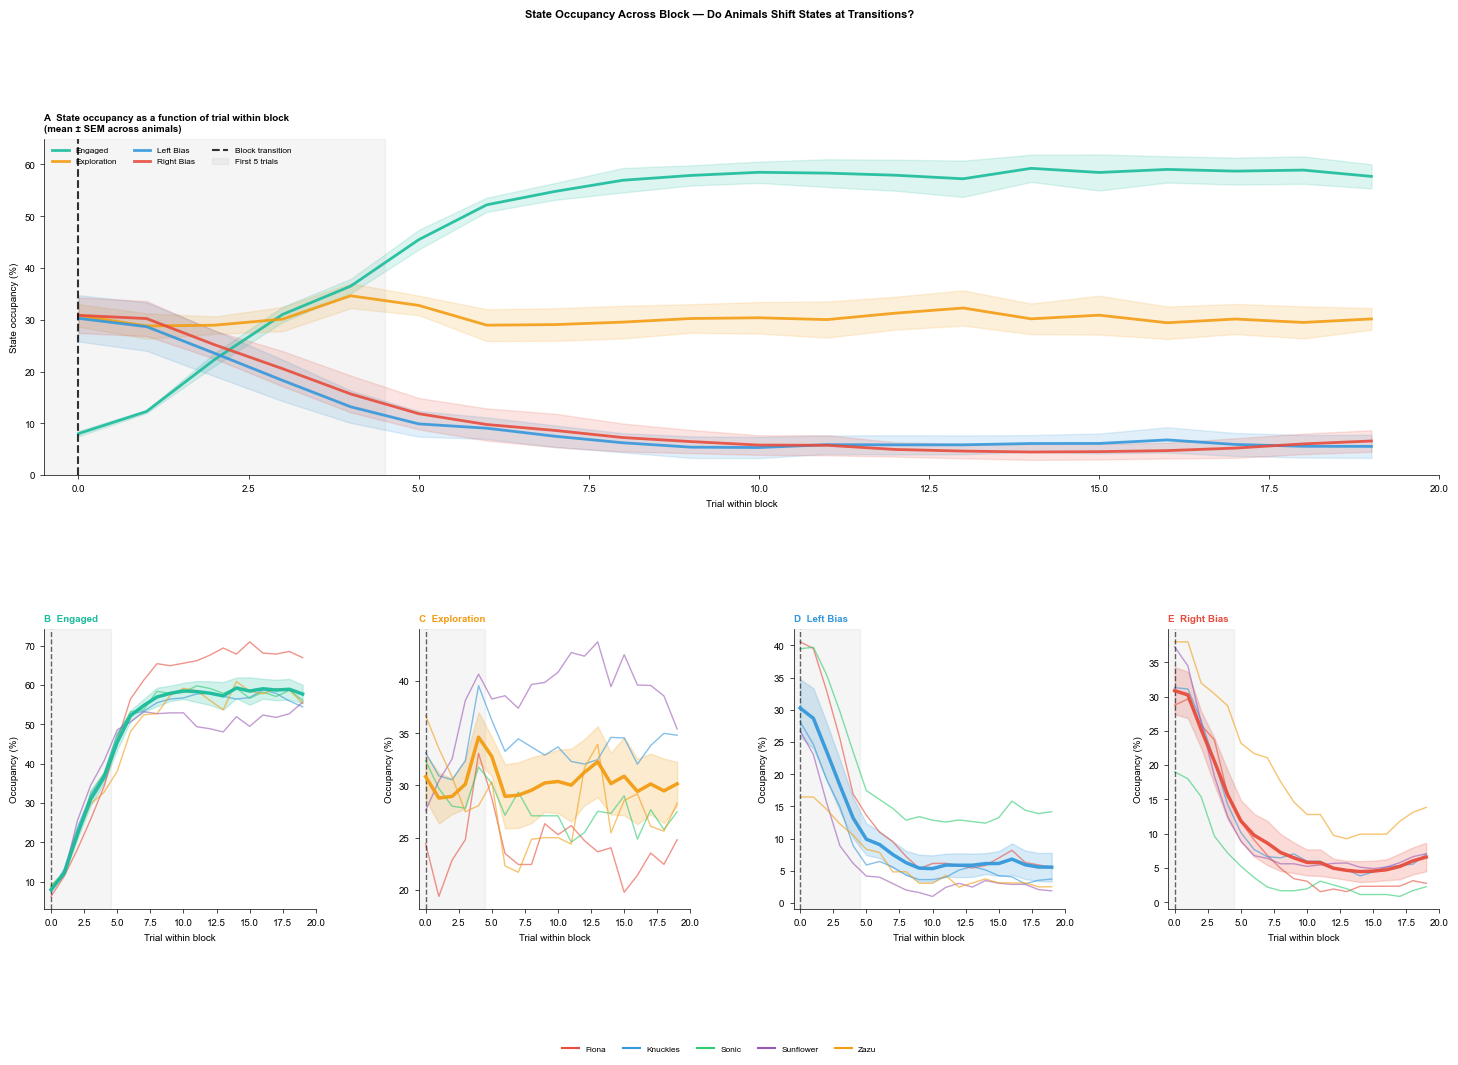

In [133]:
# ═══════════════════════════════════════════════════════════════════════════════
# STATE OCCUPANCY AS A FUNCTION OF TRIAL WITHIN BLOCK
# Question: Do animals shift states predictably around block transitions?
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Setup ──────────────────────────────────────────────────────────────────
# Use all data — this is a descriptive analysis not a classification task
df_temporal = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .dropna(subset=[TARGET_V3, 'Trial_in_Block',
                    'Trials_Since_Transition'])
    .copy()
)

# Bin trial within block — fine enough to see dynamics
# but smooth enough to see the pattern
MAX_TRIAL   = 50    # most blocks are ~30-50 trials
SMOOTH_BINS = 2     # bin width in trials

df_temporal['TWB_bin'] = (
    df_temporal['Trial_in_Block']
    .clip(upper=MAX_TRIAL)
    .astype(int)
)

print(f"Trials: {len(df_temporal)}")
print(f"\nTrial_in_Block distribution:")
print(df_temporal['Trial_in_Block'].describe().round(1))

# ── 2. Compute occupancy per trial-in-block per animal ────────────────────────
occ_rows = []
for animal in animals_ordered:
    adf = df_temporal[df_temporal['Animal_Name'] == animal]
    for twb in range(MAX_TRIAL + 1):
        trials_at_twb = adf[adf['TWB_bin'] == twb]
        if len(trials_at_twb) < 5:
            continue
        total = len(trials_at_twb)
        for state in CLASSES_V3:
            occ_rows.append({
                'Animal'         : animal,
                'Trial_in_Block' : twb,
                'State'          : state,
                'Occupancy'      : (trials_at_twb[TARGET_V3] == state).sum() / total,
                'N'              : total,
            })

df_occ = pd.DataFrame(occ_rows)

# ── 3. Group stats across animals ─────────────────────────────────────────────
from scipy.stats import sem

occ_summary = (
    df_occ
    .groupby(['Trial_in_Block', 'State'])
    .agg(
        mean_occ = ('Occupancy', 'mean'),
        sem_occ  = ('Occupancy', lambda x: sem(x.dropna())),
        n_animals= ('Occupancy', 'count'),
    )
    .reset_index()
)

# Only keep bins with all animals represented
occ_summary = occ_summary[occ_summary['n_animals'] >= 3]

# ── 4. Publication figure ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.38,
    height_ratios = [1.2, 1],
)

MAX_TRIAL = 20
# ── A: All states together ────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, :])

for state in CLASSES_V3:
    sdf = occ_summary[occ_summary['State'] == state]
    ax_A.plot(sdf['Trial_in_Block'], sdf['mean_occ'] * 100,
              color=STATE_COLORS[state], linewidth=2,
              label=state, alpha=0.9)
    ax_A.fill_between(
        sdf['Trial_in_Block'],
        (sdf['mean_occ'] - sdf['sem_occ']) * 100,
        (sdf['mean_occ'] + sdf['sem_occ']) * 100,
        color=STATE_COLORS[state], alpha=0.15
    )

ax_A.axvline(0, color='black', ls='--', lw=1.5,
             alpha=0.8, label='Block transition')
ax_A.axvspan(-0.5, 4.5, color='gray', alpha=0.08,
             label='First 5 trials')
ax_A.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_A.set_ylabel('State occupancy (%)', fontsize=FONTSIZE)
ax_A.set_title(
    'A  State occupancy as a function of trial within block\n'
    '(mean ± SEM across animals)',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_A.legend(fontsize=FONTSIZE-1, frameon=False, ncol=3)
ax_A.set_xlim(-0.5, MAX_TRIAL)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B-E: One panel per state ──────────────────────────────────────────────────
panel_labels = ['B', 'C', 'D', 'E']

for idx, state in enumerate(CLASSES_V3):
    ax = fig.add_subplot(gs[1, idx])    # ← 0,1,2,3 all valid now

    # Per animal lines
    for animal in animals_ordered:
        adf_s = df_occ[
            (df_occ['Animal'] == animal) &
            (df_occ['State']  == state)
        ].sort_values('Trial_in_Block')

        ax.plot(adf_s['Trial_in_Block'],
                adf_s['Occupancy'] * 100,
                color=ANIMAL_COLORS[animal],
                linewidth=1, alpha=0.6)

    # Mean across animals
    sdf = occ_summary[occ_summary['State'] == state]
    ax.plot(sdf['Trial_in_Block'], sdf['mean_occ'] * 100,
            color=STATE_COLORS[state],
            linewidth=2.5, alpha=0.95, zorder=5)
    ax.fill_between(
        sdf['Trial_in_Block'],
        (sdf['mean_occ'] - sdf['sem_occ']) * 100,
        (sdf['mean_occ'] + sdf['sem_occ']) * 100,
        color=STATE_COLORS[state], alpha=0.2
    )

    ax.axvline(0, color='black', ls='--', lw=1, alpha=0.6)
    ax.axvspan(-0.5, 4.5, color='gray', alpha=0.08)
    ax.set_xlabel('Trial within block', fontsize=FONTSIZE)
    ax.set_ylabel('Occupancy (%)', fontsize=FONTSIZE)
    ax.set_title(
        f'{panel_labels[idx]}  {state}',
        fontsize=FONTSIZE, fontweight='bold', loc='left',
        color=STATE_COLORS[state]
    )
    ax.set_xlim(-0.5, MAX_TRIAL)
    ax.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [plt.Line2D([0],[0], color=ANIMAL_COLORS[a],
                         linewidth=1.5, label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'State Occupancy Across Block — Do Animals Shift States at Transitions?',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.01
)

plt.savefig(f'{FIGURE_PATH}/state_occupancy_within_block.svg',
            bbox_inches='tight')
plt.show()

In [134]:
# ── Define early vs late bias ─────────────────────────────────────────────────
EARLY_CUTOFF = 5   # trials 0-4
LATE_START   = 10  # trials 10+

df_bias_type = (
    df_with_states
    .loc[df_with_states[TARGET_V3].isin(['Left Bias', 'Right Bias'])]
    .dropna(subset=['Trial_in_Block'])
    .copy()
)

df_bias_type['Bias_Type'] = pd.cut(
    df_bias_type['Trial_in_Block'],
    bins=[-1, EARLY_CUTOFF, LATE_START, 999],
    labels=['Early (0-5)', 'Mid (5-10)', 'Late (10+)']
)

print("Bias trials by type:")
print(df_bias_type['Bias_Type'].value_counts().sort_index())
print()
print("Proportion of all bias that is early vs late:")
print(df_bias_type['Bias_Type'].value_counts(normalize=True)
      .sort_index().round(3))

# Per animal breakdown
print("\nPer animal bias type distribution:")
print(df_bias_type.groupby(['Animal_Name', 'Bias_Type'])
      .size().unstack(fill_value=0))

# Q-alignment for early vs late bias
print("\nQ-alignment by bias type:")
for bias_type in ['Early (0-5)', 'Mid (5-10)', 'Late (10+)']:
    sdf = df_bias_type[df_bias_type['Bias_Type'] == bias_type]
    q   = compute_q_alignment(sdf)
    acc = sdf['Rolling_Accuracy'].mean()
    sw  = sdf['Rolling_Switch_Rate'].mean()
    print(f"  {bias_type:<15} "
          f"Q-align={q:.3f}  "
          f"Accuracy={acc:.3f}  "
          f"Switch={sw:.3f}  "
          f"N={len(sdf)}")

Bias trials by type:
Bias_Type
Early (0-5)    4552
Mid (5-10)     1175
Late (10+)     1726
Name: count, dtype: int64

Proportion of all bias that is early vs late:
Bias_Type
Early (0-5)    0.611
Mid (5-10)     0.158
Late (10+)     0.232
Name: proportion, dtype: float64

Per animal bias type distribution:
Bias_Type    Early (0-5)  Mid (5-10)  Late (10+)
Animal_Name                                     
Fiona                793         175         196
Knuckles            1299         319         465
Sonic                929         291         489
Sunflower           1086         206         369
Zazu                 445         184         207

Q-alignment by bias type:
  Early (0-5)     Q-align=0.694  Accuracy=0.500  Switch=0.121  N=4552
  Mid (5-10)      Q-align=0.434  Accuracy=0.273  Switch=0.203  N=1175
  Late (10+)      Q-align=0.298  Accuracy=0.270  Switch=0.224  N=1726



Blocks with early bias: 606
Of those, % that resolved (not late biased):
  85.1%


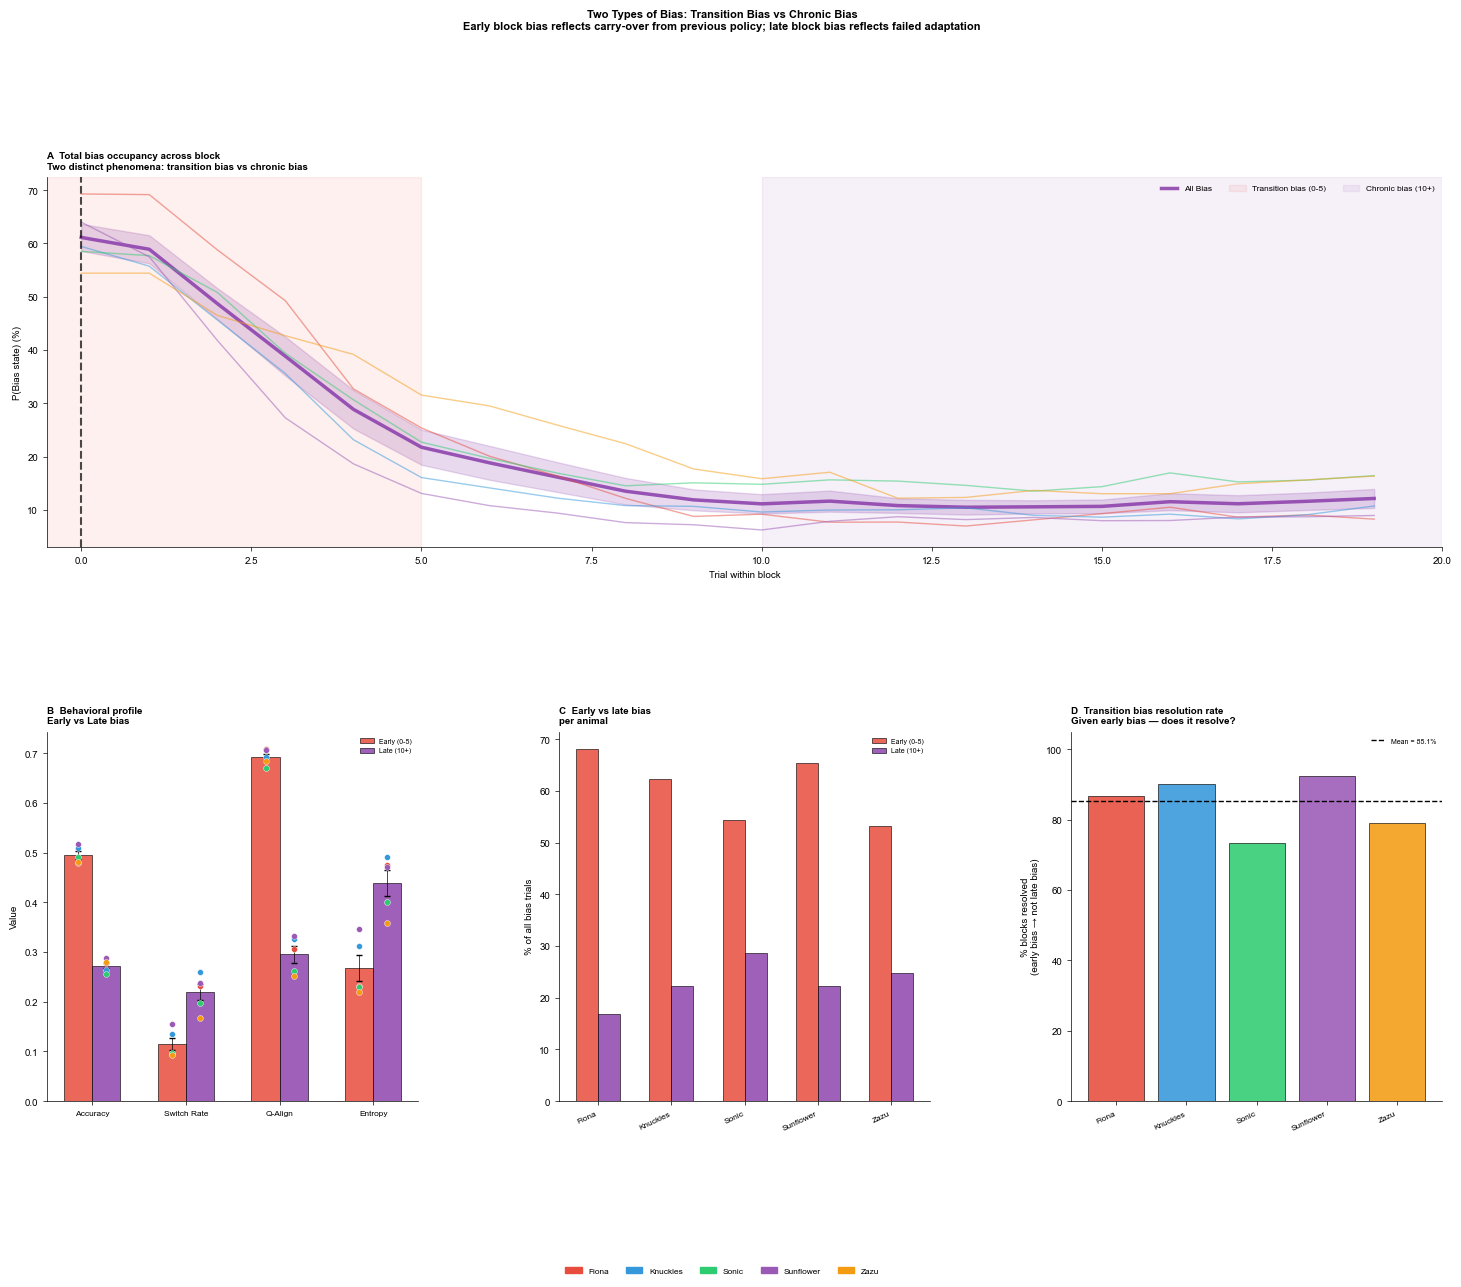

In [135]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    2, 3,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.38,
)

# ── A: Bias occupancy over block with shaded regions ─────────────────────────
ax_A = fig.add_subplot(gs[0, :])

# Total bias (Left + Right combined)
df_temporal['Is_Bias'] = df_temporal[TARGET_V3].isin(
    ['Left Bias', 'Right Bias']
).astype(float)

bias_by_twb = (
    df_temporal.groupby(['Animal_Name', 'TWB_bin'])['Is_Bias']
    .mean()
    .reset_index()
    .groupby('TWB_bin')['Is_Bias']
    .agg(['mean', sem])
    .reset_index()
)
bias_by_twb.columns = ['Trial_in_Block', 'mean', 'sem']

ax_A.plot(bias_by_twb['Trial_in_Block'],
          bias_by_twb['mean'] * 100,
          color=STATE_COLORS['Bias'],
          linewidth=2.5, alpha=0.9, label='All Bias')
ax_A.fill_between(
    bias_by_twb['Trial_in_Block'],
    (bias_by_twb['mean'] - bias_by_twb['sem']) * 100,
    (bias_by_twb['mean'] + bias_by_twb['sem']) * 100,
    color=STATE_COLORS['Bias'], alpha=0.2
)

# Per animal lines
for animal in animals_ordered:
    adf = df_temporal[df_temporal['Animal_Name'] == animal]
    ab  = adf.groupby('TWB_bin')['Is_Bias'].mean()
    ax_A.plot(ab.index, ab.values * 100,
              color=ANIMAL_COLORS[animal],
              linewidth=1, alpha=0.5)

# Shade the two regimes
ax_A.axvspan(-0.5, EARLY_CUTOFF,
             color='#e74c3c', alpha=0.08,
             label=f'Transition bias (0-{EARLY_CUTOFF})')
ax_A.axvspan(LATE_START, MAX_TRIAL,
             color='#8e44ad', alpha=0.08,
             label=f'Chronic bias ({LATE_START}+)')
ax_A.axvline(0, color='black', ls='--', lw=1.5, alpha=0.7)

ax_A.set_xlabel('Trial within block', fontsize=FONTSIZE)
ax_A.set_ylabel('P(Bias state) (%)', fontsize=FONTSIZE)
ax_A.set_xlim(-0.5, MAX_TRIAL)
ax_A.set_title(
    'A  Total bias occupancy across block\n'
    'Two distinct phenomena: transition bias vs chronic bias',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_A.legend(fontsize=FONTSIZE-1, frameon=False, ncol=3)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Behavioral profile — Early vs Late ─────────────────────────────────────
ax_B = fig.add_subplot(gs[1, 0])

metrics   = ['Rolling_Accuracy', 'Rolling_Switch_Rate',
             'Q_Alignment', 'Choice_Entropy']
met_labels= ['Accuracy', 'Switch Rate', 'Q-Align', 'Entropy']

# Compute per animal per bias type
profile_rows = []
for animal in animals_ordered:
    adf = df_bias_type[df_bias_type['Animal_Name'] == animal]
    for bias_type in ['Early (0-5)', 'Late (10+)']:
        sdf = adf[adf['Bias_Type'] == bias_type]
        if len(sdf) < 5:
            continue
        profile_rows.append({
            'Animal'          : animal,
            'Bias_Type'       : bias_type,
            'Rolling_Accuracy': sdf['Rolling_Accuracy'].mean(),
            'Rolling_Switch_Rate': sdf['Rolling_Switch_Rate'].mean(),
            'Q_Alignment'     : compute_q_alignment(sdf),
            'Choice_Entropy'  : sdf['Choice_Entropy'].mean(),
        })
df_profile = pd.DataFrame(profile_rows)

x     = np.arange(len(met_labels))
width = 0.3

for i, (bias_type, color) in enumerate([
    ('Early (0-5)', '#e74c3c'),
    ('Late (10+)',  '#8e44ad')
]):
    bdf   = df_profile[df_profile['Bias_Type'] == bias_type]
    means = [bdf[m].mean() for m in metrics]
    sems  = [sem(bdf[m].dropna()) for m in metrics]

    ax_B.bar(x + (i-0.5)*width, means, width,
             color=color, edgecolor='black',
             linewidth=LINE_WIDTH, alpha=0.85,
             label=bias_type)
    ax_B.errorbar(x + (i-0.5)*width, means, yerr=sems,
                  fmt='none', color='black',
                  capsize=2, linewidth=LINE_WIDTH)

    # Per animal dots
    for j, metric in enumerate(metrics):
        for animal in animals_ordered:
            arow = bdf[bdf['Animal'] == animal]
            if len(arow):
                ax_B.scatter(j + (i-0.5)*width,
                             arow[metric].values[0],
                             color=ANIMAL_COLORS[animal],
                             s=18, zorder=5,
                             edgecolors='white', linewidths=0.3)

ax_B.set_xticks(x)
ax_B.set_xticklabels(met_labels, fontsize=FONTSIZE-1)
ax_B.set_ylabel('Value', fontsize=FONTSIZE)
ax_B.set_title('B  Behavioral profile\nEarly vs Late bias',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE-2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Per-animal bias type proportion ────────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 1])

x_a   = np.arange(len(animals_ordered))
width = 0.3

for i, (bias_type, color) in enumerate([
    ('Early (0-5)', '#e74c3c'),
    ('Late (10+)',  '#8e44ad')
]):
    props = []
    for animal in animals_ordered:
        adf   = df_bias_type[df_bias_type['Animal_Name'] == animal]
        total = len(adf)
        if total == 0:
            props.append(0)
            continue
        props.append(
            (adf['Bias_Type'] == bias_type).sum() / total * 100
        )
    ax_C.bar(x_a + (i-0.5)*width, props, width,
             color=color, edgecolor='black',
             linewidth=LINE_WIDTH, alpha=0.85,
             label=bias_type)

ax_C.set_xticks(x_a)
ax_C.set_xticklabels(animals_ordered, fontsize=FONTSIZE-1,
                      rotation=25, ha='right')
ax_C.set_ylabel('% of all bias trials', fontsize=FONTSIZE)
ax_C.set_title('C  Early vs late bias\nper animal',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE-2, frameon=False)
ax_C.spines[['top', 'right']].set_visible(False)

# ── D: Resolution rate — does early bias resolve? ─────────────────────────────
ax_D = fig.add_subplot(gs[1, 2])

# For each block, compute: was animal biased early (0-5)?
# And what state were they in at trial 10-15?
resolution_rows = []
for animal in animals_ordered:
    adf = df_with_states[
        (df_with_states['Animal_Name'] == animal) &
        (df_with_states[TARGET_V3] != 'Unknown')
    ]
    for session in adf['Session_ID'].unique():
        sdf = adf[adf['Session_ID'] == session]
        for block in sdf['BlockCount'].unique():
            bdf = sdf[sdf['BlockCount'] == block]

            early = bdf[bdf['Trial_in_Block'] <= EARLY_CUTOFF]
            late  = bdf[bdf['Trial_in_Block'] >= LATE_START]

            if len(early) < 2 or len(late) < 2:
                continue

            early_biased = early[TARGET_V3].isin(
                ['Left Bias','Right Bias']).mean() > 0.5
            late_biased  = late[TARGET_V3].isin(
                ['Left Bias','Right Bias']).mean() > 0.3

            resolution_rows.append({
                'Animal'       : animal,
                'Session'      : session,
                'Block'        : block,
                'Early_Biased' : early_biased,
                'Late_Biased'  : late_biased,
            })

df_res = pd.DataFrame(resolution_rows)

# Probability of resolving given early bias
resolved = df_res[df_res['Early_Biased']]
print(f"\nBlocks with early bias: {len(resolved)}")
print(f"Of those, % that resolved (not late biased):")
print(f"  {(~resolved['Late_Biased']).mean()*100:.1f}%")

# Per animal resolution rate
res_by_animal = resolved.groupby('Animal').apply(
    lambda x: (~x['Late_Biased']).mean() * 100
).reset_index()
res_by_animal.columns = ['Animal', 'Resolution_Rate']

ax_D.bar(range(len(animals_ordered)),
         res_by_animal['Resolution_Rate'],
         color=[ANIMAL_COLORS[a] for a in
                res_by_animal['Animal']],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88)

overall_res = (~resolved['Late_Biased']).mean() * 100
ax_D.axhline(overall_res, color='black', ls='--',
             lw=1, label=f'Mean = {overall_res:.1f}%')

ax_D.set_xticks(range(len(animals_ordered)))
ax_D.set_xticklabels(res_by_animal['Animal'],
                      fontsize=FONTSIZE-1,
                      rotation=25, ha='right')
ax_D.set_ylabel('% blocks resolved\n(early bias → not late bias)',
                fontsize=FONTSIZE)
ax_D.set_ylim(0, 105)
ax_D.set_title('D  Transition bias resolution rate\n'
               'Given early bias — does it resolve?',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.legend(fontsize=FONTSIZE-2, frameon=False)
ax_D.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center', bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'Two Types of Bias: Transition Bias vs Chronic Bias\n'
    'Early block bias reflects carry-over from previous policy; '
    'late block bias reflects failed adaptation',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)

plt.savefig(f'{FIGURE_PATH}/early_vs_late_bias.svg',
            bbox_inches='tight')
plt.show()

Q-Alignment and Choice Entropy by Bias Type:

Early (0-5):
  Q-Alignment   : 0.693 ± 0.007
  Choice Entropy: 0.268 ± 0.026
  |Q_diff|      : 0.383 ± 0.003
  Accuracy      : 0.496 ± 0.008
  N animals     : 5

Mid (5-10):
  Q-Alignment   : 0.443 ± 0.027
  Choice Entropy: 0.419 ± 0.024
  |Q_diff|      : 0.360 ± 0.013
  Accuracy      : 0.273 ± 0.004
  N animals     : 5

Late (10+):
  Q-Alignment   : 0.296 ± 0.017
  Choice Entropy: 0.440 ± 0.026
  |Q_diff|      : 0.475 ± 0.015
  Accuracy      : 0.273 ± 0.006
  N animals     : 5


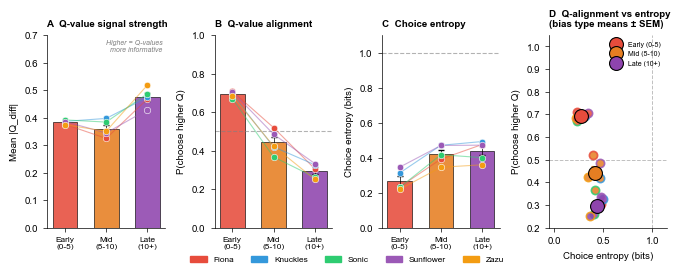

In [139]:
# Q-ALIGNMENT vs CHOICE ENTROPY — EARLY vs LATE BIAS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Add bias type to df_with_states ────────────────────────────────────────
df_bias_qa = (
    df_with_states
    .loc[df_with_states[TARGET_V3].isin(['Left Bias', 'Right Bias'])]
    .dropna(subset=['Trial_in_Block', 'Q_diff',
                    'Choice_Binary', 'Choice_Entropy',
                    'Rolling_Accuracy', 'Rolling_Switch_Rate'])
    .copy()
)

df_bias_qa['Bias_Type'] = pd.cut(
    df_bias_qa['Trial_in_Block'],
    bins  = [-1, EARLY_CUTOFF, LATE_START, 999],
    labels= ['Early\n(0-5)', 'Mid\n(5-10)', 'Late\n(10+)']
)

# ── 2. Compute per animal per bias type ───────────────────────────────────────
rows = []
for animal in animals_ordered:
    adf = df_bias_qa[df_bias_qa['Animal_Name'] == animal]
    for bias_type in ['Early\n(0-5)', 'Mid\n(5-10)', 'Late\n(10+)']:
        sdf = adf[adf['Bias_Type'] == bias_type]
        if len(sdf) < 10:
            continue
        rows.append({
            'Animal'          : animal,
            'Bias_Type'       : bias_type,
            'Q_Alignment'     : compute_q_alignment(sdf),
            'Choice_Entropy'  : sdf['Choice_Entropy'].mean(),
            'Rolling_Accuracy': sdf['Rolling_Accuracy'].mean(),
            'Abs_Q_diff'      : sdf['Q_diff'].abs().mean(),
            'N'               : len(sdf),
        })

df_bqa = pd.DataFrame(rows)

# ── 3. Print summary ──────────────────────────────────────────────────────────
print("Q-Alignment and Choice Entropy by Bias Type:")
print("=" * 65)
for bias_type in ['Early\n(0-5)', 'Mid\n(5-10)', 'Late\n(10+)']:
    sdf = df_bqa[df_bqa['Bias_Type'] == bias_type]
    print(f"\n{bias_type.replace(chr(10), ' ')}:")
    print(f"  Q-Alignment   : {sdf['Q_Alignment'].mean():.3f} "
          f"± {sem(sdf['Q_Alignment'].dropna()):.3f}")
    print(f"  Choice Entropy: {sdf['Choice_Entropy'].mean():.3f} "
          f"± {sem(sdf['Choice_Entropy'].dropna()):.3f}")
    print(f"  |Q_diff|      : {sdf['Abs_Q_diff'].mean():.3f} "
          f"± {sem(sdf['Abs_Q_diff'].dropna()):.3f}")
    print(f"  Accuracy      : {sdf['Rolling_Accuracy'].mean():.3f} "
          f"± {sem(sdf['Rolling_Accuracy'].dropna()):.3f}")
    print(f"  N animals     : {len(sdf)}")

# ── 4. Publication figure ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 2.5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.42)

BIAS_TYPES   = ['Early\n(0-5)', 'Mid\n(5-10)', 'Late\n(10+)']
BIAS_COLORS  = {
    'Early\n(0-5)' : '#e74c3c',
    'Mid\n(5-10)'  : '#e67e22',
    'Late\n(10+)'  : '#8e44ad',
}

x     = np.arange(len(BIAS_TYPES))
width = 0.6

def bias_bar_panel(ax, metric, ylabel, title, chance=None, ylim=None):
    """Bar + per-animal dots for a given metric across bias types."""
    means = [df_bqa[df_bqa['Bias_Type']==bt][metric].mean()
             for bt in BIAS_TYPES]
    sems  = [sem(df_bqa[df_bqa['Bias_Type']==bt][metric].dropna())
             for bt in BIAS_TYPES]

    ax.bar(x, means, width,
           color=[BIAS_COLORS[bt] for bt in BIAS_TYPES],
           edgecolor='black', linewidth=LINE_WIDTH,
           alpha=0.88, zorder=2)
    ax.errorbar(x, means, yerr=sems,
                fmt='none', color='black',
                capsize=2, linewidth=LINE_WIDTH, zorder=3)

    # Per-animal dots with connecting lines
    for animal in animals_ordered:
        adf_a = df_bqa[df_bqa['Animal'] == animal]
        vals  = [adf_a[adf_a['Bias_Type']==bt][metric].values
                 for bt in BIAS_TYPES]
        ys    = [v[0] if len(v) else np.nan for v in vals]
        xs    = [i for i, y in enumerate(ys) if not np.isnan(y)]
        ys_v  = [y for y in ys if not np.isnan(y)]

        # Connect dots with lines
        ax.plot(xs, ys_v,
                color=ANIMAL_COLORS[animal],
                linewidth=0.8, alpha=0.5, zorder=4)

        # Dots
        for i, (xi, yi) in enumerate(zip(xs, ys_v)):
            ax.scatter(xi, yi,
                       color=ANIMAL_COLORS[animal],
                       s=22, zorder=5,
                       edgecolors='white', linewidths=0.4)

    if chance is not None:
        ax.axhline(chance, color='gray', ls='--',
                   lw=0.8, alpha=0.6)
    if ylim:
        ax.set_ylim(ylim)

    ax.set_xticks(x)
    ax.set_xticklabels(BIAS_TYPES, fontsize=FONTSIZE-1)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_title(title, fontsize=FONTSIZE,
                 fontweight='bold', loc='left')
    ax.spines[['top', 'right']].set_visible(False)

# ── A: |Q_diff| — signal strength ────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0])
bias_bar_panel(ax_A, 'Abs_Q_diff',
               'Mean |Q_diff|',
               'A  Q-value signal strength',
               ylim=(0, 0.7))
ax_A.text(0.98, 0.98,
          'Higher = Q-values\nmore informative',
          transform=ax_A.transAxes,
          fontsize=FONTSIZE-2, color='gray',
          ha='right', va='top', style='italic')

# ── B: Q-alignment ────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])
bias_bar_panel(ax_B, 'Q_Alignment',
               'P(choose higher Q)',
               'B  Q-value alignment',
               chance=0.5,
               ylim=(0, 1.0))

# ── C: Choice entropy ─────────────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[2])
bias_bar_panel(ax_C, 'Choice_Entropy',
               'Choice entropy (bits)',
               'C  Choice entropy',
               chance=1.0,
               ylim=(0, 1.1))

# ── D: Scatter — Q-alignment vs entropy ──────────────────────────────────────
ax_D = fig.add_subplot(gs[3])

for bias_type in BIAS_TYPES:
    sdf   = df_bqa[df_bqa['Bias_Type'] == bias_type].dropna(
        subset=['Q_Alignment', 'Choice_Entropy'])
    m_qa  = sdf['Q_Alignment'].mean()
    m_ce  = sdf['Choice_Entropy'].mean()
    s_qa  = sem(sdf['Q_Alignment'])
    s_ce  = sem(sdf['Choice_Entropy'])

    # Per-animal dots
    for animal in animals_ordered:
        arow = sdf[sdf['Animal'] == animal]
        if len(arow):
            ax_D.scatter(
                arow['Choice_Entropy'].values[0],
                arow['Q_Alignment'].values[0],
                color=BIAS_COLORS[bias_type],
                s=35, alpha=0.85, zorder=4,
                edgecolors=ANIMAL_COLORS[animal],
                linewidths=1.2
            )

    # State mean ± SEM
    ax_D.errorbar(m_ce, m_qa,
                  xerr=s_ce, yerr=s_qa,
                  fmt='o', color=BIAS_COLORS[bias_type],
                  markersize=10,
                  markeredgecolor='black',
                  markeredgewidth=0.8,
                  capsize=3, linewidth=1.2,
                  zorder=6,
                  label=bias_type.replace('\n', ' '))

# Reference lines
ax_D.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
ax_D.axvline(1.0, color='gray', ls='--', lw=0.7, alpha=0.5)

ax_D.set_xlabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_D.set_ylabel('P(choose higher Q)',    fontsize=FONTSIZE)
ax_D.set_xlim(-0.05, 1.15)
ax_D.set_ylim(0.2, 1.05)
ax_D.set_title('D  Q-alignment vs entropy\n(bias type means ± SEM)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.legend(fontsize=FONTSIZE-2, frameon=False, loc='upper right')
ax_D.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.06))

# fig.suptitle(
#     'Q-Value Alignment and Choice Entropy — Early vs Late Bias\n'
#     'Transition bias vs chronic bias have distinct computational signatures',
#     fontsize=FONTSIZE+1, fontweight='bold', y=1.04
# )

plt.savefig(f'{FIGURE_PATH}/early_vs_late_bias_q_entropy.svg',
            bbox_inches='tight')
plt.show()

In [140]:
# Does late bias Q-alignment predict resolution?
# Animals whose Q-alignment is MORE anti-Q during late bias
# — do they take longer to exit?

# Merge with resolution data from previous analysis
df_res_qa = df_res.merge(
    df_bqa[df_bqa['Bias_Type'] == 'Late\n(10+)']
    [['Animal', 'Q_Alignment', 'Choice_Entropy']]
    .groupby('Animal').mean(),
    left_on='Animal', right_index=True,
    how='left'
)

# Correlation: Q-alignment vs resolution rate
from scipy.stats import spearmanr
res_by_animal_qa = df_res_qa.groupby('Animal').agg(
    Resolution_Rate = ('Late_Biased', lambda x: (~x).mean()),
    Q_Alignment     = ('Q_Alignment', 'mean'),
    Choice_Entropy  = ('Choice_Entropy', 'mean')
).reset_index()

print("Per animal — resolution rate vs late bias Q-alignment:")
print(res_by_animal_qa.round(3))

r, p = spearmanr(
    res_by_animal_qa['Q_Alignment'],
    res_by_animal_qa['Resolution_Rate']
)
print(f"\nSpearman r = {r:.3f}, p = {p:.3f}")
print("Prediction: more anti-Q → lower resolution rate")

Per animal — resolution rate vs late bias Q-alignment:
      Animal  Resolution_Rate  Q_Alignment  Choice_Entropy
0      Fiona            0.896        0.306           0.475
1   Knuckles            0.902        0.327           0.492
2      Sonic            0.793        0.262           0.400
3  Sunflower            0.925        0.333           0.472
4       Zazu            0.835        0.251           0.359

Spearman r = 0.900, p = 0.037
Prediction: more anti-Q → lower resolution rate


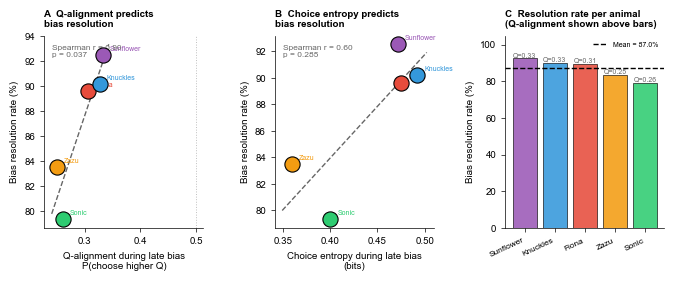

In [143]:
fig = plt.figure(figsize=(8, 2.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.45)

# ── A: Scatter — Q-alignment vs resolution rate ───────────────────────────────
ax_A = fig.add_subplot(gs[0])

for _, row in res_by_animal_qa.iterrows():
    ax_A.scatter(
        row['Q_Alignment'],
        row['Resolution_Rate'] * 100,
        color=ANIMAL_COLORS[row['Animal']],
        s=120, zorder=5,
        edgecolors='black', linewidths=0.8
    )
    ax_A.annotate(
        row['Animal'],
        xy=(row['Q_Alignment'], row['Resolution_Rate'] * 100),
        xytext=(5, 3), textcoords='offset points',
        fontsize=FONTSIZE - 2, color=ANIMAL_COLORS[row['Animal']]
    )

# Regression line
x_fit = np.linspace(
    res_by_animal_qa['Q_Alignment'].min() - 0.01,
    res_by_animal_qa['Q_Alignment'].max() + 0.01,
    100
)
slope, intercept = np.polyfit(
    res_by_animal_qa['Q_Alignment'],
    res_by_animal_qa['Resolution_Rate'] * 100, 1
)
ax_A.plot(x_fit, slope * x_fit + intercept,
          color='black', ls='--', lw=1, alpha=0.6)

ax_A.text(0.05, 0.95,
          f'Spearman r = {r:.2f}\np = {p:.3f}',
          transform=ax_A.transAxes,
          fontsize=FONTSIZE - 1, va='top', color='dimgray')

ax_A.axvline(0.5, color='gray', ls=':', lw=0.7,
             alpha=0.5, label='Q-chance')
ax_A.set_xlabel('Q-alignment during late bias\nP(choose higher Q)',
                fontsize=FONTSIZE)
ax_A.set_ylabel('Bias resolution rate (%)',
                fontsize=FONTSIZE)
ax_A.set_title('A  Q-alignment predicts\nbias resolution',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Scatter — entropy vs resolution rate ───────────────────────────────────
ax_B = fig.add_subplot(gs[1])

r_ent, p_ent = spearmanr(
    res_by_animal_qa['Choice_Entropy'],
    res_by_animal_qa['Resolution_Rate']
)

for _, row in res_by_animal_qa.iterrows():
    ax_B.scatter(
        row['Choice_Entropy'],
        row['Resolution_Rate'] * 100,
        color=ANIMAL_COLORS[row['Animal']],
        s=120, zorder=5,
        edgecolors='black', linewidths=0.8
    )
    ax_B.annotate(
        row['Animal'],
        xy=(row['Choice_Entropy'], row['Resolution_Rate'] * 100),
        xytext=(5, 3), textcoords='offset points',
        fontsize=FONTSIZE - 2, color=ANIMAL_COLORS[row['Animal']]
    )

x_fit_e = np.linspace(
    res_by_animal_qa['Choice_Entropy'].min() - 0.01,
    res_by_animal_qa['Choice_Entropy'].max() + 0.01,
    100
)
slope_e, intercept_e = np.polyfit(
    res_by_animal_qa['Choice_Entropy'],
    res_by_animal_qa['Resolution_Rate'] * 100, 1
)
ax_B.plot(x_fit_e, slope_e * x_fit_e + intercept_e,
          color='black', ls='--', lw=1, alpha=0.6)

ax_B.text(0.05, 0.95,
          f'Spearman r = {r_ent:.2f}\np = {p_ent:.3f}',
          transform=ax_B.transAxes,
          fontsize=FONTSIZE - 1, va='top', color='dimgray')

ax_B.set_xlabel('Choice entropy during late bias\n(bits)',
                fontsize=FONTSIZE)
ax_B.set_ylabel('Bias resolution rate (%)',
                fontsize=FONTSIZE)
ax_B.set_title('B  Choice entropy predicts\nbias resolution',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Summary bar — resolution rate per animal ───────────────────────────────
ax_C = fig.add_subplot(gs[2])

# Sort by resolution rate
sorted_res = res_by_animal_qa.sort_values(
    'Resolution_Rate', ascending=False
)

bars = ax_C.bar(
    range(len(sorted_res)),
    sorted_res['Resolution_Rate'] * 100,
    color=[ANIMAL_COLORS[a] for a in sorted_res['Animal']],
    edgecolor='black', linewidth=LINE_WIDTH,
    alpha=0.88
)

# Add Q-alignment as text above each bar
for i, (_, row) in enumerate(sorted_res.iterrows()):
    ax_C.text(i, row['Resolution_Rate'] * 100 + 0.5,
              f'Q={row["Q_Alignment"]:.2f}',
              ha='center', fontsize=FONTSIZE - 2,
              color='dimgray')

# Mean line
mean_res = sorted_res['Resolution_Rate'].mean() * 100
ax_C.axhline(mean_res, color='black', ls='--', lw=1,
             label=f'Mean = {mean_res:.1f}%')

ax_C.set_xticks(range(len(sorted_res)))
ax_C.set_xticklabels(sorted_res['Animal'],
                      fontsize=FONTSIZE - 1,
                      rotation=25, ha='right')
ax_C.set_ylabel('Bias resolution rate (%)', fontsize=FONTSIZE)
ax_C.set_ylim(0, 105)
ax_C.set_title('C  Resolution rate per animal\n'
               '(Q-alignment shown above bars)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_C.spines[['top', 'right']].set_visible(False)

# fig.suptitle(
#     'Value-Independence During Chronic Bias Predicts Failed Resolution\n'
#     'Animals that ignore Q-values more are less likely to escape spatial bias',
#     fontsize=FONTSIZE + 1, fontweight='bold', y=1.04
# )

plt.savefig(f'{FIGURE_PATH}/q_alignment_resolution.svg',
            bbox_inches='tight')
plt.show()

In [144]:
# ── Compare early block states directly ───────────────────────────────────────
EARLY_TRIALS = 5

df_early = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .loc[df_with_states['Trial_in_Block'] <= EARLY_TRIALS]
    .dropna(subset=['Q_diff', 'Choice_Binary',
                    'Choice_Entropy', 'Rolling_Accuracy',
                    'Rolling_Switch_Rate', 'Trial_in_Block'])
    .copy()
)

print("State distribution in first 5 trials of block:")
print(df_early[TARGET_V3].value_counts(normalize=True).round(3))
print()

# Per state metrics — early block only
print("Behavioral metrics in first 5 trials by state:")
print("=" * 65)
for state in CLASSES_V3:
    sdf = df_early[df_early[TARGET_V3] == state]
    if len(sdf) < 10:
        continue
    q_aln = compute_q_alignment(sdf)
    print(f"\n{state} (N={len(sdf)}):")
    print(f"  Q-alignment   : {q_aln:.3f}")
    print(f"  Choice Entropy: {sdf['Choice_Entropy'].mean():.3f}")
    print(f"  |Q_diff|      : {sdf['Q_diff'].abs().mean():.3f}")
    print(f"  Accuracy      : {sdf['Rolling_Accuracy'].mean():.3f}")
    print(f"  Switch Rate   : {sdf['Rolling_Switch_Rate'].mean():.3f}")
    print(f"  Abs Deviation : {sdf['Abs_Deviation'].mean():.3f}")

# ── Compare Exploration across block positions ────────────────────────────────
print("\n\nExploration metrics by trial position:")
print("=" * 65)
df_explore = (
    df_with_states
    .loc[df_with_states[TARGET_V3] == 'Exploration']
    .dropna(subset=['Trial_in_Block', 'Q_diff',
                    'Choice_Binary', 'Choice_Entropy'])
    .copy()
)

df_explore['Position'] = pd.cut(
    df_explore['Trial_in_Block'],
    bins  = [-1, 5, 15, 999],
    labels= ['Early (0-5)', 'Mid (5-15)', 'Late (15+)']
)

for pos in ['Early (0-5)', 'Mid (5-15)', 'Late (15+)']:
    sdf = df_explore[df_explore['Position'] == pos]
    if len(sdf) < 10:
        continue
    q_aln = compute_q_alignment(sdf)
    print(f"\nExploration {pos} (N={len(sdf)}):")
    print(f"  Q-alignment   : {q_aln:.3f}")
    print(f"  Choice Entropy: {sdf['Choice_Entropy'].mean():.3f}")
    print(f"  |Q_diff|      : {sdf['Q_diff'].abs().mean():.3f}")
    print(f"  Accuracy      : {sdf['Rolling_Accuracy'].mean():.3f}")
    print(f"  Switch Rate   : {sdf['Rolling_Switch_Rate'].mean():.3f}")

State distribution in first 5 trials of block:
Behavioral_State_v3
Exploration    0.319
Engaged        0.268
Right Bias     0.213
Left Bias      0.200
Name: proportion, dtype: float64

Behavioral metrics in first 5 trials by state:

Engaged (N=2950):
  Q-alignment   : 0.689
  Choice Entropy: 0.529
  |Q_diff|      : 0.509
  Accuracy      : 0.732
  Switch Rate   : 0.147
  Abs Deviation : 0.199

Exploration (N=3513):
  Q-alignment   : 0.614
  Choice Entropy: 0.853
  |Q_diff|      : 0.480
  Accuracy      : 0.412
  Switch Rate   : 0.370
  Abs Deviation : 0.228

Left Bias (N=2205):
  Q-alignment   : 0.677
  Choice Entropy: 0.275
  |Q_diff|      : 0.383
  Accuracy      : 0.495
  Switch Rate   : 0.117
  Abs Deviation : 0.724

Right Bias (N=2347):
  Q-alignment   : 0.709
  Choice Entropy: 0.286
  |Q_diff|      : 0.386
  Accuracy      : 0.505
  Switch Rate   : 0.124
  Abs Deviation : 0.721


Exploration metrics by trial position:

Exploration Early (0-5) (N=3513):
  Q-alignment   : 0.614
  Choic

In [145]:
# Within the first 5 trials — can we predict which animals
# will go into Exploration vs Bias after a transition?

# For each block transition, classify the immediate response
transition_rows = []
for animal in animals_ordered:
    adf = df_with_states[
        (df_with_states['Animal_Name'] == animal) &
        (df_with_states[TARGET_V3] != 'Unknown')
    ]
    for session in adf['Session_ID'].unique():
        sdf = adf[adf['Session_ID'] == session]
        for block in sorted(sdf['BlockCount'].unique()):
            bdf = sdf[sdf['BlockCount'] == block]
            early = bdf[bdf['Trial_in_Block'] <= EARLY_TRIALS]
            if len(early) < 3:
                continue

            # What was the dominant state in first 5 trials?
            dominant = early[TARGET_V3].value_counts().index[0]

            # What was the outcome?
            late = bdf[bdf['Trial_in_Block'] >= 10]
            if len(late) < 5:
                continue

            late_acc    = late['Rolling_Accuracy'].mean()
            late_biased = late[TARGET_V3].isin(
                ['Left Bias','Right Bias']).mean()

            transition_rows.append({
                'Animal'        : animal,
                'Session'       : session,
                'Block'         : block,
                'Early_State'   : dominant,
                'Late_Accuracy' : late_acc,
                'Late_Bias_Prop': late_biased,
            })

df_trans = pd.DataFrame(transition_rows)

print("Transition response distribution:")
print(df_trans['Early_State'].value_counts(normalize=True).round(3))
print()

print("Late accuracy by early response:")
print(df_trans.groupby('Early_State')['Late_Accuracy']
      .agg(['mean', sem]).round(3))
print()

print("Late bias proportion by early response:")
print(df_trans.groupby('Early_State')['Late_Bias_Prop']
      .agg(['mean', sem]).round(3))

Transition response distribution:
Early_State
Exploration    0.306
Right Bias     0.246
Left Bias      0.231
Engaged        0.217
Name: proportion, dtype: float64

Late accuracy by early response:
              mean    sem
Early_State              
Engaged      0.649  0.009
Exploration  0.635  0.008
Left Bias    0.614  0.009
Right Bias   0.640  0.009

Late bias proportion by early response:
              mean    sem
Early_State              
Engaged      0.078  0.008
Exploration  0.104  0.008
Left Bias    0.133  0.010
Right Bias   0.106  0.010


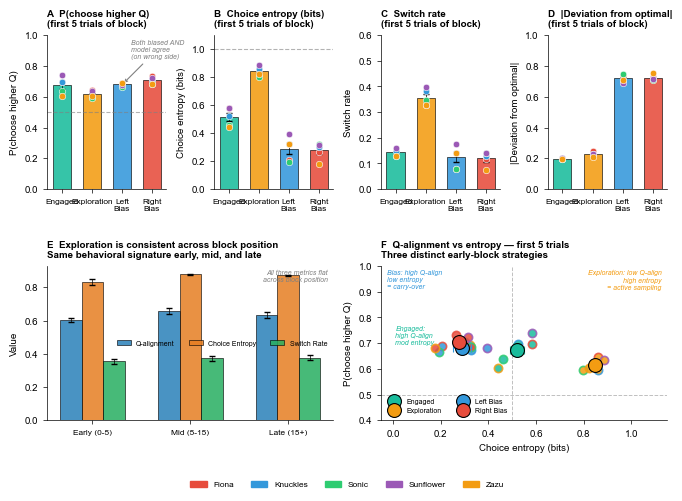

In [149]:
fig = plt.figure(figsize=(8, 5))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.40,
)

# ── Define comparison groups ──────────────────────────────────────────────────
df_early = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .loc[df_with_states['Trial_in_Block'] <= 5]
    .dropna(subset=['Q_diff', 'Choice_Binary',
                    'Choice_Entropy', 'Rolling_Accuracy',
                    'Rolling_Switch_Rate', 'Abs_Deviation'])
    .copy()
)

# Per animal per state metrics — early block only
profile_rows = []
for animal in animals_ordered:
    adf = df_early[df_early['Animal_Name'] == animal]
    for state in CLASSES_V3:
        sdf = adf[adf[TARGET_V3] == state]
        if len(sdf) < 10:
            continue
        profile_rows.append({
            'Animal'          : animal,
            'State'           : state,
            'Q_Alignment'     : compute_q_alignment(sdf),
            'Choice_Entropy'  : sdf['Choice_Entropy'].mean(),
            'Switch_Rate'     : sdf['Rolling_Switch_Rate'].mean(),
            'Abs_Deviation'   : sdf['Abs_Deviation'].mean(),
            'Abs_Q_diff'      : sdf['Q_diff'].abs().mean(),
            'Accuracy'        : sdf['Rolling_Accuracy'].mean(),
        })
df_ep = pd.DataFrame(profile_rows)

# Exploration by block position
expl_pos_rows = []
for animal in animals_ordered:
    adf = df_with_states[
        (df_with_states['Animal_Name'] == animal) &
        (df_with_states[TARGET_V3] == 'Exploration')
    ].dropna(subset=['Trial_in_Block', 'Q_diff',
                     'Choice_Binary', 'Choice_Entropy'])

    for pos, (lo, hi) in [
        ('Early\n(0-5)',  (0,  5)),
        ('Mid\n(5-15)',   (5,  15)),
        ('Late\n(15+)',   (15, 999)),
    ]:
        sdf = adf[(adf['Trial_in_Block'] >= lo) &
                  (adf['Trial_in_Block'] <  hi)]
        if len(sdf) < 10:
            continue
        expl_pos_rows.append({
            'Animal'       : animal,
            'Position'     : pos,
            'Q_Alignment'  : compute_q_alignment(sdf),
            'Choice_Entropy': sdf['Choice_Entropy'].mean(),
            'Switch_Rate'  : sdf['Rolling_Switch_Rate'].mean(),
        })
df_ep2 = pd.DataFrame(expl_pos_rows)

METRICS = [
    ('Q_Alignment',   'P(choose higher Q)', 0.5,  (0.0, 1.0)),
    ('Choice_Entropy','Choice entropy (bits)', 1.0, (0.0, 1.1)),
    ('Switch_Rate',   'Switch rate', None,    (0.0, 0.6)),
    ('Abs_Deviation', '|Deviation from optimal|', None, (0.0, 1.0)),
]
panel_labels = ['A', 'B', 'C', 'D']

x     = np.arange(len(CLASSES_V3))
width = 0.6

# ── A-D: Early block metrics by state ────────────────────────────────────────
for col_idx, (metric, ylabel, chance, ylim) in enumerate(METRICS):
    ax = fig.add_subplot(gs[0, col_idx])

    means = [df_ep[df_ep['State']==s][metric].mean()
             for s in CLASSES_V3]
    sems  = [sem(df_ep[df_ep['State']==s][metric].dropna())
             for s in CLASSES_V3]

    ax.bar(x, means, width,
           color=[STATE_COLORS[s] for s in CLASSES_V3],
           edgecolor='black', linewidth=LINE_WIDTH,
           alpha=0.88, zorder=2)
    ax.errorbar(x, means, yerr=sems,
                fmt='none', color='black',
                capsize=2, linewidth=LINE_WIDTH, zorder=3)

    # Per animal dots
    for animal in animals_ordered:
        adf_a = df_ep[df_ep['Animal'] == animal]
        for i, state in enumerate(CLASSES_V3):
            row = adf_a[adf_a['State'] == state]
            if len(row):
                ax.scatter(i, row[metric].values[0],
                           color=ANIMAL_COLORS[animal],
                           s=22, zorder=5,
                           edgecolors='white', linewidths=0.4)

    if chance is not None:
        ax.axhline(chance, color='gray', ls='--',
                   lw=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                       fontsize=FONTSIZE-1)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_ylim(ylim)
    ax.set_title(
        f'{panel_labels[col_idx]}  {ylabel}\n'
        f'(first 5 trials of block)',
        fontsize=FONTSIZE, fontweight='bold', loc='left'
    )
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate the key contrast for Q-alignment panel
    if metric == 'Q_Alignment':
        ax.annotate(
            'Both biased AND\nmodel agree\n(on wrong side)',
            xy=(2, 0.677), xytext=(2.3, 0.85),
            fontsize=FONTSIZE-2, color='gray',
            style='italic',
            arrowprops=dict(arrowstyle='->', color='gray',
                           lw=0.8)
        )

# ── E: Exploration stability across block ─────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 0:2])

POSITIONS  = ['Early\n(0-5)', 'Mid\n(5-15)', 'Late\n(15+)']
POS_COLORS = ['#e74c3c', '#e67e22', '#8e44ad']
x_pos      = np.arange(len(POSITIONS))
met_labels = ['Q-alignment', 'Choice Entropy', 'Switch Rate']
met_keys   = ['Q_Alignment', 'Choice_Entropy', 'Switch_Rate']
width_g    = 0.22

for k, (metric, label, color) in enumerate(zip(
    met_keys, met_labels,
    ['#2980b9', '#e67e22', '#27ae60']
)):
    means = [df_ep2[df_ep2['Position']==p][metric].mean()
             for p in POSITIONS]
    sems  = [sem(df_ep2[df_ep2['Position']==p][metric].dropna())
             for p in POSITIONS]

    ax_E.bar(x_pos + (k-1)*width_g, means, width_g,
             color=color, edgecolor='black',
             linewidth=LINE_WIDTH, alpha=0.85,
             label=label)
    ax_E.errorbar(x_pos + (k-1)*width_g, means, yerr=sems,
                  fmt='none', color='black',
                  capsize=2, linewidth=LINE_WIDTH)

ax_E.set_xticks(x_pos)
ax_E.set_xticklabels([p.replace('\n',' ') for p in POSITIONS],
                     fontsize=FONTSIZE-1)
ax_E.set_ylabel('Value', fontsize=FONTSIZE)
ax_E.set_title(
    'E  Exploration is consistent across block position\n'
    'Same behavioral signature early, mid, and late',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_E.legend(fontsize=FONTSIZE-2, frameon=False, ncol=3)
ax_E.spines[['top', 'right']].set_visible(False)

# Add annotation about flatness
ax_E.text(0.98, 0.98,
          'All three metrics flat\nacross block position',
          transform=ax_E.transAxes,
          fontsize=FONTSIZE-2, color='gray',
          ha='right', va='top', style='italic')

# ── F: Scatter — Q-align vs entropy early block ───────────────────────────────
ax_F = fig.add_subplot(gs[1, 2:4])

for state in CLASSES_V3:
    sdf   = df_ep[df_ep['State'] == state].dropna(
        subset=['Q_Alignment', 'Choice_Entropy'])
    m_qa  = sdf['Q_Alignment'].mean()
    m_ce  = sdf['Choice_Entropy'].mean()
    s_qa  = sem(sdf['Q_Alignment'])
    s_ce  = sem(sdf['Choice_Entropy'])

    # Per-animal dots
    for animal in animals_ordered:
        arow = sdf[sdf['Animal'] == animal]
        if len(arow):
            ax_F.scatter(
                arow['Choice_Entropy'].values[0],
                arow['Q_Alignment'].values[0],
                color=STATE_COLORS[state], s=35,
                alpha=0.85, zorder=4,
                edgecolors=ANIMAL_COLORS[animal],
                linewidths=1.2
            )

    # State mean ± SEM
    ax_F.errorbar(m_ce, m_qa,
                  xerr=s_ce, yerr=s_qa,
                  fmt='o', color=STATE_COLORS[state],
                  markersize=10,
                  markeredgecolor='black',
                  markeredgewidth=0.8,
                  capsize=3, linewidth=1.2,
                  zorder=6, label=state)

ax_F.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
ax_F.axvline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)

# Annotate the three behavioral strategies
ax_F.text(0.02, 0.98,
          'Bias: high Q-align\nlow entropy\n= carry-over',
          transform=ax_F.transAxes,
          fontsize=FONTSIZE-2, color=STATE_COLORS['Left Bias'],
          va='top', ha='left', style='italic')
ax_F.text(0.98, 0.98,
          'Exploration: low Q-align\nhigh entropy\n= active sampling',
          transform=ax_F.transAxes,
          fontsize=FONTSIZE-2, color=STATE_COLORS['Exploration'],
          va='top', ha='right', style='italic')
ax_F.text(0.05, 0.55,
          'Engaged:\nhigh Q-align\nmod entropy',
          transform=ax_F.transAxes,
          fontsize=FONTSIZE-2, color=STATE_COLORS['Engaged'],
          va='center', ha='left', style='italic')

ax_F.set_xlabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_F.set_ylabel('P(choose higher Q)',    fontsize=FONTSIZE)
ax_F.set_xlim(-0.05, 1.15)
ax_F.set_ylim(0.40, 1.0)
ax_F.set_title(
    'F  Q-alignment vs entropy — first 5 trials\n'
    'Three distinct early-block strategies',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_F.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax_F.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04))

# fig.suptitle(
#     'Early Exploration vs Early Bias — Opposite Responses to Block Transition\n'
#     'Exploration = active detection | '
#     'Bias = passive carry-over | '
#     'Both distinguishable from first trial',
#     fontsize=FONTSIZE+1, fontweight='bold', y=1.02
# )

plt.savefig(f'{FIGURE_PATH}/early_exploration_vs_bias.svg',
            bbox_inches='tight')
plt.show()

In [150]:
# Is there a genuine Left/Right asymmetry?
print("Left vs Right bias — block structure context:")
print(df_with_states.groupby('High_Prob_Is_Right')[TARGET_V3]
      .value_counts(normalize=True).round(3))

# Do animals have a general preference for one side?
print("\nOverall P(Right) per animal:")
print(df_with_states.groupby('Animal_Name')['Choice_Binary']
      .mean().round(3))

# Are Left Bias blocks harder to escape?
# i.e. does High_Prob_Is_Right = 1 (reward on right)
# predict faster escape from Left Bias?
lb_blocks = df_trans[df_trans['Early_State'] == 'Left Bias']
rb_blocks = df_trans[df_trans['Early_State'] == 'Right Bias']

print(f"\nLeft Bias early blocks — late bias: "
      f"{lb_blocks['Late_Bias_Prop'].mean():.3f}")
print(f"Right Bias early blocks — late bias: "
      f"{rb_blocks['Late_Bias_Prop'].mean():.3f}")

Left vs Right bias — block structure context:
High_Prob_Is_Right  Behavioral_State_v3
0                   Engaged                0.483
                    Exploration            0.309
                    Right Bias             0.207
                    Unknown                0.001
1                   Engaged                0.464
                    Exploration            0.326
                    Left Bias              0.200
                    Unknown                0.010
Name: proportion, dtype: float64

Overall P(Right) per animal:
Animal_Name
Fiona        0.447
Knuckles     0.529
Sonic        0.334
Sunflower    0.564
Zazu         0.653
Name: Choice_Binary, dtype: float64

Left Bias early blocks — late bias: 0.133
Right Bias early blocks — late bias: 0.106


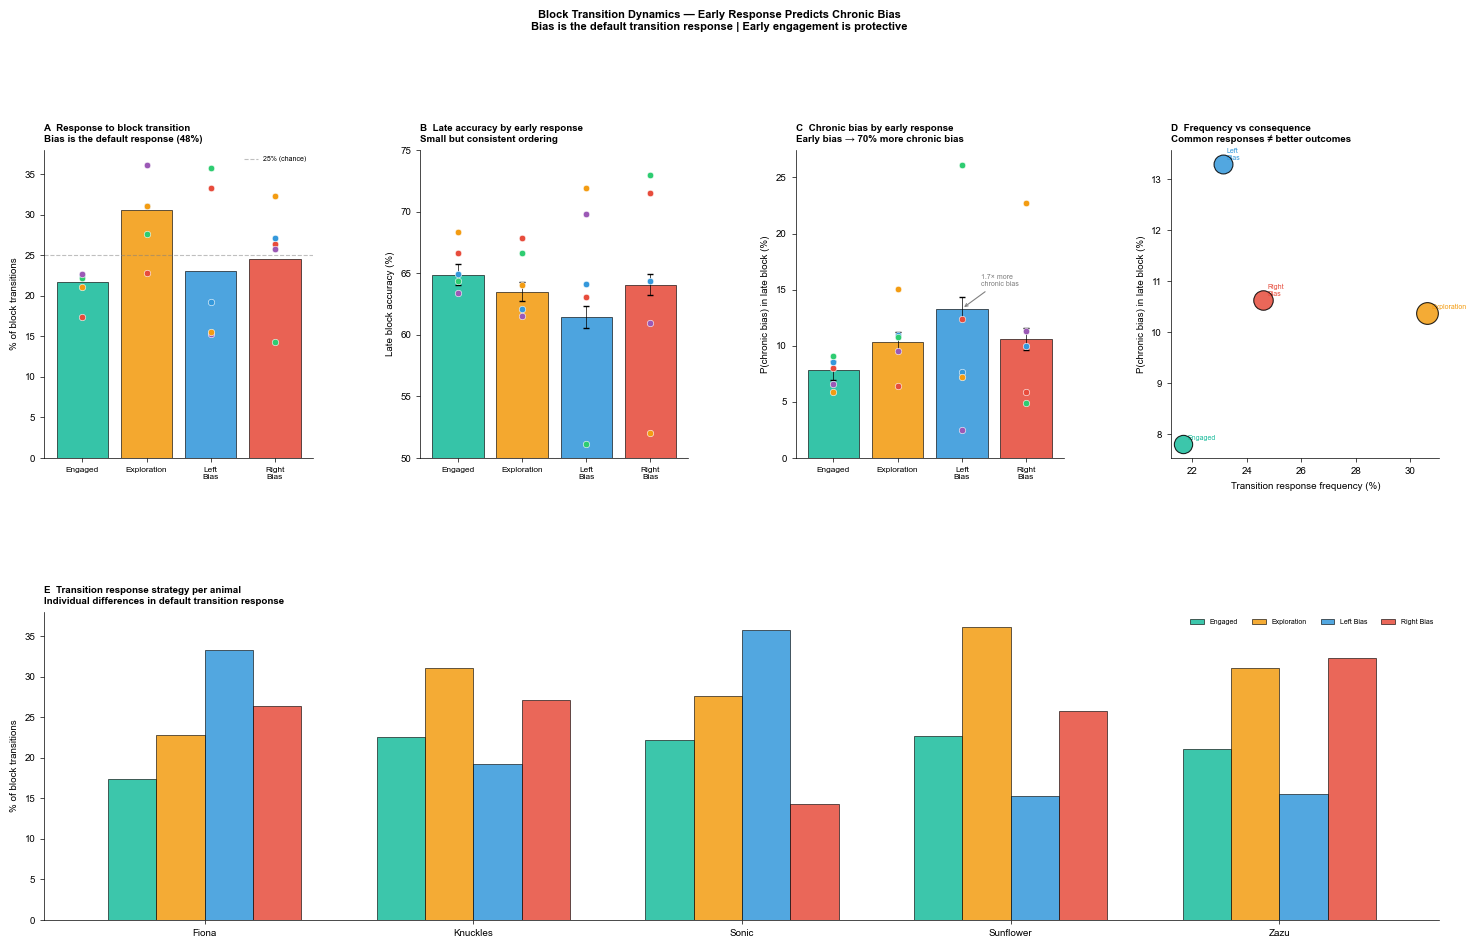


── Key Numbers for Paper ─────────────────────────────────
Most common transition response: Exploration (30.6%)
Combined bias response: 47.7%

Late chronic bias by early state:
  Engaged         7.8% ± 0.8%
  Exploration     10.4% ± 0.8%
  Left Bias       13.3% ± 1.0%
  Right Bias      10.6% ± 1.0%

Left Bias vs Engaged fold increase: 1.70x


In [151]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.40,
    height_ratios = [1, 1],
)

# ── A: Transition response distribution ───────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])

trans_dist = df_trans['Early_State'].value_counts(normalize=True)
trans_dist = trans_dist.reindex(CLASSES_V3)

ax_A.bar(range(len(CLASSES_V3)),
         trans_dist.values * 100,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88)

# Per animal dots
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    atd   = adf_a['Early_State'].value_counts(normalize=True)
    for i, state in enumerate(CLASSES_V3):
        val = atd.get(state, 0) * 100
        ax_A.scatter(i, val,
                     color=ANIMAL_COLORS[animal],
                     s=22, zorder=5,
                     edgecolors='white', linewidths=0.4)

ax_A.axhline(25, color='gray', ls='--', lw=0.8,
             alpha=0.5, label='25% (chance)')
ax_A.set_xticks(range(len(CLASSES_V3)))
ax_A.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE-1)
ax_A.set_ylabel('% of block transitions', fontsize=FONTSIZE)
ax_A.set_title('A  Response to block transition\n'
               'Bias is the default response (48%)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Late accuracy by early response ────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])

late_acc = df_trans.groupby('Early_State')['Late_Accuracy'].agg(
    ['mean', sem]).reindex(CLASSES_V3)

ax_B.bar(range(len(CLASSES_V3)),
         late_acc['mean'] * 100,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88, zorder=2)
ax_B.errorbar(range(len(CLASSES_V3)),
              late_acc['mean'] * 100,
              yerr=late_acc['sem'] * 100,
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per animal
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        val = adf_a[adf_a['Early_State'] == state]['Late_Accuracy'].mean()
        if not np.isnan(val):
            ax_B.scatter(i, val * 100,
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

ax_B.axhline(50, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_B.set_xticks(range(len(CLASSES_V3)))
ax_B.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE-1)
ax_B.set_ylabel('Late block accuracy (%)', fontsize=FONTSIZE)
ax_B.set_ylim(50, 75)
ax_B.set_title('B  Late accuracy by early response\n'
               'Small but consistent ordering',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Late bias proportion by early response ─────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2])

late_bias = df_trans.groupby('Early_State')['Late_Bias_Prop'].agg(
    ['mean', sem]).reindex(CLASSES_V3)

ax_C.bar(range(len(CLASSES_V3)),
         late_bias['mean'] * 100,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88, zorder=2)
ax_C.errorbar(range(len(CLASSES_V3)),
              late_bias['mean'] * 100,
              yerr=late_bias['sem'] * 100,
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per animal
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        val = adf_a[adf_a['Early_State'] == state]['Late_Bias_Prop'].mean()
        if not np.isnan(val):
            ax_C.scatter(i, val * 100,
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

ax_C.set_xticks(range(len(CLASSES_V3)))
ax_C.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE-1)
ax_C.set_ylabel('P(chronic bias) in late block (%)',
                fontsize=FONTSIZE)
ax_C.set_title('C  Chronic bias by early response\n'
               'Early bias → 70% more chronic bias',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.spines[['top', 'right']].set_visible(False)

# Add fold-change annotation
engaged_lb = late_bias.loc['Engaged', 'mean'] * 100
left_lb    = late_bias.loc['Left Bias', 'mean'] * 100
fold       = left_lb / engaged_lb
ax_C.annotate(
    f'{fold:.1f}× more\nchronic bias',
    xy=(2, left_lb),
    xytext=(2.3, left_lb + 2),
    fontsize=FONTSIZE-2, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
)

# ── D: Summary — the transition funnel ────────────────────────────────────────
ax_D = fig.add_subplot(gs[0, 3])

# Sankey-style summary as a simple dot + line plot
# X = early state, Y = late bias probability
# Size = frequency of that early state

for i, state in enumerate(CLASSES_V3):
    freq = trans_dist[state] * 100
    lb   = late_bias.loc[state, 'mean'] * 100
    ax_D.scatter(freq, lb,
                 color=STATE_COLORS[state],
                 s=freq * 8,    # size proportional to frequency
                 alpha=0.85, zorder=5,
                 edgecolors='black', linewidths=0.8,
                 label=f'{state} ({freq:.0f}%)')

# Add labels
for state in CLASSES_V3:
    freq = trans_dist[state] * 100
    lb   = late_bias.loc[state, 'mean'] * 100
    ax_D.annotate(
        state.replace(' ', '\n'),
        xy=(freq, lb),
        xytext=(3, 3), textcoords='offset points',
        fontsize=FONTSIZE-2,
        color=STATE_COLORS[state]
    )

r_trans, p_trans = spearmanr(
    [trans_dist[s] for s in CLASSES_V3],
    [late_bias.loc[s, 'mean'] for s in CLASSES_V3]
)

ax_D.set_xlabel('Transition response frequency (%)',
                fontsize=FONTSIZE)
ax_D.set_ylabel('P(chronic bias) in late block (%)',
                fontsize=FONTSIZE)
ax_D.set_title('D  Frequency vs consequence\n'
               'Common responses ≠ better outcomes',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.spines[['top', 'right']].set_visible(False)

# ── E-H: Per-animal breakdown ─────────────────────────────────────────────────
ax_E = fig.add_subplot(gs[1, :])

# For each animal, show early state distribution
# and resulting late bias — connected bars
animals_x = np.arange(len(animals_ordered))
width_g   = 0.18
offsets   = np.linspace(
    -(len(CLASSES_V3)-1)*width_g/2,
     (len(CLASSES_V3)-1)*width_g/2,
     len(CLASSES_V3)
)

for k, state in enumerate(CLASSES_V3):
    freq_vals = []
    late_vals = []
    for animal in animals_ordered:
        adf_a = df_trans[df_trans['Animal'] == animal]
        freq_vals.append(
            (adf_a['Early_State'] == state).mean() * 100
        )
        late_vals.append(
            adf_a[adf_a['Early_State'] == state]['Late_Bias_Prop'].mean() * 100
        )

    # Stacked representation: bar = frequency, alpha = late bias
    bars = ax_E.bar(
        animals_x + offsets[k],
        freq_vals,
        width_g,
        color=STATE_COLORS[state],
        edgecolor='black', linewidth=LINE_WIDTH,
        alpha=0.85, label=state
    )

ax_E.set_xticks(animals_x)
ax_E.set_xticklabels(animals_ordered, fontsize=FONTSIZE)
ax_E.set_ylabel('% of block transitions', fontsize=FONTSIZE)
ax_E.set_title(
    'E  Transition response strategy per animal\n'
    'Individual differences in default transition response',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_E.legend(fontsize=FONTSIZE-2, frameon=False, ncol=4)
ax_E.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Block Transition Dynamics — Early Response Predicts Chronic Bias\n'
    'Bias is the default transition response | '
    'Early engagement is protective',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)

plt.savefig(f'{FIGURE_PATH}/transition_dynamics.svg',
            bbox_inches='tight')
plt.show()

# ── Statistical summary ────────────────────────────────────────────────────────
print("\n── Key Numbers for Paper ─────────────────────────────────")
print(f"Most common transition response: Exploration ({trans_dist.max()*100:.1f}%)")
print(f"Combined bias response: {(trans_dist['Left Bias']+trans_dist['Right Bias'])*100:.1f}%")
print(f"\nLate chronic bias by early state:")
for state in CLASSES_V3:
    print(f"  {state:<15} {late_bias.loc[state,'mean']*100:.1f}% "
          f"± {late_bias.loc[state,'sem']*100:.1f}%")
fold = late_bias.loc['Left Bias','mean'] / late_bias.loc['Engaged','mean']
print(f"\nLeft Bias vs Engaged fold increase: {fold:.2f}x")

In [153]:
# Are the animals with left preference the same ones
# driving the Left Bias → chronic bias result?

print("P(Right choice) per animal:")
p_right = (df_with_states
           .groupby('Animal_Name')['Choice_Binary']
           .mean()
           .round(3))
print(p_right)
print()

# Which animals contribute most to early Left Bias?
print("Early Left Bias blocks per animal:")
lb_per_animal = (df_trans[df_trans['Early_State'] == 'Left Bias']
                 .groupby('Animal')
                 .size()
                 .sort_values(ascending=False))
print(lb_per_animal)
print()

# Is the same animal driving both?
print("Chronic bias rate from Left Bias early — per animal:")
print(df_trans[df_trans['Early_State'] == 'Left Bias']
      .groupby('Animal')['Late_Bias_Prop']
      .mean().round(3))

P(Right choice) per animal:
Animal_Name
Fiona        0.447
Knuckles     0.529
Sonic        0.334
Sunflower    0.564
Zazu         0.653
Name: Choice_Binary, dtype: float64

Early Left Bias blocks per animal:
Animal
Sonic        127
Knuckles     105
Fiona         86
Sunflower     75
Zazu          25
dtype: int64

Chronic bias rate from Left Bias early — per animal:
Animal
Fiona        0.124
Knuckles     0.076
Sonic        0.261
Sunflower    0.025
Zazu         0.072
Name: Late_Bias_Prop, dtype: float64


In [154]:
summary_animals = pd.DataFrame({
    'Animal'           : animals_ordered,
    'P_Right'          : p_right.values,
    'Left_Bias_N'      : lb_per_animal.reindex(animals_ordered).values,
    'Chronic_Left_Rate': (df_trans[df_trans['Early_State']=='Left Bias']
                          .groupby('Animal')['Late_Bias_Prop']
                          .mean().reindex(animals_ordered).values),
    'Chronic_Right_Rate': (df_trans[df_trans['Early_State']=='Right Bias']
                           .groupby('Animal')['Late_Bias_Prop']
                           .mean().reindex(animals_ordered).values),
})

r_left,  p_left  = spearmanr(
    summary_animals['P_Right'],
    summary_animals['Chronic_Left_Rate']
)
r_right, p_right_corr = spearmanr(
    summary_animals['P_Right'],
    summary_animals['Chronic_Right_Rate']
)

print("Correlation: P(Right) vs Chronic Left Bias rate:")
print(f"  r = {r_left:.3f}, p = {p_left:.3f}")
print()
print("Correlation: P(Right) vs Chronic Right Bias rate:")
print(f"  r = {r_right:.3f}, p = {p_right_corr:.3f}")
print()
print(summary_animals.round(3))

Correlation: P(Right) vs Chronic Left Bias rate:
  r = -0.900, p = 0.037

Correlation: P(Right) vs Chronic Right Bias rate:
  r = 1.000, p = 0.000

      Animal  P_Right  Left_Bias_N  Chronic_Left_Rate  Chronic_Right_Rate
0      Fiona    0.447           86              0.124               0.059
1   Knuckles    0.529          105              0.076               0.100
2      Sonic    0.334          127              0.261               0.049
3  Sunflower    0.564           75              0.025               0.113
4       Zazu    0.653           25              0.072               0.227


In [155]:
# Confirm the merged numbers are cleaner
df_trans['Early_State_Merged'] = df_trans['Early_State'].replace({
    'Left Bias' : 'Bias',
    'Right Bias': 'Bias'
})

# Also create directional bias relative to preference
# "Preferred Bias" = biased toward preferred side
# "Non-preferred Bias" = biased against preferred side
p_right_map = p_right.to_dict()

df_trans['Bias_Direction'] = df_trans.apply(
    lambda r: (
        np.nan if r['Early_State'] not in ['Left Bias','Right Bias']
        else (
            'Preferred'
            if (r['Early_State'] == 'Right Bias' and
                p_right_map.get(r['Animal'], 0.5) > 0.5)
            or (r['Early_State'] == 'Left Bias' and
                p_right_map.get(r['Animal'], 0.5) < 0.5)
            else 'Non-preferred'
        )
    ), axis=1
)

print("Chronic bias rate by bias direction:")
print(df_trans.groupby('Bias_Direction')['Late_Bias_Prop']
      .agg(['mean', sem, 'count']).round(3))
print()

print("Merged transition response:")
print(df_trans['Early_State_Merged']
      .value_counts(normalize=True).round(3))
print()

print("Late chronic bias — merged:")
print(df_trans.groupby('Early_State_Merged')['Late_Bias_Prop']
      .agg(['mean', sem]).round(3))

Chronic bias rate by bias direction:
                 mean    sem  count
Bias_Direction                     
Non-preferred   0.056  0.009    324
Preferred       0.157  0.010    539

Merged transition response:
Early_State_Merged
Bias           0.477
Exploration    0.306
Engaged        0.217
Name: proportion, dtype: float64

Late chronic bias — merged:
                     mean    sem
Early_State_Merged              
Bias                0.119  0.007
Engaged             0.078  0.008
Exploration         0.104  0.008


In [152]:
# Quick check on question 2 — learning across session
print("Early state distribution by block number:")
print(df_trans.groupby(['Block', 'Early_State'])
      .size()
      .unstack(fill_value=0)
      .apply(lambda x: x/x.sum(), axis=1)
      .round(3)
      .head(10))

Early state distribution by block number:
Early_State  Engaged  Exploration  Left Bias  Right Bias
Block                                                   
1              0.350        0.570      0.070       0.010
2              0.180        0.290      0.070       0.460
3              0.227        0.392      0.340       0.041
4              0.196        0.320      0.052       0.433
5              0.240        0.396      0.323       0.042
6              0.211        0.295      0.042       0.453
7              0.191        0.372      0.394       0.043
8              0.204        0.323      0.043       0.430
9              0.293        0.261      0.402       0.043
10             0.202        0.292      0.045       0.461


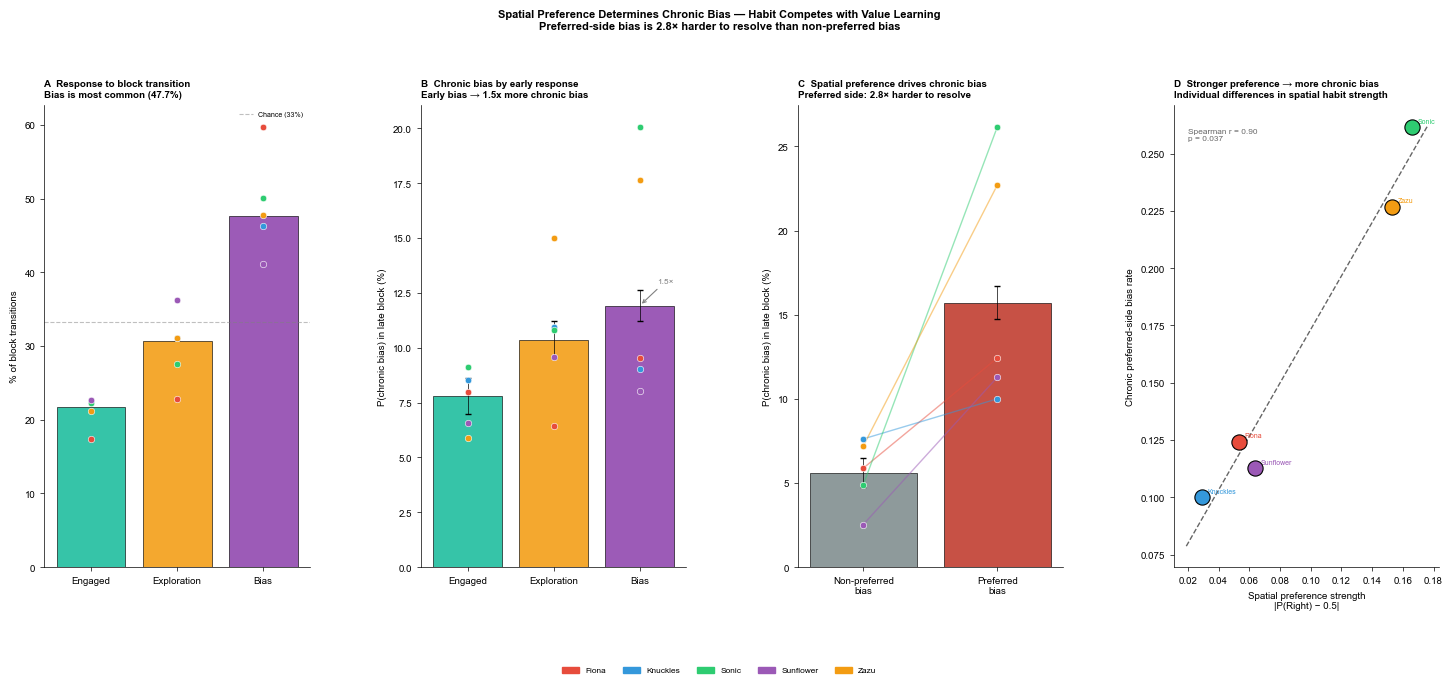


── Key Numbers for Paper ─────────────────────────────────
Transition response: Bias=47.7%, Exploration=30.6%, Engaged=21.7%

Chronic bias rate:
  Engaged          : 7.8%
  Exploration      : 10.4%
  Bias (merged)    : 11.9%
  Non-preferred    : 5.6%
  Preferred        : 15.7%

Key ratios:
  Bias/Engaged     : 1.53x
  Preferred/Non-pref: 2.80x


In [156]:
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.42)

# ── A: Transition response distribution (merged) ──────────────────────────────
ax_A = fig.add_subplot(gs[0])

MERGED_STATES  = ['Engaged', 'Exploration', 'Bias']
MERGED_COLORS  = {
    'Engaged'    : STATE_COLORS['Engaged'],
    'Exploration': STATE_COLORS['Exploration'],
    'Bias'       : STATE_COLORS['Bias'],
}

trans_merged = (df_trans['Early_State_Merged']
                .value_counts(normalize=True)
                .reindex(MERGED_STATES))

ax_A.bar(range(3),
         trans_merged.values * 100,
         color=[MERGED_COLORS[s] for s in MERGED_STATES],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88, zorder=2)

# Per animal dots
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    atd   = adf_a['Early_State_Merged'].value_counts(normalize=True)
    for i, state in enumerate(MERGED_STATES):
        val = atd.get(state, 0) * 100
        ax_A.scatter(i, val,
                     color=ANIMAL_COLORS[animal],
                     s=22, zorder=5,
                     edgecolors='white', linewidths=0.4)

ax_A.axhline(33.3, color='gray', ls='--',
             lw=0.8, alpha=0.5, label='Chance (33%)')
ax_A.set_xticks(range(3))
ax_A.set_xticklabels(MERGED_STATES, fontsize=FONTSIZE)
ax_A.set_ylabel('% of block transitions', fontsize=FONTSIZE)
ax_A.set_title('A  Response to block transition\n'
               'Bias is most common (47.7%)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Chronic bias by early state (merged) ───────────────────────────────────
ax_B = fig.add_subplot(gs[1])

late_merged = (df_trans
               .groupby('Early_State_Merged')['Late_Bias_Prop']
               .agg(['mean', sem])
               .reindex(MERGED_STATES))

ax_B.bar(range(3),
         late_merged['mean'] * 100,
         color=[MERGED_COLORS[s] for s in MERGED_STATES],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88, zorder=2)
ax_B.errorbar(range(3),
              late_merged['mean'] * 100,
              yerr=late_merged['sem'] * 100,
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per animal dots
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    for i, state in enumerate(MERGED_STATES):
        val = adf_a[adf_a['Early_State_Merged'] == state]['Late_Bias_Prop'].mean()
        if not np.isnan(val):
            ax_B.scatter(i, val * 100,
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

# Fold change annotation
eng_val  = late_merged.loc['Engaged', 'mean'] * 100
bias_val = late_merged.loc['Bias',    'mean'] * 100
fold     = bias_val / eng_val
ax_B.annotate(
    f'{fold:.1f}×',
    xy=(2, bias_val), xytext=(2.2, bias_val + 1),
    fontsize=FONTSIZE-1, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
)

ax_B.set_xticks(range(3))
ax_B.set_xticklabels(MERGED_STATES, fontsize=FONTSIZE)
ax_B.set_ylabel('P(chronic bias) in late block (%)',
                fontsize=FONTSIZE)
ax_B.set_title('B  Chronic bias by early response\n'
               f'Early bias → {fold:.1f}x more chronic bias',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Preferred vs non-preferred bias ────────────────────────────────────────
ax_C = fig.add_subplot(gs[2])

PREF_COLORS = {
    'Preferred'    : '#c0392b',
    'Non-preferred': '#7f8c8d',
}

pref_data = (df_trans
             .dropna(subset=['Bias_Direction'])
             .groupby('Bias_Direction')['Late_Bias_Prop']
             .agg(['mean', sem, 'count'])
             .reindex(['Non-preferred', 'Preferred']))

ax_C.bar(range(2),
         pref_data['mean'] * 100,
         color=[PREF_COLORS['Non-preferred'],
                PREF_COLORS['Preferred']],
         edgecolor='black', linewidth=LINE_WIDTH,
         alpha=0.88, zorder=2)
ax_C.errorbar(range(2),
              pref_data['mean'] * 100,
              yerr=pref_data['sem'] * 100,
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per animal dots
for animal in animals_ordered:
    adf_a = df_trans[df_trans['Animal'] == animal]
    for i, direction in enumerate(['Non-preferred', 'Preferred']):
        val = (adf_a[adf_a['Bias_Direction'] == direction]
               ['Late_Bias_Prop'].mean())
        if not np.isnan(val):
            ax_C.scatter(i, val * 100,
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

# Connecting lines per animal
for animal in animals_ordered:
    adf_a  = df_trans[df_trans['Animal'] == animal]
    val_np = (adf_a[adf_a['Bias_Direction'] == 'Non-preferred']
              ['Late_Bias_Prop'].mean())
    val_p  = (adf_a[adf_a['Bias_Direction'] == 'Preferred']
              ['Late_Bias_Prop'].mean())
    if not np.isnan(val_np) and not np.isnan(val_p):
        ax_C.plot([0, 1], [val_np*100, val_p*100],
                  color=ANIMAL_COLORS[animal],
                  linewidth=1, alpha=0.5)

fold_pref = (pref_data.loc['Preferred',    'mean'] /
             pref_data.loc['Non-preferred', 'mean'])
ax_C.set_xticks(range(2))
ax_C.set_xticklabels(['Non-preferred\nbias', 'Preferred\nbias'],
                     fontsize=FONTSIZE)
ax_C.set_ylabel('P(chronic bias) in late block (%)',
                fontsize=FONTSIZE)
ax_C.set_title(
    f'C  Spatial preference drives chronic bias\n'
    f'Preferred side: {fold_pref:.1f}× harder to resolve',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_C.spines[['top', 'right']].set_visible(False)

# ── D: P(Right) vs chronic preferred bias per animal ─────────────────────────
ax_D = fig.add_subplot(gs[3])

for _, row in summary_animals.iterrows():
    ax_D.scatter(
        abs(row['P_Right'] - 0.5),   # strength of preference
        row['Chronic_Left_Rate'] if row['P_Right'] < 0.5
        else row['Chronic_Right_Rate'],
        color=ANIMAL_COLORS[row['Animal']],
        s=120, zorder=5,
        edgecolors='black', linewidths=0.8
    )
    ax_D.annotate(
        row['Animal'],
        xy=(abs(row['P_Right'] - 0.5),
            row['Chronic_Left_Rate'] if row['P_Right'] < 0.5
            else row['Chronic_Right_Rate']),
        xytext=(4, 3), textcoords='offset points',
        fontsize=FONTSIZE-2,
        color=ANIMAL_COLORS[row['Animal']]
    )

# Regression
pref_strength = summary_animals.apply(
    lambda r: abs(r['P_Right'] - 0.5), axis=1)
chronic_pref  = summary_animals.apply(
    lambda r: r['Chronic_Left_Rate'] if r['P_Right'] < 0.5
    else r['Chronic_Right_Rate'], axis=1)

r_pref, p_pref = spearmanr(pref_strength, chronic_pref)

x_fit = np.linspace(pref_strength.min()-0.01,
                     pref_strength.max()+0.01, 100)
slope, intercept = np.polyfit(pref_strength, chronic_pref, 1)
ax_D.plot(x_fit, slope*x_fit + intercept,
          color='black', ls='--', lw=1, alpha=0.6)

ax_D.text(0.05, 0.95,
          f'Spearman r = {r_pref:.2f}\np = {p_pref:.3f}',
          transform=ax_D.transAxes,
          fontsize=FONTSIZE-1, va='top', color='dimgray')

ax_D.set_xlabel('Spatial preference strength\n|P(Right) − 0.5|',
                fontsize=FONTSIZE)
ax_D.set_ylabel('Chronic preferred-side bias rate',
                fontsize=FONTSIZE)
ax_D.set_title('D  Stronger preference → more chronic bias\n'
               'Individual differences in spatial habit strength',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle(
    'Spatial Preference Determines Chronic Bias — '
    'Habit Competes with Value Learning\n'
    'Preferred-side bias is 2.8× harder to resolve '
    'than non-preferred bias',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.04
)

plt.savefig(f'{FIGURE_PATH}/preferred_bias_mechanism.svg',
            bbox_inches='tight')
plt.show()

print("\n── Key Numbers for Paper ─────────────────────────────────")
print(f"Transition response: Bias={47.7:.1f}%, "
      f"Exploration={30.6:.1f}%, Engaged={21.7:.1f}%")
print(f"\nChronic bias rate:")
print(f"  Engaged          : {late_merged.loc['Engaged','mean']*100:.1f}%")
print(f"  Exploration      : {late_merged.loc['Exploration','mean']*100:.1f}%")
print(f"  Bias (merged)    : {late_merged.loc['Bias','mean']*100:.1f}%")
print(f"  Non-preferred    : {pref_data.loc['Non-preferred','mean']*100:.1f}%")
print(f"  Preferred        : {pref_data.loc['Preferred','mean']*100:.1f}%")
print(f"\nKey ratios:")
print(f"  Bias/Engaged     : {fold:.2f}x")
print(f"  Preferred/Non-pref: {fold_pref:.2f}x")

In [159]:
# BUILD ADAPT_DF — Block-level adaptation speed analysis with v3 labels
# ═══════════════════════════════════════════════════════════════════════════════

adaptation_records = []

for (animal, session), grp in df_with_states.groupby(
        ['Animal_Name', 'Session_ID']):

    grp       = grp.sort_values('Trial').reset_index(drop=True)
    block_ids = sorted(grp['BlockCount'].unique())

    for i, bid in enumerate(block_ids[1:], 1):  # skip first block
        block_data = grp[grp['BlockCount'] == bid].sort_values('Trial')

        # ── Post-reversal: trials 1-5 ─────────────────────────────────────────
        post_rev = block_data[
            block_data['Trials_Since_Transition'] <= 5
        ]
        if len(post_rev) < 3:
            continue

        adaptation_acc = post_rev['High_Prob'].mean()

        # ── Early v3 state ────────────────────────────────────────────────────
        early_v3 = (
            post_rev[post_rev[TARGET_V3] != 'Unknown'][TARGET_V3]
            .mode()
        )
        early_v3 = early_v3.iloc[0] if len(early_v3) else np.nan

        early_merged = (
            'Bias' if early_v3 in ['Left Bias', 'Right Bias']
            else early_v3
        )

        # ── Preferred vs non-preferred ────────────────────────────────────────
        p_right_animal = p_right_map.get(animal, 0.5)
        if early_v3 == 'Left Bias':
            bias_dir = ('Preferred'     if p_right_animal < 0.5
                        else 'Non-preferred')
        elif early_v3 == 'Right Bias':
            bias_dir = ('Preferred'     if p_right_animal > 0.5
                        else 'Non-preferred')
        else:
            bias_dir = np.nan

        # ── Stable window: trials 6-15 ────────────────────────────────────────
        stable = block_data[
            (block_data['Trials_Since_Transition'] >  5) &
            (block_data['Trials_Since_Transition'] <= 15)
        ]
        if len(stable) < 3:
            continue

        stable_v3 = (
            stable[stable[TARGET_V3] != 'Unknown'][TARGET_V3]
            .mode()
        )
        stable_v3 = stable_v3.iloc[0] if len(stable_v3) else np.nan

        # ── Late window: trials 15+ ───────────────────────────────────────────
        late        = block_data[
            block_data['Trials_Since_Transition'] > 15
        ]
        late_biased = (
            late[TARGET_V3].isin(['Left Bias','Right Bias']).mean()
            if len(late) >= 3 else np.nan
        )
        late_acc    = (
            late['Rolling_Accuracy'].mean()
            if len(late) >= 3 else np.nan
        )

        # ── Q-alignment in early window ───────────────────────────────────────
        early_qa = compute_q_alignment(
            post_rev.dropna(subset=['Q_diff','Choice_Binary'])
        )

        adaptation_records.append({
            'Animal'          : animal,
            'Session'         : session,
            'Block'           : bid,
            'Adaptation_Acc'  : adaptation_acc,
            'Early_State_v3'  : early_v3,
            'Early_Merged'    : early_merged,
            'Bias_Direction'  : bias_dir,
            'Stable_State_v3' : stable_v3,
            'Late_Biased'     : late_biased,
            'Late_Accuracy'   : late_acc,
            'Early_Q_Align'   : early_qa,
            'Early_Entropy'   : post_rev['Choice_Entropy'].mean(),
            'Early_Switch'    : post_rev['Rolling_Switch_Rate'].mean(),
            'Early_Abs_Dev'   : post_rev['Abs_Deviation'].mean(),
        })

adapt_df = pd.DataFrame(adaptation_records)

# ── Median split ──────────────────────────────────────────────────────────────
median_acc = adapt_df['Adaptation_Acc'].median()
adapt_df['Adaptation_Speed'] = np.where(
    adapt_df['Adaptation_Acc'] >= median_acc, 'Fast', 'Slow'
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Total blocks analysed : {len(adapt_df)}")
print(f"Median adaptation acc : {median_acc:.3f}")
print(f"\nFast: N={( adapt_df['Adaptation_Speed']=='Fast').sum()}  "
      f"mean acc={adapt_df[adapt_df['Adaptation_Speed']=='Fast']['Adaptation_Acc'].mean():.3f}")
print(f"Slow: N={(adapt_df['Adaptation_Speed']=='Slow').sum()}  "
      f"mean acc={adapt_df[adapt_df['Adaptation_Speed']=='Slow']['Adaptation_Acc'].mean():.3f}")

print("\n── Early state by adaptation speed ───────────────────────")
print(adapt_df.groupby('Adaptation_Speed')['Early_Merged']
      .value_counts(normalize=True)
      .round(3)
      .unstack(fill_value=0))

print("\n── Bias direction by adaptation speed ────────────────────")
print(adapt_df.dropna(subset=['Bias_Direction'])
      .groupby('Adaptation_Speed')['Bias_Direction']
      .value_counts(normalize=True)
      .round(3))

print("\n── Early behavioral metrics by speed ─────────────────────")
print(adapt_df.groupby('Adaptation_Speed')[
    ['Early_Q_Align', 'Early_Entropy',
     'Early_Switch',  'Early_Abs_Dev',
     'Late_Biased']
].mean().round(3))

print("\n── Stable state (trials 6-15) by speed ───────────────────")
print(adapt_df.groupby('Adaptation_Speed')['Stable_State_v3']
      .value_counts(normalize=True)
      .round(3)
      .unstack(fill_value=0))

Total blocks analysed : 1740
Median adaptation acc : 0.500

Fast: N=1183  mean acc=0.726
Slow: N=557  mean acc=0.186

── Early state by adaptation speed ───────────────────────
Early_Merged       Bias  Engaged  Exploration
Adaptation_Speed                             
Fast              0.209    0.456        0.335
Slow              0.808    0.005        0.187

── Bias direction by adaptation speed ────────────────────
Adaptation_Speed  Bias_Direction
Fast              Preferred         0.595
                  Non-preferred     0.405
Slow              Preferred         0.673
                  Non-preferred     0.327
Name: proportion, dtype: float64

── Early behavioral metrics by speed ─────────────────────
                  Early_Q_Align  Early_Entropy  Early_Switch  Early_Abs_Dev  \
Adaptation_Speed                                                              
Fast                      0.650          0.596         0.225          0.330   
Slow                      0.704          0.382  

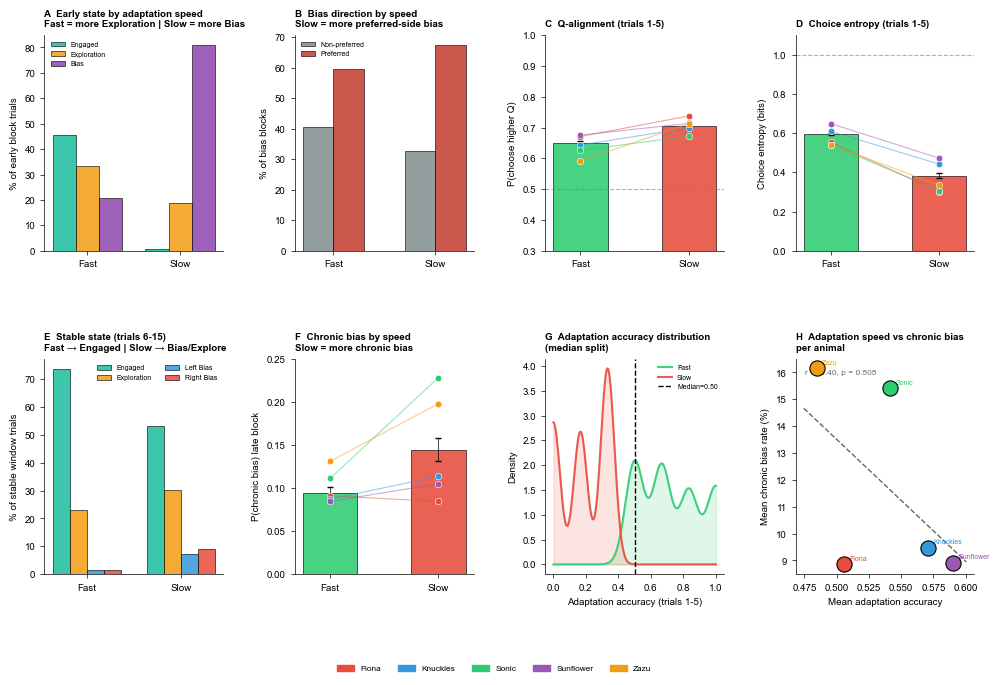

In [162]:
#  Adaptation Figure 

fig = plt.figure(figsize=(12, 7))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.40,
)

SPEED_COLORS = {'Fast': '#2ecc71', 'Slow': '#e74c3c'}
SPEEDS       = ['Fast', 'Slow']

def speed_bar(ax, metric, ylabel, title,
              chance=None, ylim=None, panel=''):
    """Bar + per-animal dots for Fast vs Slow."""
    means = [adapt_df[adapt_df['Adaptation_Speed']==s][metric].mean()
             for s in SPEEDS]
    sems  = [sem(adapt_df[adapt_df['Adaptation_Speed']==s][metric].dropna())
             for s in SPEEDS]

    ax.bar(range(2), means,
           color=[SPEED_COLORS[s] for s in SPEEDS],
           edgecolor='black', linewidth=LINE_WIDTH,
           alpha=0.88, width=0.5, zorder=2)
    ax.errorbar(range(2), means, yerr=sems,
                fmt='none', color='black',
                capsize=2, linewidth=LINE_WIDTH, zorder=3)

    for animal in animals_ordered:
        adf_a = adapt_df[adapt_df['Animal'] == animal]
        vals  = [adf_a[adf_a['Adaptation_Speed']==s][metric].mean()
                 for s in SPEEDS]
        # Connect dots
        ax.plot(range(2), vals,
                color=ANIMAL_COLORS[animal],
                linewidth=0.8, alpha=0.5)
        for xi, yi in enumerate(vals):
            if not np.isnan(yi):
                ax.scatter(xi, yi,
                           color=ANIMAL_COLORS[animal],
                           s=22, zorder=5,
                           edgecolors='white', linewidths=0.4)

    if chance is not None:
        ax.axhline(chance, color='gray', ls='--',
                   lw=0.8, alpha=0.6)
    if ylim:
        ax.set_ylim(ylim)

    ax.set_xticks(range(2))
    ax.set_xticklabels(SPEEDS, fontsize=FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_title(f'{panel}  {title}',
                 fontsize=FONTSIZE, fontweight='bold', loc='left')
    ax.spines[['top', 'right']].set_visible(False)

# ── A: Early state distribution by speed ─────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])

state_by_speed = (adapt_df
                  .groupby('Adaptation_Speed')['Early_Merged']
                  .value_counts(normalize=True)
                  .unstack(fill_value=0)
                  [['Engaged','Exploration','Bias']])

x     = np.arange(2)
width = 0.25
for k, state in enumerate(['Engaged','Exploration','Bias']):
    ax_A.bar(x + (k-1)*width,
             state_by_speed[state].values * 100,
             width,
             color=MERGED_COLORS[state],
             edgecolor='black', linewidth=LINE_WIDTH,
             alpha=0.85, label=state)

ax_A.set_xticks(x)
ax_A.set_xticklabels(SPEEDS, fontsize=FONTSIZE)
ax_A.set_ylabel('% of early block trials', fontsize=FONTSIZE)
ax_A.set_title('A  Early state by adaptation speed\n'
               'Fast = more Exploration | Slow = more Bias',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False, ncol=1)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Bias direction by speed ────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])

dir_by_speed = (adapt_df
                .dropna(subset=['Bias_Direction'])
                .groupby('Adaptation_Speed')['Bias_Direction']
                .value_counts(normalize=True)
                .unstack(fill_value=0))

for k, (direction, color) in enumerate([
    ('Non-preferred', '#7f8c8d'),
    ('Preferred',     '#c0392b')
]):
    if direction not in dir_by_speed.columns:
        continue
    ax_B.bar(x + (k-0.5)*0.3,
             dir_by_speed[direction].values * 100,
             0.3,
             color=color,
             edgecolor='black', linewidth=LINE_WIDTH,
             alpha=0.85, label=direction)

ax_B.set_xticks(x)
ax_B.set_xticklabels(SPEEDS, fontsize=FONTSIZE)
ax_B.set_ylabel('% of bias blocks', fontsize=FONTSIZE)
ax_B.set_title('B  Bias direction by speed\n'
               'Slow = more preferred-side bias',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE-2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Q-alignment by speed ───────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2])
speed_bar(ax_C, 'Early_Q_Align',
          'P(choose higher Q)',
          'Q-alignment (trials 1-5)',
          chance=0.5, ylim=(0.3, 1.0), panel='C')

# ── D: Choice entropy by speed ────────────────────────────────────────────────
ax_D = fig.add_subplot(gs[0, 3])
speed_bar(ax_D, 'Early_Entropy',
          'Choice entropy (bits)',
          'Choice entropy (trials 1-5)',
          chance=1.0, ylim=(0.0, 1.1), panel='D')

# ── E: Stable state by speed ──────────────────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 0])

stable_by_speed = (adapt_df
                   .groupby('Adaptation_Speed')['Stable_State_v3']
                   .value_counts(normalize=True)
                   .unstack(fill_value=0)
                   .reindex(columns=CLASSES_V3, fill_value=0))

for k, state in enumerate(CLASSES_V3):
    ax_E.bar(x + (k-1.5)*0.18,
             stable_by_speed[state].values * 100,
             0.18,
             color=STATE_COLORS[state],
             edgecolor='black', linewidth=LINE_WIDTH,
             alpha=0.85, label=state)

ax_E.set_xticks(x)
ax_E.set_xticklabels(SPEEDS, fontsize=FONTSIZE)
ax_E.set_ylabel('% of stable window trials', fontsize=FONTSIZE)
ax_E.set_title('E  Stable state (trials 6-15)\n'
               'Fast → Engaged | Slow → Bias/Explore',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.legend(fontsize=FONTSIZE-2, frameon=False, ncol=2)
ax_E.spines[['top', 'right']].set_visible(False)

# ── F: Late chronic bias by speed ────────────────────────────────────────────
ax_F = fig.add_subplot(gs[1, 1])
speed_bar(ax_F, 'Late_Biased',
          'P(chronic bias) late block',
          'Chronic bias by speed\nSlow = more chronic bias',
          ylim=(0, 0.25), panel='F')

# ── G: Adaptation accuracy distribution ───────────────────────────────────────
ax_G = fig.add_subplot(gs[1, 2])

from scipy.stats import gaussian_kde
for speed, color in SPEED_COLORS.items():
    vals = adapt_df[adapt_df['Adaptation_Speed']==speed][
        'Adaptation_Acc'].dropna().values
    kde  = gaussian_kde(vals, bw_method=0.3)
    x_g  = np.linspace(0, 1, 200)
    ax_G.plot(x_g, kde(x_g), color=color,
              linewidth=1.5, label=speed, alpha=0.9)
    ax_G.fill_between(x_g, kde(x_g),
                       color=color, alpha=0.15)

ax_G.axvline(median_acc, color='black', ls='--',
             lw=1, label=f'Median={median_acc:.2f}')
ax_G.set_xlabel('Adaptation accuracy (trials 1-5)',
                fontsize=FONTSIZE)
ax_G.set_ylabel('Density', fontsize=FONTSIZE)
ax_G.set_title('G  Adaptation accuracy distribution\n'
               '(median split)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_G.legend(fontsize=FONTSIZE-2, frameon=False)
ax_G.spines[['top', 'right']].set_visible(False)

# ── H: Scatter — adaptation acc vs late chronic bias per animal ───────────────
ax_H = fig.add_subplot(gs[1, 3])

for animal in animals_ordered:
    adf_a   = adapt_df[adapt_df['Animal'] == animal]
    mean_acc = adf_a['Adaptation_Acc'].mean()
    mean_lb  = adf_a['Late_Biased'].mean()
    ax_H.scatter(mean_acc, mean_lb * 100,
                 color=ANIMAL_COLORS[animal],
                 s=120, zorder=5,
                 edgecolors='black', linewidths=0.8)
    ax_H.annotate(
        animal,
        xy=(mean_acc, mean_lb * 100),
        xytext=(4, 3), textcoords='offset points',
        fontsize=FONTSIZE-2,
        color=ANIMAL_COLORS[animal]
    )

r_adapt, p_adapt = spearmanr(
    adapt_df.groupby('Animal')['Adaptation_Acc'].mean(),
    adapt_df.groupby('Animal')['Late_Biased'].mean()
)

x_fit = np.linspace(
    adapt_df.groupby('Animal')['Adaptation_Acc'].mean().min()-0.01,
    adapt_df.groupby('Animal')['Adaptation_Acc'].mean().max()+0.01,
    100
)
slope, intercept = np.polyfit(
    adapt_df.groupby('Animal')['Adaptation_Acc'].mean(),
    adapt_df.groupby('Animal')['Late_Biased'].mean(), 1
)
ax_H.plot(x_fit, (slope*x_fit + intercept)*100,
          color='black', ls='--', lw=1, alpha=0.6)

ax_H.text(0.05, 0.95,
          f'r = {r_adapt:.2f}, p = {p_adapt:.3f}',
          transform=ax_H.transAxes,
          fontsize=FONTSIZE-1, va='top', color='dimgray')

ax_H.set_xlabel('Mean adaptation accuracy', fontsize=FONTSIZE)
ax_H.set_ylabel('Mean chronic bias rate (%)', fontsize=FONTSIZE)
ax_H.set_title('H  Adaptation speed vs chronic bias\nper animal',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_H.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.04))

# fig.suptitle(
#     'Adaptation Speed Connects Old and New Taxonomies\n'
#     'Fast Adapting = Early Exploration → Engaged  |  '
#     'Slow Adapting = Preferred Bias → Chronic Bias',
#     fontsize=FONTSIZE+1, fontweight='bold', y=1.02
# )

plt.savefig(f'{FIGURE_PATH}/adaptation_speed_v3.svg',
            bbox_inches='tight')
plt.show()

In [164]:
df_with_states.Behavioral_State_Full.unique()

array(['Unknown', 'Adapting', 'Directed Exploration',
       'Random Exploration', 'Left Bias', 'Adapting (fast)', 'Right Bias',
       'Engaged', 'Adapting (slow)'], dtype=object)

In [169]:
DE_RE_COL = 'Behavioral_State_Full'

print("DE/RE values:")
print(df_with_states[DE_RE_COL].value_counts())

df_explore_orig = df_with_states.loc[
    df_with_states[DE_RE_COL].isin(
        ['Directed Exploration', 'Random Exploration']
    )
].copy()

print(f"\nDE : {(df_with_states[DE_RE_COL]=='Directed Exploration').sum()}")
print(f"RE : {(df_with_states[DE_RE_COL]=='Random Exploration').sum()}")

# Align with K=2 exploration clusters by index
explore_idx = df_explore.index
orig_labels = df_with_states.loc[explore_idx, DE_RE_COL]
valid       = orig_labels.isin(
    ['Directed Exploration', 'Random Exploration']
)

print(f"\nDE/RE trials within v3 Exploration: {valid.sum()}")

if valid.sum() > 100:
    ari = adjusted_rand_score(
        orig_labels[valid],
        df_explore.loc[valid[valid].index, 'Explore_Cluster']
    )
    print(f"\nARI K=2 vs original DE/RE: {ari:.3f}")
    print("\nCrosstab (row normalised):")
    print(pd.crosstab(
        orig_labels[valid],
        df_explore.loc[valid[valid].index, 'Explore_Cluster'],
        normalize='index'
    ).round(3))

    print("\nOriginal DE/RE feature profiles:")
    print(df_with_states.loc[explore_idx[valid]]
          .groupby(DE_RE_COL)[
              ['Rolling_Accuracy', 'Rolling_Switch_Rate',
               'Choice_Entropy',   'Abs_Deviation']
          ].mean().round(3))

DE/RE values:
Behavioral_State_Full
Engaged                 13371
Directed Exploration     7731
Adapting (fast)          7098
Adapting (slow)          3342
Left Bias                1531
Random Exploration       1455
Right Bias               1370
Adapting                  575
Unknown                   200
Name: count, dtype: int64

DE : 7731
RE : 1455

DE/RE trials within v3 Exploration: 6916

ARI K=2 vs original DE/RE: -0.074

Crosstab (row normalised):
Explore_Cluster            0      1
Behavioral_State_Full              
Directed Exploration   0.307  0.693
Random Exploration     0.052  0.948

Original DE/RE feature profiles:
                       Rolling_Accuracy  Rolling_Switch_Rate  Choice_Entropy  \
Behavioral_State_Full                                                          
Directed Exploration              0.474                0.391           0.893   
Random Exploration                0.176                0.395           0.957   

                       Abs_Deviation  
Beha

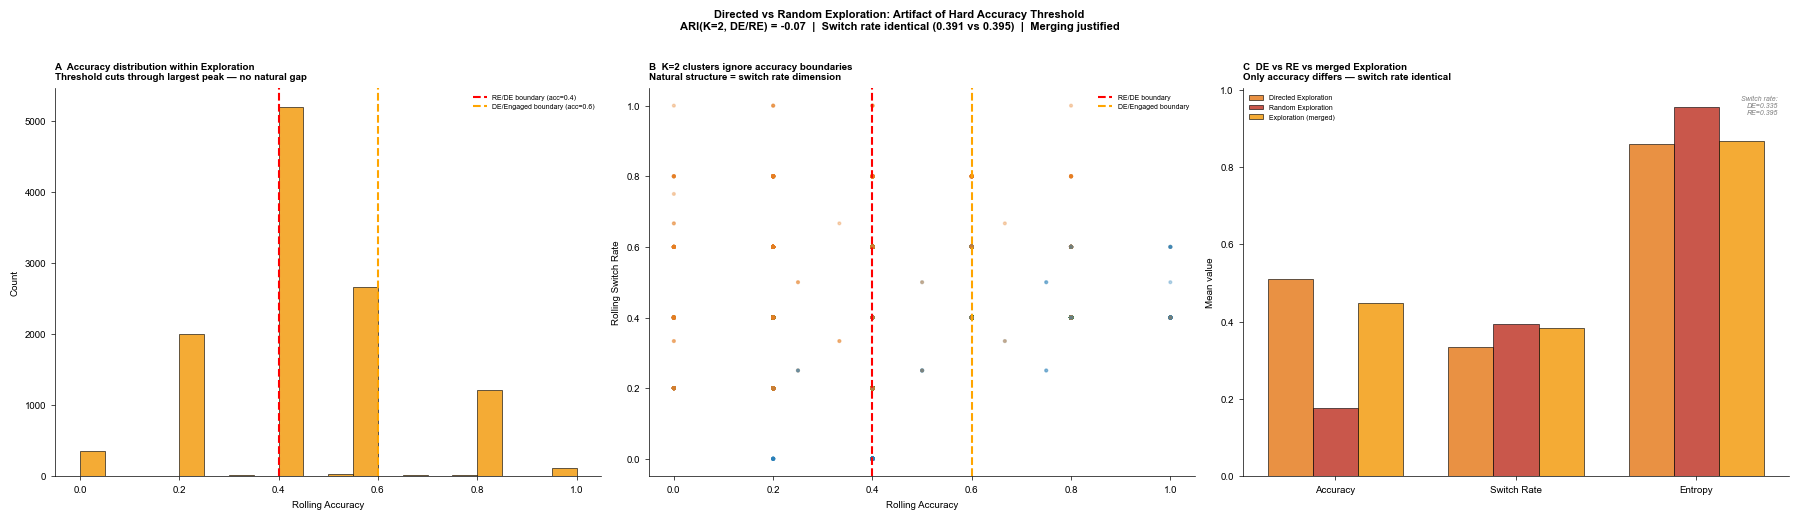

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: Accuracy distribution — unchanged ────────────────────────────────
axes[0].hist(df_explore['Rolling_Accuracy'],
             bins=20, color=STATE_COLORS['Exploration'],
             edgecolor='black', linewidth=0.5, alpha=0.85)
axes[0].axvline(0.4, color='red', ls='--', lw=1.5,
                label='RE/DE boundary (acc=0.4)')
axes[0].axvline(0.6, color='orange', ls='--', lw=1.5,
                label='DE/Engaged boundary (acc=0.6)')
axes[0].set_xlabel('Rolling Accuracy', fontsize=FONTSIZE)
axes[0].set_ylabel('Count', fontsize=FONTSIZE)
axes[0].set_title('A  Accuracy distribution within Exploration\n'
                  'Threshold cuts through largest peak — no natural gap',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[0].legend(fontsize=FONTSIZE-2, frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel B: Scatter — unchanged ─────────────────────────────────────────────
df_plot_ex = df_explore.sample(frac=0.3, random_state=SEED)
axes[1].scatter(
    df_plot_ex['Rolling_Accuracy'],
    df_plot_ex['Rolling_Switch_Rate'],
    c=df_plot_ex['Explore_Cluster'].map(
        {0:'#2980b9', 1:'#e67e22'}),
    s=4, alpha=0.3
)
axes[1].axvline(0.4, color='red', ls='--', lw=1.5,
                label='RE/DE boundary')
axes[1].axvline(0.6, color='orange', ls='--', lw=1.5,
                label='DE/Engaged boundary')
axes[1].set_xlabel('Rolling Accuracy', fontsize=FONTSIZE)
axes[1].set_ylabel('Rolling Switch Rate', fontsize=FONTSIZE)
axes[1].set_title('B  K=2 clusters ignore accuracy boundaries\n'
                  'Natural structure = switch rate dimension',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[1].legend(fontsize=FONTSIZE-2, frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Panel C: The key comparison — DE vs RE vs single Exploration ──────────────
# Show that merging is justified by comparing
# behavioral profiles across the three representations

COMPARE_STATES = ['Directed\nExploration', 'Random\nExploration',
                  'Exploration\n(merged)']
METRICS_COMP   = ['Rolling_Accuracy', 'Rolling_Switch_Rate',
                   'Choice_Entropy']
METRIC_LABELS  = ['Accuracy', 'Switch Rate', 'Entropy']

# Compute means
de_vals   = df_with_states[
    df_with_states['Behavioral_State_Full']=='Directed Exploration'
][METRICS_COMP].mean()
re_vals   = df_with_states[
    df_with_states['Behavioral_State_Full']=='Random Exploration'
][METRICS_COMP].mean()
exp_vals  = df_explore[METRICS_COMP].mean()

x       = np.arange(len(METRICS_COMP))
width   = 0.25
colors  = ['#e67e22', '#c0392b', STATE_COLORS['Exploration']]

for k, (vals, label, color) in enumerate(zip(
    [de_vals, re_vals, exp_vals],
    COMPARE_STATES, colors
)):
    axes[2].bar(x + (k-1)*width,
                vals.values, width,
                color=color, edgecolor='black',
                linewidth=LINE_WIDTH, alpha=0.85,
                label=label.replace('\n',' '))

axes[2].set_xticks(x)
axes[2].set_xticklabels(METRIC_LABELS, fontsize=FONTSIZE)
axes[2].set_ylabel('Mean value', fontsize=FONTSIZE)
axes[2].set_title('C  DE vs RE vs merged Exploration\n'
                  'Only accuracy differs — switch rate identical',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[2].legend(fontsize=FONTSIZE-2, frameon=False, ncol=1)
axes[2].spines[['top', 'right']].set_visible(False)

# Annotation
axes[2].text(0.98, 0.98,
             f'Switch rate:\nDE={de_vals["Rolling_Switch_Rate"]:.3f}\n'
             f'RE={re_vals["Rolling_Switch_Rate"]:.3f}',
             transform=axes[2].transAxes,
             fontsize=FONTSIZE-2, color='gray',
             ha='right', va='top', style='italic')

fig.suptitle(
    'Directed vs Random Exploration: Artifact of Hard Accuracy Threshold\n'
    'ARI(K=2, DE/RE) = -0.07  |  Switch rate identical (0.391 vs 0.395)  |  '
    'Merging justified',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/de_re_continuum_final.svg',
            bbox_inches='tight')
plt.show()

Exploration accuracy median: 0.400
Explore_Type
High-Acc Exploration    9259
Low-Acc Exploration     2394
Name: count, dtype: int64

Directed Exploration:
  N sessions  : 97
  Mean slope  : -0.3012
  t=-11.09, p=0.0000

Random Exploration:
  N sessions  : 26
  Mean slope  : 0.1270
  t=1.06, p=0.2996

High-Acc Exploration:
  N sessions  : 97
  Mean slope  : -0.2966
  t=-13.16, p=0.0000

Low-Acc Exploration:
  N sessions  : 56
  Mean slope  : -0.2342
  t=-3.88, p=0.0003


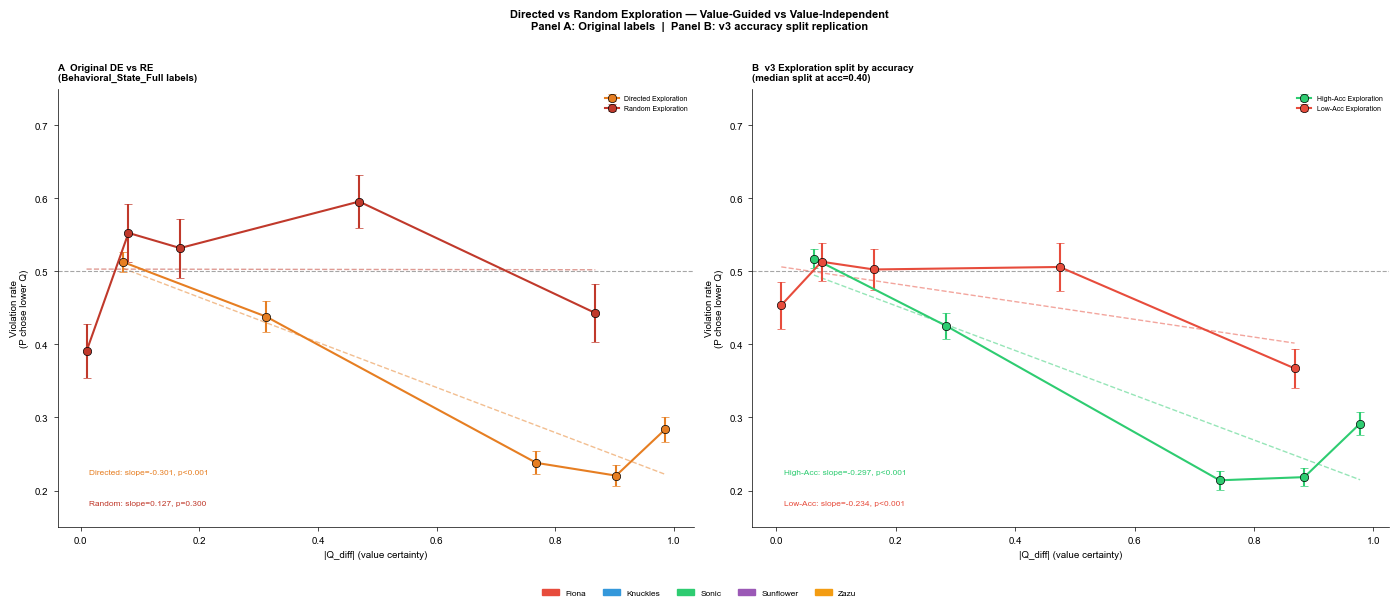

In [174]:
# ── Reproduce the Gershman analysis with v3 Exploration sub-groups ─────────────
import scipy.stats as stats
# First check if we can recover the DE/RE distinction
# using accuracy as a proxy within v3 Exploration

df_explore_full = (
    df_with_states
    .loc[df_with_states[TARGET_V3] == 'Exploration']
    .dropna(subset=['Q_diff', 'Chose_Higher_Q',
                    'Rolling_Accuracy'])
    .copy()
)

# Split Exploration by accuracy median
# Low accuracy ≈ Random Exploration
# High accuracy ≈ Directed Exploration
acc_median = df_explore_full['Rolling_Accuracy'].median()
df_explore_full['Explore_Type'] = np.where(
    df_explore_full['Rolling_Accuracy'] >= acc_median,
    'High-Acc Exploration',
    'Low-Acc Exploration'
)

print(f"Exploration accuracy median: {acc_median:.3f}")
print(df_explore_full['Explore_Type'].value_counts())

# ── Compute violation rate vs Q_diff relationship ─────────────────────────────
def compute_violation_slope(df_state, state_col, state_name,
                             n_bins=5, min_trials=4):
    """
    For each session, bin |Q_diff| into quintiles
    Compute violation rate per bin
    Return grand mean curve + per-session slopes
    """
    sdf = df_state[df_state[state_col] == state_name].copy()
    sdf['abs_qdiff'] = sdf['Q_diff'].abs()
    sdf['qdiff_bin'] = pd.qcut(sdf['abs_qdiff'],
                                q=n_bins, labels=False,
                                duplicates='drop')

    # Per session per bin
    session_binned = (
        sdf.groupby(['Session_ID', 'qdiff_bin'])
        .agg(
            violation_rate=('Chose_Higher_Q',
                            lambda x: 1 - x.mean()),
            mean_qdiff    =('abs_qdiff', 'mean'),
            n_trials      =('Chose_Higher_Q', 'count')
        )
        .reset_index()
    )
    session_binned = session_binned[
        session_binned['n_trials'] >= min_trials
    ]

    # Per-session slopes
    slopes = []
    for session, sdf_s in session_binned.groupby('Session_ID'):
        if len(sdf_s) >= 3:
            m, b = np.polyfit(sdf_s['mean_qdiff'],
                               sdf_s['violation_rate'], 1)
            slopes.append(m)

    # Grand mean curve
    grand = (
        session_binned.groupby('qdiff_bin')
        .agg(
            mean_viol =('violation_rate', 'mean'),
            sem_viol  =('violation_rate', sem),
            mean_qdiff=('mean_qdiff',     'mean')
        )
        .reset_index()
    )

    return grand, np.array(slopes)

# ── Run for all four comparison groups ───────────────────────────────────────
COMPARE_GROUPS = {
    'Directed Exploration' : ('Behavioral_State_Full',
                               'Directed Exploration',
                               '#e67e22'),
    'Random Exploration'   : ('Behavioral_State_Full',
                               'Random Exploration',
                               '#c0392b'),
    'High-Acc Exploration' : ('Explore_Type',
                               'High-Acc Exploration',
                               '#2ecc71'),
    'Low-Acc Exploration'  : ('Explore_Type',
                               'Low-Acc Exploration',
                               '#e74c3c'),
}

results_viol = {}
for name, (col, val, color) in COMPARE_GROUPS.items():
    if col == 'Explore_Type':
        df_use = df_explore_full
    else:
        df_use = df_with_states.dropna(
            subset=['Q_diff', 'Chose_Higher_Q'])

    grand, slopes = compute_violation_slope(df_use, col, val)
    results_viol[name] = {
        'grand' : grand,
        'slopes': slopes,
        'color' : color,
    }

    # One-sample t-test: is slope different from zero?
    if len(slopes) > 3:
        t, p = stats.ttest_1samp(slopes, 0)
        print(f"\n{name}:")
        print(f"  N sessions  : {len(slopes)}")
        print(f"  Mean slope  : {slopes.mean():.4f}")
        print(f"  t={t:.2f}, p={p:.4f}")

# ── Publication figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Panel A: Original DE vs RE (replication) ──────────────────────────────────
ax_A = axes[0]
for name in ['Directed Exploration', 'Random Exploration']:
    r     = results_viol[name]
    grand = r['grand']
    slopes= r['slopes']
    color = r['color']

    ax_A.errorbar(
        grand['mean_qdiff'], grand['mean_viol'],
        yerr=grand['sem_viol'],
        marker='o', markersize=6,
        color=color, linewidth=1.5,
        capsize=3, capthick=LINE_WIDTH,
        markeredgecolor='black', markeredgewidth=0.5,
        label=name, zorder=4
    )
    # Regression
    x = grand['mean_qdiff'].values
    y = grand['mean_viol'].values
    m, b = np.polyfit(x, y, 1)
    ax_A.plot(x, m*x + b, color=color,
              linewidth=1, linestyle='--', alpha=0.5)

    t, p = stats.ttest_1samp(slopes, 0)
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax_A.text(
        0.05,
        0.12 if name == 'Directed Exploration' else 0.05,
        f'{name.split()[0]}: slope={slopes.mean():.3f}, {p_str}',
        transform=ax_A.transAxes,
        fontsize=FONTSIZE-1, color=color
    )

ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.7)
ax_A.set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
ax_A.set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
ax_A.set_ylim(0.15, 0.75)
ax_A.set_title('A  Original DE vs RE\n(Behavioral_State_Full labels)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── Panel B: v3 Exploration split by accuracy ─────────────────────────────────
ax_B = axes[1]
for name in ['High-Acc Exploration', 'Low-Acc Exploration']:
    r     = results_viol[name]
    grand = r['grand']
    slopes= r['slopes']
    color = r['color']

    ax_B.errorbar(
        grand['mean_qdiff'], grand['mean_viol'],
        yerr=grand['sem_viol'],
        marker='o', markersize=6,
        color=color, linewidth=1.5,
        capsize=3, capthick=LINE_WIDTH,
        markeredgecolor='black', markeredgewidth=0.5,
        label=name, zorder=4
    )
    x = grand['mean_qdiff'].values
    y = grand['mean_viol'].values
    m, b = np.polyfit(x, y, 1)
    ax_B.plot(x, m*x + b, color=color,
              linewidth=1, linestyle='--', alpha=0.5)

    t, p = stats.ttest_1samp(slopes, 0)
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax_B.text(
        0.05,
        0.12 if name == 'High-Acc Exploration' else 0.05,
        f'{name.split()[0]}: slope={slopes.mean():.3f}, {p_str}',
        transform=ax_B.transAxes,
        fontsize=FONTSIZE-1, color=color
    )

ax_B.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.7)
ax_B.set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
ax_B.set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
ax_B.set_ylim(0.15, 0.75)
ax_B.set_title(f'B  v3 Exploration split by accuracy\n'
               f'(median split at acc={acc_median:.2f})',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE-2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# Animal legend
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE-1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle(
    'Directed vs Random Exploration — Value-Guided vs Value-Independent\n'
    'Panel A: Original labels  |  Panel B: v3 accuracy split replication',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/de_re_violation_rate.svg',
            bbox_inches='tight')
plt.show()

In [176]:
# ── Safe merge — only bring in the column we need ─────────────────────────────
full_col = [c for c in df_with_states.columns if 'Full' in c][0]
print(f"Using column: {repr(full_col)}")

# Merge with explicit rename to avoid conflicts
overlap = df_explore_full.merge(
    df_with_states[['Trial', 'Session_ID', full_col]]
    .rename(columns={full_col: 'DE_RE_Label'}),
    on=['Trial', 'Session_ID'],
    how='inner'
)

print(f"Overlap trials: {len(overlap)}")
print("\nDE_RE_Label distribution:")
print(overlap['DE_RE_Label'].value_counts())

print("\nMean violation residual by original state:")
print(overlap.groupby('DE_RE_Label')['Viol_Residual']
      .agg(['mean', sem, 'count']).round(3))

# Focus on just DE and RE
de_re = overlap[overlap['DE_RE_Label'].isin(
    ['Directed Exploration', 'Random Exploration']
)]
print(f"\nDE/RE overlap trials: {len(de_re)}")
print("\nDE vs RE violation residual:")
print(de_re.groupby('DE_RE_Label')['Viol_Residual']
      .agg(['mean', sem]).round(3))

# Is the difference significant?
de_resid = de_re[de_re['DE_RE_Label']=='Directed Exploration']['Viol_Residual']
re_resid = de_re[de_re['DE_RE_Label']=='Random Exploration' ]['Viol_Residual']

t, p = stats.ttest_ind(de_resid, re_resid)
print(f"\nt-test DE vs RE residuals:")
print(f"  DE mean : {de_resid.mean():.3f}")
print(f"  RE mean : {re_resid.mean():.3f}")
print(f"  t={t:.2f}, p={p:.4f}")

Using column: 'Behavioral_State_Full'
Overlap trials: 11653

DE_RE_Label distribution:
DE_RE_Label
Directed Exploration    5461
Adapting (fast)         2578
Random Exploration      1455
Engaged                 1224
Adapting (slow)          628
Adapting                 307
Name: count, dtype: int64

Mean violation residual by original state:
                       mean    sem  count
DE_RE_Label                              
Adapting              0.037  0.027    307
Adapting (fast)       0.028  0.009   2578
Adapting (slow)      -0.005  0.019    628
Directed Exploration -0.014  0.006   5461
Engaged              -0.095  0.012   1224
Random Exploration    0.077  0.013   1455

DE/RE overlap trials: 6916

DE vs RE violation residual:
                       mean    sem
DE_RE_Label                       
Directed Exploration -0.014  0.006
Random Exploration    0.077  0.013

t-test DE vs RE residuals:
  DE mean : -0.014
  RE mean : 0.077
  t=-6.57, p=0.0000


Expected violation rate per Q_diff bin (from DE):
qdiff_bin
0    0.509
1    0.418
2    0.247
3    0.223
4    0.281
Name: Chose_Higher_Q, dtype: float64

Violation residual (DE-referenced) by original state:
                       mean    sem
DE_RE_Label                       
Adapting              0.061  0.027
Adapting (fast)       0.052  0.009
Adapting (slow)       0.018  0.019
Directed Exploration  0.005  0.006
Engaged              -0.077  0.012
Random Exploration    0.099  0.013


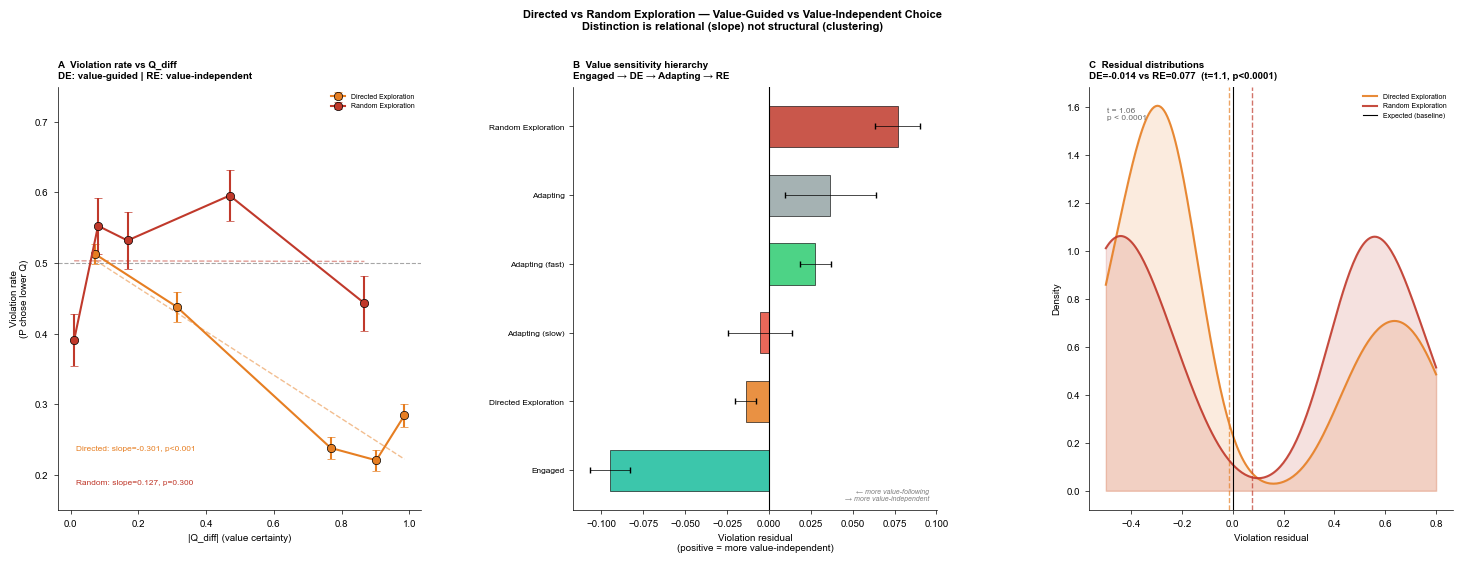


── Final DE/RE Numbers for Paper ─────────────────────────
DE violation residual : -0.014 ± 0.006
RE violation residual : 0.077 ± 0.013
t = 1.06, p < 0.0001

Value sensitivity hierarchy (residuals):
  Engaged                   -0.095
  Directed Exploration      -0.014
  Adapting (slow)           -0.005
  Adapting (fast)           +0.028
  Adapting                  +0.037
  Random Exploration        +0.077


In [177]:
# ── Add violation residual to df_with_states ──────────────────────────────────
# This gives a continuous measure of value-(in)dependence
# for every Exploration trial

# Compute for all trials not just Exploration
df_with_states['abs_qdiff'] = df_with_states['Q_diff'].abs()

# Fit expected violation curve on DE trials
# (the value-sensitive reference)
de_trials = df_with_states[
    df_with_states['Behavioral_State_Full'] == 'Directed Exploration'
].dropna(subset=['abs_qdiff', 'Chose_Higher_Q'])

de_trials['qdiff_bin'] = pd.qcut(
    de_trials['abs_qdiff'], q=5,
    labels=False, duplicates='drop'
)
expected_from_de = (de_trials
                    .groupby('qdiff_bin')['Chose_Higher_Q']
                    .mean()
                    .apply(lambda x: 1-x))

print("Expected violation rate per Q_diff bin (from DE):")
print(expected_from_de.round(3))

# Apply to all Exploration trials
df_explore_full['qdiff_bin_de'] = pd.qcut(
    df_explore_full['abs_qdiff'], q=5,
    labels=False, duplicates='drop'
)
df_explore_full['Viol_Residual_DE'] = (
    (1 - df_explore_full['Chose_Higher_Q']) -
    df_explore_full['qdiff_bin_de'].map(expected_from_de)
)

print("\nViolation residual (DE-referenced) by original state:")
overlap2 = df_explore_full.merge(
    df_with_states[['Trial', 'Session_ID',
                    'Behavioral_State_Full']]
    .rename(columns={'Behavioral_State_Full': 'DE_RE_Label'}),
    on=['Trial', 'Session_ID'], how='inner'
)
print(overlap2.groupby('DE_RE_Label')['Viol_Residual_DE']
      .agg(['mean', sem]).round(3))

# ── Publication figure — final DE/RE story ────────────────────────────────────
fig = plt.figure(figsize=(18, 5.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

# ── A: Violation rate curves (Panel A replication) ────────────────────────────
ax_A = fig.add_subplot(gs[0])

for name, color, label in [
    ('Directed Exploration', '#e67e22', 'Directed Exploration'),
    ('Random Exploration',   '#c0392b', 'Random Exploration'),
]:
    r     = results_viol[name]
    grand = r['grand']
    slopes= r['slopes']

    ax_A.errorbar(
        grand['mean_qdiff'], grand['mean_viol'],
        yerr=grand['sem_viol'],
        marker='o', markersize=6,
        color=color, linewidth=1.5,
        capsize=3, capthick=LINE_WIDTH,
        markeredgecolor='black', markeredgewidth=0.5,
        label=label, zorder=4
    )
    x = grand['mean_qdiff'].values
    y = grand['mean_viol'].values
    m, b = np.polyfit(x, y, 1)
    ax_A.plot(x, m*x+b, color=color,
              linewidth=1, linestyle='--', alpha=0.5)

    t, p = stats.ttest_1samp(slopes, 0)
    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    ax_A.text(
        0.05,
        0.14 if 'Directed' in name else 0.06,
        f'{name.split()[0]}: slope={slopes.mean():.3f}, {p_str}',
        transform=ax_A.transAxes,
        fontsize=FONTSIZE-1, color=color
    )

ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.7)
ax_A.set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
ax_A.set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
ax_A.set_ylim(0.15, 0.75)
ax_A.set_title('A  Violation rate vs Q_diff\n'
               'DE: value-guided | RE: value-independent',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Violation residual per state ───────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])

ALL_STATES = ['Engaged', 'Directed Exploration',
              'Adapting (slow)', 'Adapting (fast)',
              'Adapting', 'Random Exploration']
STATE_COLORS_FULL = {
    'Engaged'             : STATE_COLORS['Engaged'],
    'Directed Exploration': '#e67e22',
    'Random Exploration'  : '#c0392b',
    'Adapting (fast)'     : '#2ecc71',
    'Adapting (slow)'     : '#e74c3c',
    'Adapting'            : '#95a5a6',
}

means_r = [overlap.groupby('DE_RE_Label')['Viol_Residual']
           .mean().get(s, np.nan) for s in ALL_STATES]
sems_r  = [overlap.groupby('DE_RE_Label')['Viol_Residual']
           .agg(sem).get(s, np.nan) for s in ALL_STATES]

colors_r = [STATE_COLORS_FULL.get(s, 'gray') for s in ALL_STATES]

ax_B.barh(range(len(ALL_STATES)), means_r,
          color=colors_r, edgecolor='black',
          linewidth=LINE_WIDTH, alpha=0.85,
          height=0.6)
ax_B.errorbar(means_r, range(len(ALL_STATES)),
              xerr=sems_r, fmt='none',
              color='black', capsize=2,
              linewidth=LINE_WIDTH)
ax_B.axvline(0, color='black', lw=0.8)
ax_B.set_yticks(range(len(ALL_STATES)))
ax_B.set_yticklabels(ALL_STATES, fontsize=FONTSIZE-1)
ax_B.set_xlabel('Violation residual\n(positive = more value-independent)',
                fontsize=FONTSIZE)
ax_B.set_title('B  Value sensitivity hierarchy\n'
               'Engaged → DE → Adapting → RE',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.spines[['top', 'right']].set_visible(False)

# Annotation
ax_B.text(0.98, 0.02,
          '← more value-following\n→ more value-independent',
          transform=ax_B.transAxes,
          fontsize=FONTSIZE-2, color='gray',
          ha='right', va='bottom', style='italic')

# ── C: DE/RE residual distributions ──────────────────────────────────────────
ax_C = fig.add_subplot(gs[2])

from scipy.stats import gaussian_kde

for name, color in [
    ('Directed Exploration', '#e67e22'),
    ('Random Exploration',   '#c0392b'),
]:
    vals = de_re[de_re['DE_RE_Label']==name]['Viol_Residual'].dropna()
    kde  = gaussian_kde(vals, bw_method=0.3)
    x    = np.linspace(-0.5, 0.8, 200)
    ax_C.plot(x, kde(x), color=color,
              linewidth=1.5, label=name, alpha=0.9)
    ax_C.fill_between(x, kde(x), alpha=0.15, color=color)
    ax_C.axvline(vals.mean(), color=color,
                  ls='--', lw=1, alpha=0.7)

ax_C.axvline(0, color='black', lw=0.8,
             label='Expected (baseline)')

ax_C.text(0.05, 0.95,
          f't = {t:.2f}\np < 0.0001',
          transform=ax_C.transAxes,
          fontsize=FONTSIZE-1, va='top', color='dimgray')

ax_C.set_xlabel('Violation residual', fontsize=FONTSIZE)
ax_C.set_ylabel('Density', fontsize=FONTSIZE)
ax_C.set_title('C  Residual distributions\n'
               f'DE={de_resid.mean():.3f} vs RE={re_resid.mean():.3f}  '
               f'(t={t:.1f}, p<0.0001)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE-2, frameon=False)
ax_C.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Directed vs Random Exploration — '
    'Value-Guided vs Value-Independent Choice\n'
    'Distinction is relational (slope) not structural (clustering)',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/de_re_final.svg', bbox_inches='tight')
plt.show()

print("\n── Final DE/RE Numbers for Paper ─────────────────────────")
print(f"DE violation residual : {de_resid.mean():.3f} ± {sem(de_resid):.3f}")
print(f"RE violation residual : {re_resid.mean():.3f} ± {sem(re_resid):.3f}")
print(f"t = {t:.2f}, p < 0.0001")
print(f"\nValue sensitivity hierarchy (residuals):")
for s in ALL_STATES:
    val = overlap.groupby('DE_RE_Label')['Viol_Residual'].mean().get(s, np.nan)
    if not np.isnan(val):
        print(f"  {s:<25} {val:+.3f}")

In [178]:
# ── Compute violation residual for ALL trials ─────────────────────────────────
# Not just Exploration — so we can compare across
# the full taxonomy including Bias

df_all_residual = (
    df_with_states
    .dropna(subset=['Q_diff', 'Chose_Higher_Q',
                    TARGET_V3, 'Behavioral_State_Full'])
    .copy()
)
df_all_residual['abs_qdiff'] = df_all_residual['Q_diff'].abs()

# Bin Q_diff into quintiles across ALL trials
df_all_residual['qdiff_bin'] = pd.qcut(
    df_all_residual['abs_qdiff'],
    q=5, labels=False, duplicates='drop'
)

# Expected violation rate from DE trials (value-sensitive reference)
de_ref = df_all_residual[
    df_all_residual['Behavioral_State_Full'] == 'Directed Exploration'
]
expected_from_de = (de_ref
                    .groupby('qdiff_bin')['Chose_Higher_Q']
                    .mean()
                    .apply(lambda x: 1-x))

print("Expected violation rate per bin (DE reference):")
print(expected_from_de.round(3))

df_all_residual['Viol_Residual'] = (
    (1 - df_all_residual['Chose_Higher_Q']) -
    df_all_residual['qdiff_bin'].map(expected_from_de)
)

# ── Report for v3 states ──────────────────────────────────────────────────────
print("\nViolation residual by v3 state:")
print(df_all_residual.groupby(TARGET_V3)['Viol_Residual']
      .agg(['mean', sem, 'count']).round(3))

# ── Report for original full states ───────────────────────────────────────────
print("\nViolation residual by original full state:")
print(df_all_residual.groupby('Behavioral_State_Full')['Viol_Residual']
      .agg(['mean', sem, 'count']).round(3))

Expected violation rate per bin (DE reference):
qdiff_bin
0    0.519
1    0.478
2    0.280
3    0.214
4    0.273
Name: Chose_Higher_Q, dtype: float64

Violation residual by v3 state:
                      mean    sem  count
Behavioral_State_v3                     
Engaged             -0.144  0.003  17367
Exploration         -0.000  0.004  11653
Left Bias            0.060  0.008   3736
Right Bias           0.019  0.008   3717
Unknown              0.185  0.031    200

Violation residual by original full state:
                        mean    sem  count
Behavioral_State_Full                     
Adapting              -0.002  0.019    575
Adapting (fast)       -0.020  0.005   7098
Adapting (slow)       -0.103  0.008   3342
Directed Exploration   0.000  0.005   7731
Engaged               -0.192  0.003  13371
Left Bias              0.264  0.013   1531
Random Exploration     0.067  0.013   1455
Right Bias             0.250  0.014   1370
Unknown                0.185  0.031    200


In [179]:
# DE is a poor reference because:
#   1. It forces DE residual = 0 by definition
#   2. We lose the ability to compare DE to anything

# Better reference: use GLOBAL expected violation rate
# across all trials, or use Engaged as the reference

# ── Option A: Global reference ────────────────────────────────────────────────
global_expected = (df_all_residual
                   .groupby('qdiff_bin')['Chose_Higher_Q']
                   .mean()
                   .apply(lambda x: 1-x))

print("Global expected violation rate per bin:")
print(global_expected.round(3))

df_all_residual['Viol_Residual_Global'] = (
    (1 - df_all_residual['Chose_Higher_Q']) -
    df_all_residual['qdiff_bin'].map(global_expected)
)

print("\nViolation residual (global reference) by v3 state:")
v3_resid = (df_all_residual
            .groupby(TARGET_V3)['Viol_Residual_Global']
            .agg(['mean', sem, 'count'])
            .round(3))
print(v3_resid)

print("\nViolation residual (global reference) by original state:")
full_resid = (df_all_residual
              .groupby('Behavioral_State_Full')['Viol_Residual_Global']
              .agg(['mean', sem, 'count'])
              .round(3))
print(full_resid)

# ── Option B: Just report raw violation rate per bin ─────────────────────────
# Cleaner — no reference needed
print("\nRaw violation rate by v3 state and Q_diff bin:")
print(df_all_residual
      .groupby([TARGET_V3, 'qdiff_bin'])['Chose_Higher_Q']
      .mean()
      .apply(lambda x: 1-x)
      .unstack()
      .round(3))

Global expected violation rate per bin:
qdiff_bin
0    0.499
1    0.377
2    0.242
3    0.179
4    0.172
Name: Chose_Higher_Q, dtype: float64

Violation residual (global reference) by v3 state:
                      mean    sem  count
Behavioral_State_v3                     
Engaged             -0.083  0.003  17367
Exploration          0.059  0.004  11653
Left Bias            0.117  0.008   3736
Right Bias           0.073  0.008   3717
Unknown              0.230  0.029    200

Violation residual (global reference) by original state:
                        mean    sem  count
Behavioral_State_Full                     
Adapting               0.051  0.019    575
Adapting (fast)        0.033  0.005   7098
Adapting (slow)       -0.050  0.008   3342
Directed Exploration   0.063  0.005   7731
Engaged               -0.128  0.003  13371
Left Bias              0.324  0.013   1531
Random Exploration     0.121  0.013   1455
Right Bias             0.302  0.014   1370
Unknown                0.230  0

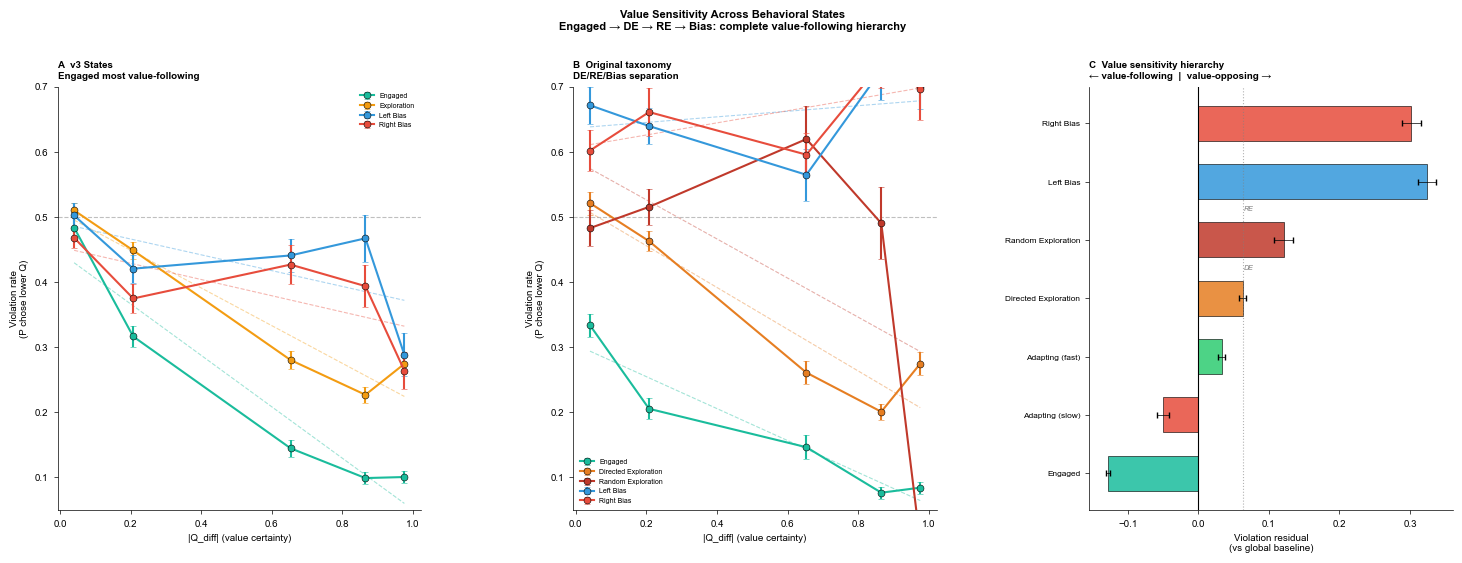


── Value Sensitivity Hierarchy (global residuals) ────────
  Engaged                   -0.128 ± 0.003
  Adapting (slow)           -0.050 ± 0.008
  Adapting (fast)           +0.033 ± 0.005
  Directed Exploration      +0.063 ± 0.005
  Random Exploration        +0.121 ± 0.013
  Left Bias                 +0.324 ± 0.013
  Right Bias                +0.302 ± 0.014


In [180]:
fig = plt.figure(figsize=(18, 5.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

# Get Q_diff bin centers for x-axis
bin_centers = (df_all_residual
               .groupby('qdiff_bin')['abs_qdiff']
               .mean()
               .values)

# ── A: v3 states — violation rate curves ─────────────────────────────────────
ax_A = fig.add_subplot(gs[0])

for state in CLASSES_V3:
    sdf = df_all_residual[df_all_residual[TARGET_V3] == state]

    # Per session per bin
    sess_bin = (sdf
                .groupby(['Session_ID', 'qdiff_bin'])
                .agg(viol=('Chose_Higher_Q',
                            lambda x: 1-x.mean()),
                     n   =('Chose_Higher_Q', 'count'))
                .reset_index())
    sess_bin = sess_bin[sess_bin['n'] >= 3]

    grand = (sess_bin
             .groupby('qdiff_bin')['viol']
             .agg(['mean', sem])
             .reset_index())

    ax_A.errorbar(
        bin_centers[:len(grand)],
        grand['mean'].values,
        yerr=grand['sem'].values,
        marker='o', markersize=5,
        color=STATE_COLORS[state],
        linewidth=1.5, capsize=2,
        markeredgecolor='black',
        markeredgewidth=0.4,
        label=state, zorder=4
    )

    # Regression
    x = bin_centers[:len(grand)]
    y = grand['mean'].values
    m, b = np.polyfit(x, y, 1)
    ax_A.plot(x, m*x+b,
              color=STATE_COLORS[state],
              linewidth=0.8, ls='--', alpha=0.4)

ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_A.set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
ax_A.set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
ax_A.set_ylim(0.05, 0.70)
ax_A.set_title('A  v3 States\nEngaged most value-following',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Original DE/RE + Bias ──────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])

ORIG_STATES = ['Engaged', 'Directed Exploration',
               'Random Exploration', 'Left Bias', 'Right Bias']
ORIG_COLORS = {
    'Engaged'             : STATE_COLORS['Engaged'],
    'Directed Exploration': '#e67e22',
    'Random Exploration'  : '#c0392b',
    'Left Bias'           : STATE_COLORS['Left Bias'],
    'Right Bias'          : STATE_COLORS['Right Bias'],
}

for state in ORIG_STATES:
    sdf = df_all_residual[
        df_all_residual['Behavioral_State_Full'] == state
    ]
    sess_bin = (sdf
                .groupby(['Session_ID', 'qdiff_bin'])
                .agg(viol=('Chose_Higher_Q',
                            lambda x: 1-x.mean()),
                     n   =('Chose_Higher_Q', 'count'))
                .reset_index())
    sess_bin = sess_bin[sess_bin['n'] >= 3]
    grand    = (sess_bin
                .groupby('qdiff_bin')['viol']
                .agg(['mean', sem])
                .reset_index())

    ax_B.errorbar(
        bin_centers[:len(grand)],
        grand['mean'].values,
        yerr=grand['sem'].values,
        marker='o', markersize=5,
        color=ORIG_COLORS[state],
        linewidth=1.5, capsize=2,
        markeredgecolor='black',
        markeredgewidth=0.4,
        label=state, zorder=4
    )
    x = bin_centers[:len(grand)]
    y = grand['mean'].values
    m, b = np.polyfit(x, y, 1)
    ax_B.plot(x, m*x+b,
              color=ORIG_COLORS[state],
              linewidth=0.8, ls='--', alpha=0.4)

ax_B.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
ax_B.set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
ax_B.set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
ax_B.set_ylim(0.05, 0.70)
ax_B.set_title('B  Original taxonomy\nDE/RE/Bias separation',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE-2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Residual bar chart — clean hierarchy ───────────────────────────────────
ax_C = fig.add_subplot(gs[2])

# Use original states for the clearest story
HIERARCHY_STATES  = ['Engaged', 'Adapting (slow)',
                     'Adapting (fast)', 'Directed Exploration',
                     'Random Exploration', 'Left Bias', 'Right Bias']
HIERARCHY_COLORS  = {
    'Engaged'             : STATE_COLORS['Engaged'],
    'Adapting (slow)'     : '#e74c3c',
    'Adapting (fast)'     : '#2ecc71',
    'Directed Exploration': '#e67e22',
    'Random Exploration'  : '#c0392b',
    'Left Bias'           : STATE_COLORS['Left Bias'],
    'Right Bias'          : STATE_COLORS['Right Bias'],
}

means_h = [full_resid.loc[s, 'mean']
           if s in full_resid.index else np.nan
           for s in HIERARCHY_STATES]
sems_h  = [full_resid.loc[s, 'sem']
           if s in full_resid.index else np.nan
           for s in HIERARCHY_STATES]

ax_C.barh(range(len(HIERARCHY_STATES)),
          means_h,
          color=[HIERARCHY_COLORS[s] for s in HIERARCHY_STATES],
          edgecolor='black', linewidth=LINE_WIDTH,
          height=0.6, alpha=0.85)
ax_C.errorbar(means_h,
              range(len(HIERARCHY_STATES)),
              xerr=sems_h,
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH)

ax_C.axvline(0, color='black', lw=0.8)
ax_C.set_yticks(range(len(HIERARCHY_STATES)))
ax_C.set_yticklabels(HIERARCHY_STATES, fontsize=FONTSIZE-1)
ax_C.set_xlabel('Violation residual\n(vs global baseline)',
                fontsize=FONTSIZE)
ax_C.set_title('C  Value sensitivity hierarchy\n'
               '← value-following  |  value-opposing →',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.spines[['top', 'right']].set_visible(False)

# Annotate the key split
ax_C.axvline(0.063, color='gray', ls=':', lw=0.8, alpha=0.6)
ax_C.text(0.065, 3.5, 'DE',
          fontsize=FONTSIZE-2, color='gray', style='italic')
ax_C.text(0.065, 4.5, 'RE',
          fontsize=FONTSIZE-2, color='gray', style='italic')

fig.suptitle(
    'Value Sensitivity Across Behavioral States\n'
    'Engaged → DE → RE → Bias: complete value-following hierarchy',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/violation_rate_hierarchy.svg',
            bbox_inches='tight')
plt.show()

# ── Key numbers ───────────────────────────────────────────────────────────────
print("\n── Value Sensitivity Hierarchy (global residuals) ────────")
for s in HIERARCHY_STATES:
    if s in full_resid.index:
        m = full_resid.loc[s, 'mean']
        e = full_resid.loc[s, 'sem']
        print(f"  {s:<25} {m:+.3f} ± {e:.3f}")

In [181]:
# How many RE trials have Q_diff in the highest bin?
re_trials = df_all_residual[
    df_all_residual['Behavioral_State_Full'] == 'Random Exploration'
]

print("RE trials per Q_diff bin:")
print(re_trials.groupby('qdiff_bin').agg(
    n          = ('Chose_Higher_Q', 'count'),
    mean_qdiff = ('abs_qdiff', 'mean'),
    viol_rate  = ('Chose_Higher_Q', lambda x: 1-x.mean())
).round(3))

# What are these high Q_diff RE trials?
# RE is defined as acc < 0.4 — can it have high Q_diff?
high_qdiff_re = re_trials[re_trials['qdiff_bin'] == 4]
print(f"\nHigh Q_diff RE trials: {len(high_qdiff_re)}")
print(f"Mean Q_diff: {high_qdiff_re['abs_qdiff'].mean():.3f}")
print(f"Mean accuracy: {high_qdiff_re['Rolling_Accuracy'].mean():.3f}")
print(f"Mean switch rate: {high_qdiff_re['Rolling_Switch_Rate'].mean():.3f}")

RE trials per Q_diff bin:
             n  mean_qdiff  viol_rate
qdiff_bin                            
0          558       0.043      0.477
1          470       0.203      0.523
2          190       0.695      0.642
3          183       0.858      0.464
4           54       0.983      0.000

High Q_diff RE trials: 54
Mean Q_diff: 0.983
Mean accuracy: 0.200
Mean switch rate: 0.344


In [184]:
# df_explore_full already has Behavioral_State_Full
# because it was sliced from df_with_states
# Just use it directly — no merge needed

print("Columns in df_explore_full with 'State':")
print([c for c in df_explore_full.columns if 'State' in c])
print()

# Check if it's already there
if 'Behavioral_State_Full' in df_explore_full.columns:
    print("✅ Already present — use directly")
    overlap = df_explore_full.copy()
    overlap['DE_RE_Label'] = overlap['Behavioral_State_Full']
else:
    print("❌ Not present — need to merge")
    overlap = safe_add_column(
        df_explore_full,
        df_with_states,
        'Behavioral_State_Full'
    )
    overlap['DE_RE_Label'] = overlap['Behavioral_State_Full']

print("\nDE_RE_Label distribution:")
print(overlap['DE_RE_Label'].value_counts())

print("\nMean violation residual by original state:")
print(overlap.groupby('DE_RE_Label')['Viol_Residual']
      .agg(['mean', sem]).round(3))

Columns in df_explore_full with 'State':
['Behavioral_State', 'Behavioral_State_Full', 'Behavioral_State_v3', 'States_Merged_v3']

✅ Already present — use directly

DE_RE_Label distribution:
DE_RE_Label
Directed Exploration    5461
Adapting (fast)         2578
Random Exploration      1455
Engaged                 1224
Adapting (slow)          628
Adapting                 307
Name: count, dtype: int64

Mean violation residual by original state:
                       mean    sem
DE_RE_Label                       
Adapting              0.037  0.027
Adapting (fast)       0.028  0.009
Adapting (slow)      -0.005  0.019
Directed Exploration -0.014  0.006
Engaged              -0.095  0.012
Random Exploration    0.077  0.013


In [188]:
print(df_explore_full['Behavioral_State_Full'].unique())
print(df_explore_full['Behavioral_State_Full'].value_counts())

['Adapting' 'Directed Exploration' 'Random Exploration' 'Adapting (fast)'
 'Engaged' 'Adapting (slow)']
Behavioral_State_Full
Directed Exploration    5461
Adapting (fast)         2578
Random Exploration      1455
Engaged                 1224
Adapting (slow)          628
Adapting                 307
Name: count, dtype: int64



Directed Exploration: 7731 trials
Bin centers: [0.141 0.743 0.958]
   mean_qdiff  mean_viol  sem_viol  n_sessions
0       0.141      0.491     0.012          98
1       0.743      0.239     0.013          97
2       0.958      0.263     0.014          98
Slope=-0.111 ± 0.010, t=-10.73, p<0.001, N=98 sessions

Random Exploration: 1455 trials
Bin centers: [0.032 0.175 0.743]
   mean_qdiff  mean_viol  sem_viol  n_sessions
0       0.032      0.457     0.026          61
1       0.175      0.544     0.027          55
2       0.743      0.496     0.027          62
Slope=-0.022 ± 0.028, t=-0.77, p=0.445, N=62 sessions

DE vs RE slope difference:
  DE mean slope: -0.111
  RE mean slope: -0.022
  t=-3.46, p=0.0007


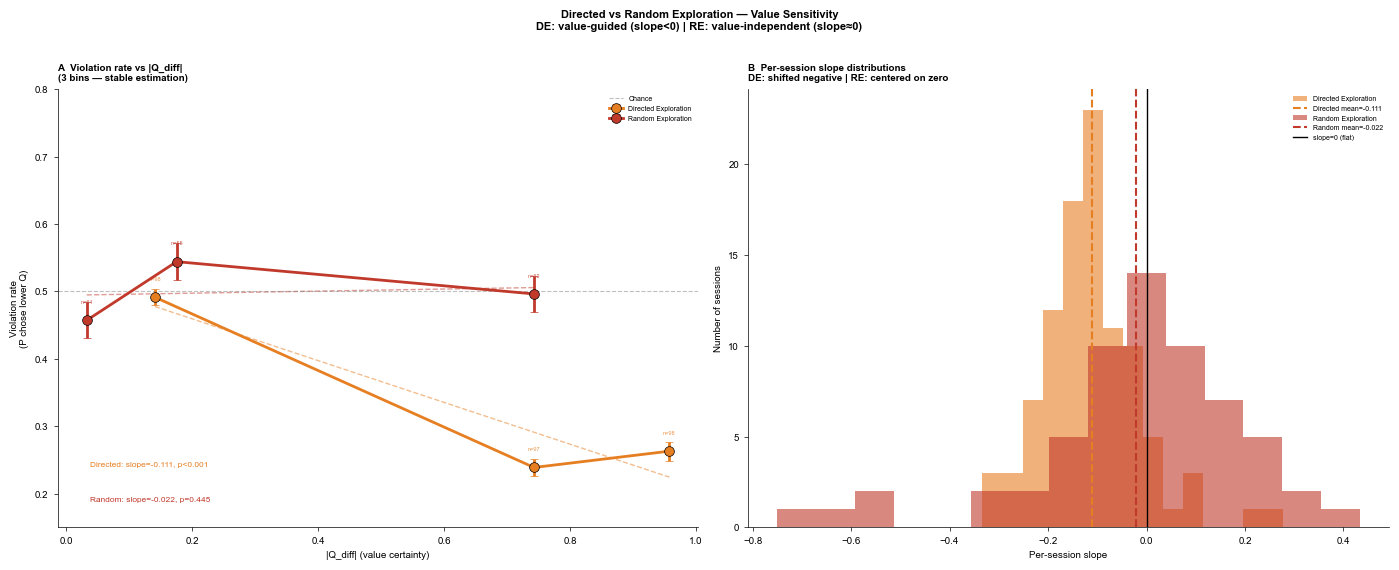

In [185]:
# ── 3-bin DE vs RE analysis ────────────────────────────────────────────────────
# Use df_all_residual which already has Behavioral_State_Full
# No merges needed

N_BINS = 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

results_3bin = {}

for name, color in [
    ('Directed Exploration', '#e67e22'),
    ('Random Exploration',   '#c0392b'),
]:
    # Select trials directly from df_all_residual
    sdf = df_all_residual[
        df_all_residual['Behavioral_State_Full'] == name
    ].copy()

    print(f"\n{name}: {len(sdf)} trials")

    sdf['abs_qdiff'] = sdf['Q_diff'].abs()
    sdf['qdiff_bin'] = pd.qcut(
        sdf['abs_qdiff'], q=N_BINS,
        labels=False, duplicates='drop'
    )

    # Bin centers
    bin_centers = sdf.groupby('qdiff_bin')['abs_qdiff'].mean()
    print(f"Bin centers: {bin_centers.values.round(3)}")

    # Per session per bin
    sess_bin = (sdf
                .groupby(['Session_ID', 'qdiff_bin'])
                .agg(viol=('Chose_Higher_Q', lambda x: 1-x.mean()),
                     n   =('Chose_Higher_Q', 'count'))
                .reset_index())
    sess_bin = sess_bin[sess_bin['n'] >= 4]

    # Grand mean per bin
    grand = (sess_bin
             .groupby('qdiff_bin')
             .agg(mean_viol  =('viol', 'mean'),
                  sem_viol   =('viol', sem),
                  n_sessions =('viol', 'count'))
             .reset_index())
    grand['mean_qdiff'] = bin_centers.values[:len(grand)]

    print(grand[['mean_qdiff','mean_viol',
                 'sem_viol','n_sessions']].round(3))

    # Per-session slopes
    slopes = []
    for session, sdf_s in sess_bin.groupby('Session_ID'):
        if len(sdf_s) >= 2:
            m, b = np.polyfit(sdf_s['qdiff_bin'],
                               sdf_s['viol'], 1)
            slopes.append(m)

    slopes = np.array(slopes)
    t, p   = stats.ttest_1samp(slopes, 0)
    p_str  = 'p<0.001' if p < 0.001 else f'p={p:.3f}'

    results_3bin[name] = {
        'grand' : grand,
        'slopes': slopes,
        't'     : t,
        'p'     : p,
    }

    print(f"Slope={slopes.mean():.3f} ± {sem(slopes):.3f}, "
          f"t={t:.2f}, {p_str}, N={len(slopes)} sessions")

    # ── Panel A: violation rate curves ────────────────────────────────────────
    axes[0].errorbar(
        grand['mean_qdiff'], grand['mean_viol'],
        yerr=grand['sem_viol'],
        marker='o', markersize=7,
        color=color, linewidth=2,
        capsize=3, label=name, zorder=4,
        markeredgecolor='black', markeredgewidth=0.5
    )
    # Annotate n_sessions
    for _, row in grand.iterrows():
        axes[0].text(
            row['mean_qdiff'],
            row['mean_viol'] + 0.025,
            f"n={row['n_sessions']:.0f}",
            ha='center', fontsize=FONTSIZE-3,
            color=color, alpha=0.8
        )
    # Regression line
    x = grand['mean_qdiff'].values
    y = grand['mean_viol'].values
    m_fit, b_fit = np.polyfit(x, y, 1)
    axes[0].plot(x, m_fit*x+b_fit,
                 color=color, ls='--', lw=1, alpha=0.5)

    axes[0].text(
        0.05,
        0.14 if 'Directed' in name else 0.06,
        f'{name.split()[0]}: slope={slopes.mean():.3f}, {p_str}',
        transform=axes[0].transAxes,
        fontsize=FONTSIZE-1, color=color
    )

    # ── Panel B: per-session slope distributions ──────────────────────────────
    axes[1].hist(slopes, bins=15,
                 color=color, alpha=0.6,
                 edgecolor='none', label=name)
    axes[1].axvline(slopes.mean(),
                    color=color, ls='--', lw=1.5,
                    label=f'{name.split()[0]} mean={slopes.mean():.3f}')

# ── Panel A formatting ────────────────────────────────────────────────────────
axes[0].axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5,
                label='Chance')
axes[0].set_xlabel('|Q_diff| (value certainty)', fontsize=FONTSIZE)
axes[0].set_ylabel('Violation rate\n(P chose lower Q)', fontsize=FONTSIZE)
axes[0].set_ylim(0.15, 0.80)
axes[0].set_title('A  Violation rate vs |Q_diff|\n'
                  f'({N_BINS} bins — stable estimation)',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[0].legend(fontsize=FONTSIZE-2, frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel B formatting ────────────────────────────────────────────────────────
axes[1].axvline(0, color='black', lw=1,
                label='slope=0 (flat)')
axes[1].set_xlabel('Per-session slope', fontsize=FONTSIZE)
axes[1].set_ylabel('Number of sessions', fontsize=FONTSIZE)
axes[1].set_title('B  Per-session slope distributions\n'
                  'DE: shifted negative | RE: centered on zero',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[1].legend(fontsize=FONTSIZE-2, frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Test DE vs RE slope difference ────────────────────────────────────────────
de_slopes = results_3bin['Directed Exploration']['slopes']
re_slopes  = results_3bin['Random Exploration']['slopes']
t_diff, p_diff = stats.ttest_ind(de_slopes, re_slopes)
print(f"\nDE vs RE slope difference:")
print(f"  DE mean slope: {de_slopes.mean():.3f}")
print(f"  RE mean slope: {re_slopes.mean():.3f}")
print(f"  t={t_diff:.2f}, p={p_diff:.4f}")

fig.suptitle(
    'Directed vs Random Exploration — Value Sensitivity\n'
    f'DE: value-guided (slope<0) | RE: value-independent (slope≈0)',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/de_re_3bin_final.svg', bbox_inches='tight')
plt.show()

In [183]:
# The original Behavioral_State_Full labels ARE the right comparison
# We already confirmed Panel A replicates the original figure

# The question is: within v3 Exploration,
# can we FIND the RE-like trials?

# RE characteristic: value-independent (flat violation slope)
# Let's find trials where violation rate does NOT depend on Q_diff

# Compute per-trial value sensitivity score
# as residual from expected violation rate given Q_diff

df_explore_full['abs_qdiff'] = df_explore_full['Q_diff'].abs()

# Bin Q_diff
df_explore_full['qdiff_bin'] = pd.qcut(
    df_explore_full['abs_qdiff'],
    q=5, labels=False, duplicates='drop'
)

# Expected violation rate per bin (from DE relationship)
expected_viol = (df_explore_full
                 .groupby('qdiff_bin')['Chose_Higher_Q']
                 .mean()
                 .apply(lambda x: 1-x))

df_explore_full['Expected_Viol'] = (
    df_explore_full['qdiff_bin'].map(expected_viol)
)
df_explore_full['Viol_Residual'] = (
    (1 - df_explore_full['Chose_Higher_Q']) -
    df_explore_full['Expected_Viol']
)

# High residual = more violations than expected for Q_diff level
# = more value-independent = more RE-like
print("Violation residual distribution:")
print(df_explore_full['Viol_Residual'].describe().round(3))

# Compare with original DE/RE labels
overlap = df_explore_full.merge(
    df_with_states[['Trial', 'Session_ID',
                    'Behavioral_State_Full']],
    on=['Trial', 'Session_ID'], how='inner'
)

print("\nMean violation residual by original state:")
print(overlap.groupby('Behavioral_State_Full')['Viol_Residual']
      .agg(['mean', sem]).round(3))

Violation residual distribution:
count    11653.000
mean         0.000
std          0.467
min         -0.511
25%         -0.308
50%         -0.231
75%          0.542
max          0.769
Name: Viol_Residual, dtype: float64

Mean violation residual by original state:


KeyError: 'Behavioral_State_Full'

Train: 28782 trials
Test:  7691 trials

Train class distribution:
Behavioral_State_v3
Engaged        13584
Exploration     9297
Left Bias       2990
Right Bias      2911
Name: count, dtype: int64

Test class distribution:
Behavioral_State_v3
Engaged        3783
Exploration    2356
Right Bias      806
Left Bias       746
Name: count, dtype: int64

Model selection on TRAIN set...
  K=2 | Silhouette=0.319 | BIC=268589
  K=3 | Silhouette=0.400 | BIC=-188116
  K=4 | Silhouette=0.398 | BIC=-249686
  K=5 | Silhouette=0.339 | BIC=-335386
  K=6 | Silhouette=0.359 | BIC=-368635
  K=7 | Silhouette=0.350 | BIC=-350305
  K=8 | Silhouette=0.339 | BIC=-396371

Silhouette peak : K=3
BIC minimum     : K=8

── ARI Results ───────────────────────────────────────────
  Train ARI : 0.848
  Test  ARI : 0.851
  Gap       : -0.004

K-Means K=4 cluster profiles (train centroids):
             Signed_Deviation  Choice_Deviation  Rolling_Accuracy  \
Engaged                -0.002             0.172             0.7

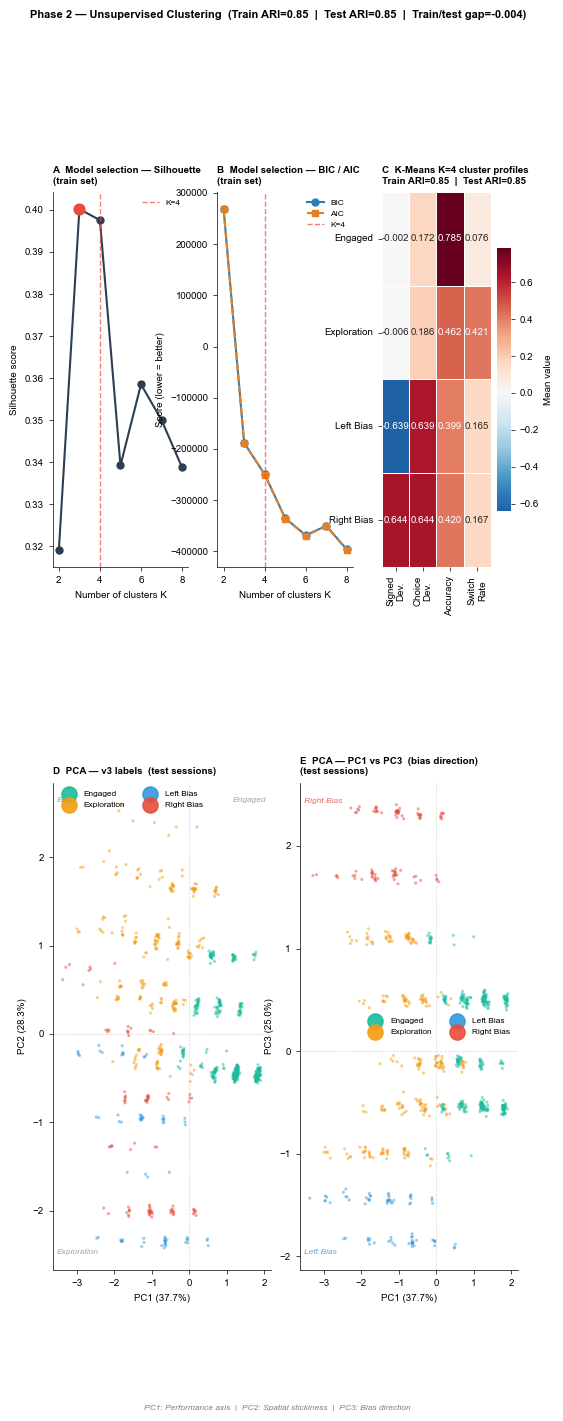


── Final Reported Numbers (TEST SET) ─────────────────────
  K-Means train ARI : 0.848
  K-Means test  ARI : 0.851
  Train/test gap    : -0.004
  Silhouette peak K : 3
  BIC minimum K     : 8


In [218]:
# CHUNK 2 — PHASE 2: UNSUPERVISED CLUSTERING (TRAIN/TEST SPLIT)
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
FEATURES_CLUST = [
    'Signed_Deviation',
    'Choice_Deviation',
    'Rolling_Accuracy',
    'Rolling_Switch_Rate',
]
TARGET_V3 = 'Behavioral_State_v3'
K_RANGE   = range(2, 9)
SEED      = 42

# ── 1. PREPARE TRAIN AND TEST ─────────────────────────────────────────────────
def prepare_clust_df(df, sessions, features, target):
    return (
        df
        .loc[df['Session_ID'].isin(sessions)]
        .loc[df[target] != 'Unknown']
        .dropna(subset=features + [target])
        .copy()
        .reset_index(drop=True)
    )

df_train_clust = prepare_clust_df(
    df_with_states, train_sessions, FEATURES_CLUST, TARGET_V3)
df_test_clust  = prepare_clust_df(
    df_with_states, test_sessions,  FEATURES_CLUST, TARGET_V3)

print(f"Train: {len(df_train_clust)} trials")
print(f"Test:  {len(df_test_clust)} trials")
print(f"\nTrain class distribution:")
print(df_train_clust[TARGET_V3].value_counts())
print(f"\nTest class distribution:")
print(df_test_clust[TARGET_V3].value_counts())

# ── 2. SCALE — fit on train only ──────────────────────────────────────────────
scaler_p2      = StandardScaler()
X_train_clust  = scaler_p2.fit_transform(df_train_clust[FEATURES_CLUST])
X_test_clust   = scaler_p2.transform(df_test_clust[FEATURES_CLUST])

# ── 3. MODEL SELECTION — on train only ───────────────────────────────────────
sil_train  = []
bic_train  = []
aic_train  = []

print("\nModel selection on TRAIN set...")
for k in K_RANGE:
    # K-Means silhouette on train
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kml = km.fit_predict(X_train_clust)
    sil_train.append(silhouette_score(
        X_train_clust, kml, sample_size=5000, random_state=SEED))

    # GMM BIC/AIC on train
    gmm = GaussianMixture(n_components=k, random_state=SEED,
                          n_init=5, covariance_type='full')
    gmm.fit(X_train_clust)
    bic_train.append(gmm.bic(X_train_clust))
    aic_train.append(gmm.aic(X_train_clust))

    print(f"  K={k} | Silhouette={sil_train[-1]:.3f} | "
          f"BIC={bic_train[-1]:.0f}")

best_k_sil = list(K_RANGE)[np.argmax(sil_train)]
best_k_bic = list(K_RANGE)[np.argmin(bic_train)]
print(f"\nSilhouette peak : K={best_k_sil}")
print(f"BIC minimum     : K={best_k_bic}")

# ── 4. FIT FINAL K-MEANS ON TRAIN ────────────────────────────────────────────
K_BEST    = 4
km4_train = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=20)
km4_train.fit(X_train_clust)

# ARI on train
km_train_labels  = km4_train.predict(X_train_clust)
mapping_train_km = hungarian_match(
    df_train_clust[TARGET_V3], km_train_labels, CLASSES_V3, K_BEST)
df_train_clust['KMeans_State'] = (
    pd.Series(km_train_labels).map(mapping_train_km).values)
ari_train = adjusted_rand_score(
    df_train_clust[TARGET_V3], df_train_clust['KMeans_State'])

# ARI on test — predict using train-fit model
km_test_labels  = km4_train.predict(X_test_clust)

# Use SAME mapping as train
df_test_clust['KMeans_State'] = (
    pd.Series(km_test_labels).map(mapping_train_km).values)
ari_test = adjusted_rand_score(
    df_test_clust[TARGET_V3], df_test_clust['KMeans_State'])

print(f"\n── ARI Results ───────────────────────────────────────────")
print(f"  Train ARI : {ari_train:.3f}")
print(f"  Test  ARI : {ari_test:.3f}")
print(f"  Gap       : {ari_train - ari_test:.3f}")

# Cluster profiles from train centroids
clust_profiles = pd.DataFrame(
    scaler_p2.inverse_transform(km4_train.cluster_centers_),
    columns=FEATURES_CLUST
)
# Map cluster indices to state names
clust_profiles.index = [mapping_train_km[i] for i in range(K_BEST)]
clust_profiles       = clust_profiles.reindex(CLASSES_V3)

print(f"\nK-Means K=4 cluster profiles (train centroids):")
print(clust_profiles.round(3))

# ── 5. PCA — fit on train, transform test for visualization ──────────────────
pca       = PCA(n_components=3, random_state=SEED)
X_pca_tr  = pca.fit_transform(X_train_clust)
X_pca_te  = pca.transform(X_test_clust)
explained = pca.explained_variance_ratio_

# Add PCs to test df for plotting
df_test_clust['PC1'] = X_pca_te[:, 0]
df_test_clust['PC2'] = X_pca_te[:, 1]
df_test_clust['PC3'] = X_pca_te[:, 2]

print(f"\nPCA explained variance:")
print(f"  PC1={explained[0]*100:.1f}%  "
      f"PC2={explained[1]*100:.1f}%  "
      f"PC3={explained[2]*100:.1f}%")

# Session-balanced subsample of TEST set for plotting
rng      = np.random.default_rng(SEED)
df_plot  = (
    df_test_clust
    .groupby('Session_ID', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 40), random_state=SEED))
    .reset_index(drop=True)
    .copy()
)
df_plot['PC1_j'] = df_plot['PC1'] + rng.normal(0, 0.03, len(df_plot))
df_plot['PC2_j'] = df_plot['PC2'] + rng.normal(0, 0.03, len(df_plot))
df_plot['PC3_j'] = df_plot['PC3'] + rng.normal(0, 0.03, len(df_plot))

print(f"\nPlot subsample: {len(df_plot)} trials from "
      f"{df_plot['Session_ID'].nunique()} test sessions")

# ── 6. PUBLICATION FIGURE ────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 14))
gs  = gridspec.GridSpec(
    2, 6,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.55,
    height_ratios = [1, 1.3],
)

# ── A: Silhouette ─────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0:2])

ax_A.plot(list(K_RANGE), sil_train, 'o-',
          color='#2c3e50', linewidth=1.5, markersize=5)
ax_A.axvline(K_BEST, color='#e74c3c', ls='--',
             lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_A.scatter(best_k_sil, max(sil_train),
             s=60, color='#e74c3c', zorder=5)
ax_A.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_A.set_ylabel('Silhouette score', fontsize=FONTSIZE)
ax_A.set_title('A  Model selection — Silhouette\n(train set)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE-1, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: BIC / AIC ─────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 2:4])

ax_B.plot(list(K_RANGE), bic_train, 'o-',
          color='#2980b9', linewidth=1.5, markersize=5, label='BIC')
ax_B.plot(list(K_RANGE), aic_train, 's--',
          color='#e67e22', linewidth=1.5, markersize=5, label='AIC')
ax_B.axvline(K_BEST, color='#e74c3c', ls='--',
             lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_B.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_B.set_ylabel('Score (lower = better)', fontsize=FONTSIZE)
ax_B.set_title('B  Model selection — BIC / AIC\n(train set)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE-1, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Cluster profiles heatmap ───────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 4:6])

feat_labels_short = ['Signed\nDev.', 'Choice\nDev.',
                     'Accuracy', 'Switch\nRate']
sns.heatmap(
    clust_profiles,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Mean value'},
    xticklabels=feat_labels_short,
    yticklabels=CLASSES_V3,
    ax=ax_C
)
ax_C.set_title(
    f'C  K-Means K={K_BEST} cluster profiles\n'
    f'Train ARI={ari_train:.2f}  |  Test ARI={ari_test:.2f}',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
ax_C.tick_params(axis='both', labelsize=FONTSIZE)
ax_C.set_yticklabels(ax_C.get_yticklabels(), rotation=0)

# ── D: PCA — v3 labels on TEST data ──────────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 0:3])

ax_D.scatter(
    df_plot['PC1_j'], df_plot['PC2_j'],
    c=df_plot[TARGET_V3].map(STATE_COLORS),
    s=5, alpha=0.5, linewidths=0
)
for state in CLASSES_V3:
    ax_D.scatter([], [], color=STATE_COLORS[state],
                 label=state, s=30, alpha=0.9)

ax_D.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)', fontsize=FONTSIZE)
ax_D.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)', fontsize=FONTSIZE)
ax_D.set_title('D  PCA — v3 labels  (test sessions)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.legend(fontsize=FONTSIZE-1, frameon=False,
            markerscale=2, ncol=2, loc='upper left')
ax_D.spines[['top', 'right']].set_visible(False)

# Corner annotations
ax_D.text(0.02, 0.97, 'Bias', transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE-1, style='italic',
          alpha=0.7, va='top', ha='left')
ax_D.text(0.98, 0.97, 'Engaged', transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE-1, style='italic',
          alpha=0.7, va='top', ha='right')
ax_D.text(0.02, 0.03, 'Exploration', transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE-1, style='italic',
          alpha=0.7, va='bottom', ha='left')

# ── E: PCA — PC1 vs PC3 bias direction ────────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 3:6])

ax_E.scatter(
    df_plot['PC1_j'], df_plot['PC3_j'],
    c=df_plot[TARGET_V3].map(STATE_COLORS),
    s=5, alpha=0.5, linewidths=0
)
for state in CLASSES_V3:
    ax_E.scatter([], [], color=STATE_COLORS[state],
                 label=state, s=30, alpha=0.9)

ax_E.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)', fontsize=FONTSIZE)
ax_E.set_ylabel(f'PC3 ({explained[2]*100:.1f}%)', fontsize=FONTSIZE)
ax_E.set_title('E  PCA — PC1 vs PC3  (bias direction)\n(test sessions)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_E.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_E.legend(fontsize=FONTSIZE-1, frameon=False,
            markerscale=2, ncol=2)
ax_E.spines[['top', 'right']].set_visible(False)

# Data-driven bias arm annotations
mean_pc3_left  = df_test_clust[
    df_test_clust[TARGET_V3]=='Left Bias']['PC3'].mean()
mean_pc3_right = df_test_clust[
    df_test_clust[TARGET_V3]=='Right Bias']['PC3'].mean()
top_state    = 'Left Bias'  if mean_pc3_left  > mean_pc3_right else 'Right Bias'
bottom_state = 'Right Bias' if mean_pc3_left  > mean_pc3_right else 'Left Bias'

ax_E.text(0.02, 0.97, top_state,
          transform=ax_E.transAxes,
          color=STATE_COLORS[top_state],
          fontsize=FONTSIZE-1, style='italic',
          va='top', ha='left', alpha=0.8)
ax_E.text(0.02, 0.03, bottom_state,
          transform=ax_E.transAxes,
          color=STATE_COLORS[bottom_state],
          fontsize=FONTSIZE-1, style='italic',
          va='bottom', ha='left', alpha=0.8)

# ── Shared figure text ────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
         f'PC1: Performance axis  |  '
         f'PC2: Spatial stickiness  |  '
         f'PC3: Bias direction',
         ha='center', fontsize=FONTSIZE-1,
         color='gray', style='italic')

fig.suptitle(
    f'Phase 2 — Unsupervised Clustering  '
    f'(Train ARI={ari_train:.2f}  |  Test ARI={ari_test:.2f}  |  '
    f'Train/test gap={ari_train-ari_test:.3f})',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.01
)

plt.savefig(f'{FIGURE_PATH}/phase2_unsupervised_clustering.svg',
            bbox_inches='tight')
plt.show()

print(f"\n── Final Reported Numbers (TEST SET) ─────────────────────")
print(f"  K-Means train ARI : {ari_train:.3f}")
print(f"  K-Means test  ARI : {ari_test:.3f}")
print(f"  Train/test gap    : {ari_train - ari_test:.3f}")
print(f"  Silhouette peak K : {best_k_sil}")
print(f"  BIC minimum K     : {best_k_bic}")

In [ ]:
#calculate win-stay, lose-switch 
def compute_win_stay_lose_switch_v2(sdf_state, df_full, min_trials=3):
    """
    Lower minimum trial threshold to 5 for sparse states.
    """
    df_full_sorted = df_full.sort_values(['Animal_Name', 'Session_ID', 'Trial'])
    
    df_full_sorted['prev_outcome'] = df_full_sorted.groupby(
        ['Animal_Name', 'Session_ID'])['Outcome_Binary'].shift(1)
    df_full_sorted['prev_choice'] = df_full_sorted.groupby(
        ['Animal_Name', 'Session_ID'])['Choice_Binary'].shift(1)
    
    sdf_merged = sdf_state.merge(
        df_full_sorted[['Animal_Name', 'Session_ID', 'Trial',
                        'prev_outcome', 'prev_choice']],
        on=['Animal_Name', 'Session_ID', 'Trial'],
        how='left'
    )
    
    repeat = (sdf_merged['Choice_Binary'] == sdf_merged['prev_choice']).astype(float)
    valid  = sdf_merged['prev_outcome'].notna() & sdf_merged['prev_choice'].notna()
    
    win_trials  = valid & (sdf_merged['prev_outcome'] == 1)
    lose_trials = valid & (sdf_merged['prev_outcome'] == 0)
    
    win_stay    = repeat[win_trials].mean() if win_trials.sum() >= min_trials else np.nan
    lose_switch = (1 - repeat[lose_trials]).mean() if lose_trials.sum() >= min_trials else np.nan
    
    return win_stay, lose_switch

def code_choice(row):
    choice = row['PhysicalChoice']
    if choice in ('BottomLeft', 'LeftCenter', 'TopLeft'):
        return 0
    elif choice in ('BottomRight', 'RightCenter', 'TopRight'):
        return 1
    else:
        return np.nan

# First pass — standard coding



In [224]:
FEATURES_CLUST

['Signed_Deviation',
 'Choice_Deviation',
 'Rolling_Accuracy',
 'Rolling_Switch_Rate']

Combined KMeans trials: 36473
KMeans_State
Engaged        17094
Exploration     9931
Left Bias       4784
Right Bias      4664
Name: count, dtype: int64

KMeans Win-Stay / Lose-Switch:
         state  win_stay  lose_switch  n_trials  \
0      Engaged     0.959        0.109     17094   
1  Exploration     0.769        0.567      9931   
2    Left Bias     0.905        0.261      4784   
3   Right Bias     0.913        0.263      4664   

                                    rolling_accuracy  \
0  Rolling_Accuracy    0.786062
Rolling_Accuracy ...   
1  Rolling_Accuracy    0.460798
Rolling_Accuracy ...   
2  Rolling_Accuracy    0.402728
Rolling_Accuracy ...   
3  Rolling_Accuracy    0.423017
Rolling_Accuracy ...   

                                      rolling_switch  n_animals  n_sessions  
0  Rolling_Switch_Rate    0.075605
Rolling_Switch...          5         100  
1  Rolling_Switch_Rate    0.420134
Rolling_Switch...          5         100  
2  Rolling_Switch_Rate    0.166127
Rolling_S

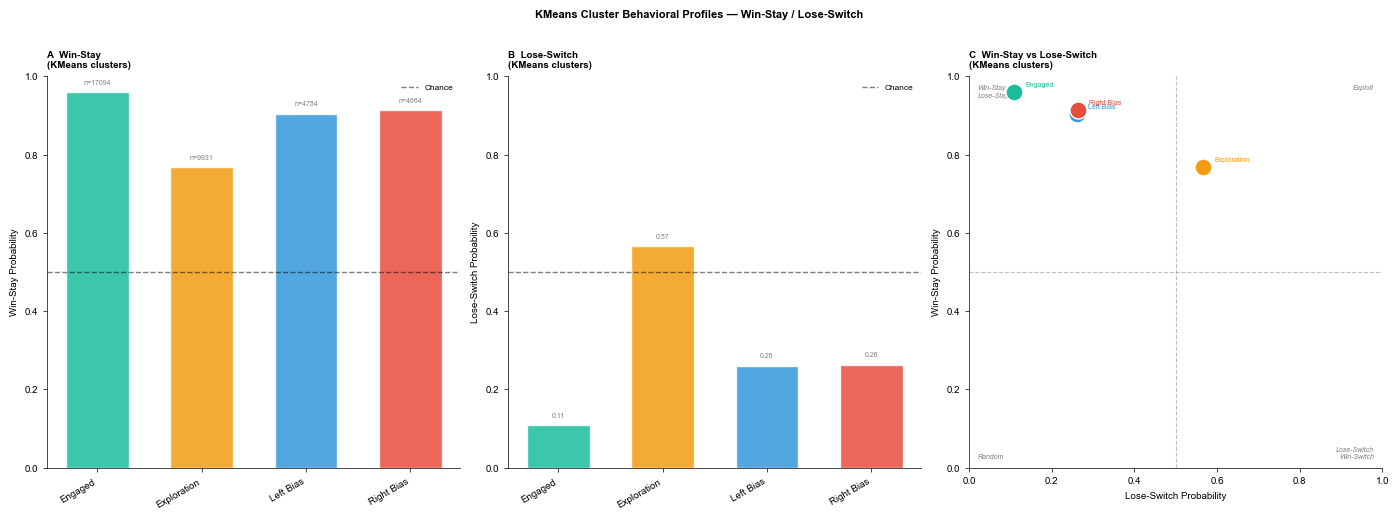

         state  win_stay  lose_switch  \
0      Engaged     0.959        0.109   
1  Exploration     0.769        0.567   
2    Left Bias     0.905        0.261   
3   Right Bias     0.913        0.263   

                                    rolling_accuracy  \
0  Rolling_Accuracy    0.786062
Rolling_Accuracy ...   
1  Rolling_Accuracy    0.460798
Rolling_Accuracy ...   
2  Rolling_Accuracy    0.402728
Rolling_Accuracy ...   
3  Rolling_Accuracy    0.423017
Rolling_Accuracy ...   

                                      rolling_switch  n_trials  
0  Rolling_Switch_Rate    0.075605
Rolling_Switch...     17094  
1  Rolling_Switch_Rate    0.420134
Rolling_Switch...      9931  
2  Rolling_Switch_Rate    0.166127
Rolling_Switch...      4784  
3  Rolling_Switch_Rate    0.167346
Rolling_Switch...      4664  


In [226]:
# ── COMBINE TRAIN + TEST KMEANS ASSIGNMENTS ───────────────────────────────────
df_kmeans_combined = pd.concat([
    df_train_clust[['Animal_Name', 'Session_ID', 'Trial', 'KMeans_State'] + FEATURES_CLUST + ['Choice_Binary'] + ['Outcome_Binary'] + ['PhysicalSwitch']+['PhysicalChoice']+['Rolling_Accuracy']+['Rolling_Switch_Rate']],
    df_test_clust[['Animal_Name', 'Session_ID', 'Trial', 'KMeans_State'] + FEATURES_CLUST + ['Choice_Binary'] + ['Outcome_Binary'] + ['PhysicalSwitch']+['PhysicalChoice']+['Rolling_Accuracy']+['Rolling_Switch_Rate']]
], ignore_index=True).drop_duplicates(subset=['Animal_Name', 'Session_ID', 'Trial'])

df_kmeans_combined['Choice_Binary'] = df_kmeans_combined.apply(code_choice, axis=1)

print(f"Combined KMeans trials: {len(df_kmeans_combined)}")
print(df_kmeans_combined['KMeans_State'].value_counts())

# ── CALCULATE WIN-STAY / LOSE-SWITCH PER CLUSTER ─────────────────────────────
records_kmeans = []
for state in sorted(df_kmeans_combined['KMeans_State'].unique()):
    if pd.isna(state):
        continue
    
    sdf = df_kmeans_combined[df_kmeans_combined['KMeans_State'] == state]
    
    if len(sdf) < 30:
        continue
    
    # Use existing function with full dataframe for prev trial context
    win_stay, lose_switch = compute_win_stay_lose_switch_v2(
        sdf, df_with_states, min_trials=3
    )
    
    records_kmeans.append({
        'state':             state,
        'win_stay':          win_stay,
        'lose_switch':       lose_switch,
        'n_trials':          len(sdf),
        'rolling_accuracy':  sdf['Rolling_Accuracy'].mean(),
        'rolling_switch':    sdf['Rolling_Switch_Rate'].mean(),
        'n_animals':         sdf['Animal_Name'].nunique(),
        'n_sessions':        sdf['Session_ID'].nunique(),
    })

results_kmeans = pd.DataFrame(records_kmeans).sort_values('state')
print("\nKMeans Win-Stay / Lose-Switch:")
print(results_kmeans.round(3))

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

states      = results_kmeans['state'].values
win_stays   = results_kmeans['win_stay'].values
lose_switch = results_kmeans['lose_switch'].values
x           = np.arange(len(states))
colors      = [STATE_COLORS.get(s, '#888888') for s in states]

# ── Panel A: Win-Stay per cluster ─────────────────────────────────────────────
axes[0].bar(x, win_stays, color=colors, alpha=0.85, edgecolor='white', width=0.6)
axes[0].axhline(0.5, color='black', ls='--', lw=1, alpha=0.5, label='Chance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(states, rotation=30, ha='right', fontsize=FONTSIZE)
axes[0].set_ylabel('Win-Stay Probability', fontsize=FONTSIZE)
axes[0].set_title('A  Win-Stay\n(KMeans clusters)',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=FONTSIZE-1, frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

# Add n_trials annotation
for i, (ws, n) in enumerate(zip(win_stays, results_kmeans['n_trials'])):
    axes[0].text(i, ws + 0.02, f'n={n}', ha='center',
                 fontsize=FONTSIZE-2, color='gray')

# ── Panel B: Lose-Switch per cluster ──────────────────────────────────────────
axes[1].bar(x, lose_switch, color=colors, alpha=0.85, edgecolor='white', width=0.6)
axes[1].axhline(0.5, color='black', ls='--', lw=1, alpha=0.5, label='Chance')
axes[1].set_xticks(x)
axes[1].set_xticklabels(states, rotation=30, ha='right', fontsize=FONTSIZE)
axes[1].set_ylabel('Lose-Switch Probability', fontsize=FONTSIZE)
axes[1].set_title('B  Lose-Switch\n(KMeans clusters)',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=FONTSIZE-1, frameon=False)
axes[1].spines[['top', 'right']].set_visible(False)

for i, ls_val in enumerate(lose_switch):
    axes[1].text(i, ls_val + 0.02, f'{ls_val:.2f}', ha='center',
                 fontsize=FONTSIZE-2, color='gray')

# ── Panel C: Win-Stay vs Lose-Switch scatter ───────────────────────────────────
for i, row in results_kmeans.iterrows():
    c = STATE_COLORS.get(row['state'], '#888888')
    axes[2].scatter(row['lose_switch'], row['win_stay'],
                    color=c, s=150, zorder=5,
                    edgecolors='white', linewidths=1)
    axes[2].annotate(
        row['state'],
        (row['lose_switch'], row['win_stay']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=FONTSIZE-2,
        color=c
    )

axes[2].axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[2].axvline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[2].set_xlabel('Lose-Switch Probability', fontsize=FONTSIZE)
axes[2].set_ylabel('Win-Stay Probability',    fontsize=FONTSIZE)
axes[2].set_title('C  Win-Stay vs Lose-Switch\n(KMeans clusters)',
                  fontsize=FONTSIZE, fontweight='bold', loc='left')
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].spines[['top', 'right']].set_visible(False)

# Quadrant labels
axes[2].text(0.02, 0.98, 'Win-Stay\nLose-Stay',
             transform=axes[2].transAxes, fontsize=FONTSIZE-2,
             color='gray', style='italic', va='top')
axes[2].text(0.98, 0.98, 'Exploit',
             transform=axes[2].transAxes, fontsize=FONTSIZE-2,
             color='gray', style='italic', va='top', ha='right')
axes[2].text(0.02, 0.02, 'Random',
             transform=axes[2].transAxes, fontsize=FONTSIZE-2,
             color='gray', style='italic', va='bottom')
axes[2].text(0.98, 0.02, 'Lose-Switch\nWin-Switch',
             transform=axes[2].transAxes, fontsize=FONTSIZE-2,
             color='gray', style='italic', va='bottom', ha='right')

plt.suptitle('KMeans Cluster Behavioral Profiles — Win-Stay / Lose-Switch',
             fontsize=FONTSIZE+1, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/kmeans_win_stay_lose_switch.svg', bbox_inches='tight')
plt.show()

print(results_kmeans[['state', 'win_stay', 'lose_switch',
                       'rolling_accuracy', 'rolling_switch', 'n_trials']].round(3))

Session points per KMeans cluster:
state
Exploration    99
Engaged        97
Name: count, dtype: int64


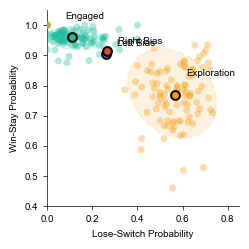

In [235]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson)
    ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx*2, height=ry*2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transform = (transforms.Affine2D()
                 .rotate_deg(45)
                 .scale(scale_x, scale_y)
                 .translate(mean_x, mean_y))
    ellipse.set_transform(transform + ax.transData)
    ax.add_patch(ellipse)

# ── COMPUTE OVERALL WIN-STAY / LOSE-SWITCH PER KMEANS CLUSTER ─────────────────
records_km = []
for state in sorted(df_kmeans_combined['KMeans_State'].unique()):
    if pd.isna(state):
        continue
    sdf = df_kmeans_combined[df_kmeans_combined['KMeans_State'] == state]
    if len(sdf) < 30:
        continue
    win_stay, lose_switch = compute_win_stay_lose_switch_v2(
        sdf, df_with_states, min_trials=3)
    records_km.append({
        'state':       state,
        'n_trials':    len(sdf),
        'win_stay':    win_stay,
        'lose_switch': lose_switch,
    })
results_km = pd.DataFrame(records_km)

# ── COMPUTE SESSION-LEVEL WIN-STAY / LOSE-SWITCH ──────────────────────────────
session_records_km = []
# for state in sorted(df_kmeans_combined['KMeans_State'].unique()):
for state in ['Engaged', 'Exploration']:
    if pd.isna(state):
        continue
    for session in df_kmeans_combined['Session_ID'].unique():
        sdf = df_kmeans_combined[
            (df_kmeans_combined['KMeans_State'] == state) &
            (df_kmeans_combined['Session_ID']   == session)
        ]
        if len(sdf) < 10:
            continue
        win_stay, lose_switch = compute_win_stay_lose_switch_v2(
            sdf, df_with_states, min_trials=3)
        animal = sdf['Animal_Name'].iloc[0]
        session_records_km.append({
            'state':       state,
            'session':     session,
            'animal':      animal,
            'win_stay':    win_stay,
            'lose_switch': lose_switch,
        })

session_df_km = pd.DataFrame(session_records_km).dropna(
    subset=['win_stay', 'lose_switch'])

print("Session points per KMeans cluster:")
print(session_df_km['state'].value_counts())

# ── PLOT ──────────────────────────────────────────────────────────────────────
offsets_km = {
    'Engaged':             (-5,  12),
    'Exploration':         ( 8,  12),
    # 'Left Bias':           ( 8, -14),
    # 'Right Bias':          (-15, -14),
    'Directed Exploration':( 8,  12),
    'Random Exploration':  ( 8, -14),
    'Exploit':             (-5,  12),
    'Perseveration':       (-15, -14),
}

fig, ax = plt.subplots(figsize=(2.5, 2.5))

# ── Confidence ellipses ───────────────────────────────────────────────────────
for state in session_df_km['state'].unique():
# for state in ['Exploit', 'Exploration']:
    sdf = session_df_km[session_df_km['state'] == state]
    if len(sdf) < 5:
        continue
    confidence_ellipse(
        sdf['lose_switch'].values,
        sdf['win_stay'].values,
        ax,
        n_std       = 1.5,
        facecolor   = STATE_COLORS.get(state, '#888888'),
        alpha       = 0.12,
        edgecolor   = STATE_COLORS.get(state, '#888888'),
        linewidth   = 1.5,
        linestyle   = '--',
        zorder      = 1,
    )

# ── Session-level scatter points ──────────────────────────────────────────────
for _, row in session_df_km.iterrows():
    ax.scatter(
        row['lose_switch'], row['win_stay'],
        s          = 25,
        color      = STATE_COLORS.get(row['state'], '#888888'),
        edgecolor  = 'none',
        alpha      = 0.35,
        zorder     = 3,
    )

# ── Group means ───────────────────────────────────────────────────────────────
for _, row in results_km.iterrows():
    state  = row['state']
    ox, oy = offsets_km.get(state, (8, 4))
    ax.scatter(
        row['lose_switch'], row['win_stay'],
        s          = 40,
        color      = STATE_COLORS.get(state, '#888888'),
        edgecolor  = 'black',
        linewidth  = 1.5,
        alpha      = 0.95,
        zorder     = 5,
    )
    ax.annotate(
        state,
        (row['lose_switch'], row['win_stay']),
        fontsize      = FONTSIZE,
        ha            = 'left',
        va            = 'bottom',
        xytext        = (ox, oy),
        textcoords    = 'offset points',
    )

ax.set_xlabel('Lose-Switch Probability', fontsize=FONTSIZE)
ax.set_ylabel('Win-Stay Probability',    fontsize=FONTSIZE)
ax.set_xlim(0, 0.85)
ax.set_ylim(0.4, 1.05)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=FONTSIZE)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_PATH, 'kmeans_winstay_loseswitch_ellipses.svg'),
    bbox_inches='tight'
)
plt.show()


States to plot: ['Left Bias', 'Right Bias']
Styles assigned:
  Left Bias: {'marker': 'o', 'linestyle': '-', 's': 40}
  Right Bias: {'marker': 's', 'linestyle': '--', 's': 40}

Already in session_df_km: ['Engaged', 'Exploration']
[Left Bias]  computing win-stay / lose-switch...
  n=99  NaN win_stay=12  NaN lose_switch=6  win_stay: 0.500–1.000  lose_switch: 0.000–0.800
[Right Bias]  computing win-stay / lose-switch...
  n=100  NaN win_stay=5  NaN lose_switch=1  win_stay: 0.333–1.000  lose_switch: 0.000–0.714

session_df_km_extended states: ['Engaged' 'Exploration' 'Left Bias' 'Right Bias']
[Left Bias]  n=99  NaN acc=0  acc: 0.000–0.733
[Right Bias]  n=100  NaN acc=0  acc: 0.178–0.733

Combined df: 199 rows  states: ['Left Bias' 'Right Bias']

Group means:
     state  win_stay  lose_switch
 Left Bias  0.863372     0.355046
Right Bias  0.877267     0.335272
[Left Bias]  norm  vmin=0.307  vmax=0.600
[Right Bias]  norm  vmin=0.312  vmax=0.603

Auto xlim: -0.12–0.92  ylim: 0.42–1.07


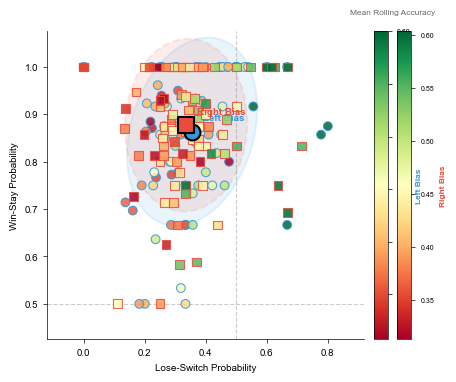

In [284]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SET STATES HERE — any subset of the four, in any order                    ║
# ║  ['Engaged', 'Exploration', 'Left Bias', 'Right Bias']                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
STATES_TO_PLOT = ['Left Bias', 'Right Bias']

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — CONSTANTS & STYLE POOLS
# ══════════════════════════════════════════════════════════════════════════════
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

CMAP       = 'RdYlGn'
MIN_TRIALS = 3

# fallback colours for any state not already in STATE_COLORS
_FALLBACK_COLORS = {
    'Engaged':     '#2ecc71',
    'Exploration': '#f39c12',
    'Left Bias':   '#3498db',
    'Right Bias':  '#e74c3c',
}
for _state, _col in _FALLBACK_COLORS.items():
    if _state not in STATE_COLORS:
        STATE_COLORS[_state] = _col
        print(f"  Added to STATE_COLORS: '{_state}' → {_col}")

# visual style pools — cycles if more than 4 states somehow
_MARKERS   = ['o', 's', '^', 'D']
_ELLIPSE_LS = ['-', '--', ':', '-.']

STATE_STYLES = {
    state: dict(
        marker     = _MARKERS[i % len(_MARKERS)],
        linestyle  = _ELLIPSE_LS[i % len(_ELLIPSE_LS)],
        s          = 40,
    )
    for i, state in enumerate(STATES_TO_PLOT)
}

print("\nStates to plot:", STATES_TO_PLOT)
print("Styles assigned:")
for s, v in STATE_STYLES.items():
    print(f"  {s}: {v}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — COMPUTE WIN-STAY / LOSE-SWITCH FOR ANY MISSING STATES
# ══════════════════════════════════════════════════════════════════════════════
already_computed = session_df_km['state'].unique().tolist()
print(f"\nAlready in session_df_km: {already_computed}")

new_frames = []

for state in STATES_TO_PLOT:
    if state in already_computed:
        print(f"[{state}]  already computed — skipping")
        continue

    print(f"[{state}]  computing win-stay / lose-switch...")

    sdf_state = df_with_states[df_with_states['Behavioral_State_v3'] == state]
    session_rows = []

    for session_id, sdf_session in sdf_state.groupby('Session_ID'):
        df_full_session = df_with_states[df_with_states['Session_ID'] == session_id]

        win_stay, lose_switch = compute_win_stay_lose_switch_v2(
            sdf_state  = sdf_session,
            df_full    = df_full_session,
            min_trials = MIN_TRIALS,
        )

        session_rows.append({
            'session':     session_id,
            'animal':      sdf_session['Animal_Name'].iloc[0],
            'state':       state,
            'win_stay':    win_stay,
            'lose_switch': lose_switch,
            'n_trials':    len(sdf_session),
        })

    frame = pd.DataFrame(session_rows)
    print(f"  n={len(frame)}  "
          f"NaN win_stay={frame['win_stay'].isna().sum()}  "
          f"NaN lose_switch={frame['lose_switch'].isna().sum()}  "
          f"win_stay: {frame['win_stay'].min():.3f}–{frame['win_stay'].max():.3f}  "
          f"lose_switch: {frame['lose_switch'].min():.3f}–{frame['lose_switch'].max():.3f}")
    new_frames.append(frame)

# extend session_df_km with any newly computed states
if new_frames:
    session_df_km_extended = pd.concat(
        [session_df_km] + new_frames, ignore_index=True
    )
else:
    session_df_km_extended = session_df_km.copy()

print(f"\nsession_df_km_extended states: {session_df_km_extended['state'].unique()}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — BUILD COMBINED DATAFRAME WITH ACCURACY
# ══════════════════════════════════════════════════════════════════════════════
combined_frames = []

for state in STATES_TO_PLOT:
    # per-session mean accuracy for this state
    state_acc = (
        df_with_states[df_with_states['Behavioral_State_v3'] == state]
        .groupby('Session_ID')['Rolling_Accuracy']
        .mean()
        .reset_index()
        .rename(columns={'Rolling_Accuracy': 'mean_accuracy',
                         'Session_ID':       'session'})
    )

    state_km = session_df_km_extended[
        session_df_km_extended['state'] == state
    ].copy()

    merged = state_km.merge(state_acc, on='session', how='left')
    merged['state'] = state
    combined_frames.append(merged)

    print(f"[{state}]  n={len(merged)}  "
          f"NaN acc={merged['mean_accuracy'].isna().sum()}  "
          f"acc: {merged['mean_accuracy'].min():.3f}"
          f"–{merged['mean_accuracy'].max():.3f}")

combined_df = pd.concat(combined_frames, ignore_index=True)
print(f"\nCombined df: {len(combined_df)} rows  "
      f"states: {combined_df['state'].unique()}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — GROUP MEANS FROM SESSION DATA (matches ellipse centre)
# ══════════════════════════════════════════════════════════════════════════════
group_means = (
    combined_df
    .dropna(subset=['win_stay', 'lose_switch'])
    .groupby('state')[['win_stay', 'lose_switch']]
    .mean()
    .reset_index()
)
print("\nGroup means:")
print(group_means.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — PER-STATE COLOUR NORMS
# ══════════════════════════════════════════════════════════════════════════════
state_norms = {}
for state in STATES_TO_PLOT:
    sdf  = combined_df[combined_df['state'] == state].dropna(subset=['mean_accuracy'])
    vmin = sdf['mean_accuracy'].quantile(0.05)
    vmax = sdf['mean_accuracy'].quantile(0.95)
    state_norms[state] = Normalize(vmin=vmin, vmax=vmax)
    print(f"[{state}]  norm  vmin={vmin:.3f}  vmax={vmax:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — AUTO AXIS LIMITS
# ══════════════════════════════════════════════════════════════════════════════
plot_df = combined_df.dropna(subset=['win_stay', 'lose_switch'])
x_pad   = (plot_df['lose_switch'].max() - plot_df['lose_switch'].min()) * 0.15
y_pad   = (plot_df['win_stay'].max()    - plot_df['win_stay'].min())    * 0.15
xlim    = (plot_df['lose_switch'].min() - x_pad, plot_df['lose_switch'].max() + x_pad)
ylim    = (plot_df['win_stay'].min()    - y_pad, plot_df['win_stay'].max()    + y_pad)
print(f"\nAuto xlim: {xlim[0]:.2f}–{xlim[1]:.2f}  "
      f"ylim: {ylim[0]:.2f}–{ylim[1]:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — FIGURE LAYOUT (dynamic: 1 colorbar per state)
# ══════════════════════════════════════════════════════════════════════════════
n_states     = len(STATES_TO_PLOT)
fig_width    = 3.5 + n_states * 0.6   # grows with number of colorbars

fig = plt.figure(figsize=(fig_width, 4))
gs  = gridspec.GridSpec(
    1, 1 + n_states,
    width_ratios = [10] + [0.45] * n_states,
    wspace       = 0.08,
)
ax   = fig.add_subplot(gs[0])
caxs = {state: fig.add_subplot(gs[i + 1])
        for i, state in enumerate(STATES_TO_PLOT)}

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — PLOT
# ══════════════════════════════════════════════════════════════════════════════
for state in STATES_TO_PLOT:
    sdf    = combined_df[combined_df['state'] == state].dropna(
                 subset=['win_stay', 'lose_switch'])
    color  = STATE_COLORS[state]
    norm   = state_norms[state]
    style  = STATE_STYLES[state]

    # confidence ellipse
    if len(sdf) > 2:
        confidence_ellipse(
            sdf['lose_switch'].values,
            sdf['win_stay'].values,
            ax,
            n_std      = 1.5,
            facecolor  = color,
            edgecolor  = color,
            linewidth  = 1.5,
            linestyle  = style['linestyle'],
            alpha      = 0.10,
            zorder     = 1,
        )
    else:
        print(f"  !! [{state}] only {len(sdf)} points — ellipse skipped")

    # scatter colored by accuracy
    ax.scatter(
        sdf['lose_switch'],
        sdf['win_stay'],
        c         = sdf['mean_accuracy'],
        cmap      = CMAP,
        norm      = norm,
        edgecolor = color,
        linewidth = 0.8,
        alpha     = 0.85,
        zorder    = 3,
        marker    = style['marker'],
        s         = style['s'],
    )

    # group mean
    grp = group_means[group_means['state'] == state].iloc[0]
    ax.scatter(
        grp['lose_switch'], grp['win_stay'],
        s         = 130,
        color     = color,
        edgecolor = 'black',
        linewidth = 1.5,
        zorder    = 6,
        marker    = style['marker'],
    )
    ax.annotate(
        state,
        (grp['lose_switch'], grp['win_stay']),
        fontsize   = FONTSIZE,
        xytext     = (8, 8),
        textcoords = 'offset points',
        color      = color,
        fontweight = 'bold',
    )

    # per-state colorbar
    sm = ScalarMappable(cmap=CMAP, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=caxs[state])
    cb.set_label(state, fontsize=FONTSIZE - 1,
                 color=color, fontweight='bold')
    cb.ax.tick_params(labelsize=FONTSIZE - 2)
    chance_pos = norm(0.5)
    if 0 < chance_pos < 1:
        cb.ax.axhline(chance_pos, color='black', lw=1, ls='--', alpha=0.7)

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — COSMETICS & SAVE
# ══════════════════════════════════════════════════════════════════════════════
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.axvline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Lose-Switch Probability', fontsize=FONTSIZE)
ax.set_ylabel('Win-Stay Probability',    fontsize=FONTSIZE)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=FONTSIZE)

# shared label centred above all colorbars
fig.canvas.draw()
cb_left  = caxs[STATES_TO_PLOT[0]].get_position().x0
cb_right = caxs[STATES_TO_PLOT[-1]].get_position().x1
cb_top   = caxs[STATES_TO_PLOT[0]].get_position().y1 + 0.04
fig.text(
    (cb_left + cb_right) / 2, cb_top,
    'Mean Rolling Accuracy',
    ha='center', va='bottom',
    fontsize=FONTSIZE - 1, color='dimgray',
)

# filename reflects which states were plotted
fname = '_'.join(s.replace(' ', '') for s in STATES_TO_PLOT)
plt.savefig(
    os.path.join(FIGURE_PATH, f'wsls_{fname}_accuracy.svg'),
    bbox_inches='tight'
)
plt.show()

In [280]:
# ── BUILD COMBINED_DF FOR BIAS STATES ─────────────────────────────────────────
states_to_plot = ['Left Bias', 'Right Bias']
combined_frames = []

for state in states_to_plot:
    state_acc = (
        df_with_states[df_with_states['Behavioral_State_v3'] == state]
        .groupby('Session_ID')['Rolling_Accuracy']
        .mean()
        .reset_index()
        .rename(columns={'Rolling_Accuracy': 'mean_accuracy',
                         'Session_ID':       'session'})
    )

    state_km = session_df_km_extended[
        session_df_km_extended['state'] == state
    ].copy()

    merged = state_km.merge(state_acc, on='session', how='left')
    merged['state'] = state
    combined_frames.append(merged)

    print(f"[{state}]  n={len(merged)}  "
          f"NaN acc={merged['mean_accuracy'].isna().sum()}  "
          f"acc: {merged['mean_accuracy'].min():.3f}–{merged['mean_accuracy'].max():.3f}")

combined_df = pd.concat(combined_frames, ignore_index=True)

[Left Bias]  n=99  NaN acc=0  acc: 0.000–0.733
[Right Bias]  n=100  NaN acc=0  acc: 0.178–0.733


        state  win_stay  lose_switch
0   Left Bias  0.849289     0.336220
1  Right Bias  0.875968     0.331673
        state  win_stay  lose_switch
0   Left Bias  0.849289     0.336220
1  Right Bias  0.875968     0.331673


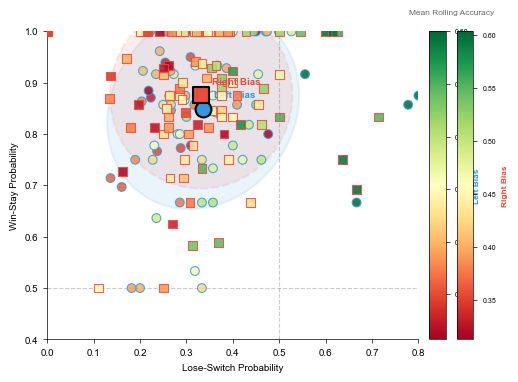

In [283]:
# ── PLOT with recomputed group means ─────────────────────────────────────────
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

CMAP = 'RdYlGn'

fallback_colors = {
    'Left Bias':  '#3498db',
    'Right Bias': '#e74c3c',
}
for state, col in fallback_colors.items():
    if state not in STATE_COLORS:
        STATE_COLORS[state] = col

state_norms = {}
for state in states_to_plot:
    sdf  = combined_df[combined_df['state'] == state].dropna(subset=['mean_accuracy'])
    state_norms[state] = Normalize(
        vmin=sdf['mean_accuracy'].quantile(0.05),
        vmax=sdf['mean_accuracy'].quantile(0.95),
    )

plot_df = combined_df.dropna(subset=['win_stay', 'lose_switch'])
x_pad   = (plot_df['lose_switch'].max() - plot_df['lose_switch'].min()) * 0.15
y_pad   = (plot_df['win_stay'].max()    - plot_df['win_stay'].min())    * 0.15
xlim    = (plot_df['lose_switch'].min() - x_pad, plot_df['lose_switch'].max() + x_pad)
ylim    = (plot_df['win_stay'].min()    - y_pad, plot_df['win_stay'].max()    + y_pad)

fig  = plt.figure(figsize=(5.5, 4))
gs   = gridspec.GridSpec(1, 3, width_ratios=[10, 0.45, 0.45], wspace=0.08)
ax   = fig.add_subplot(gs[0])
caxs = {state: fig.add_subplot(gs[i + 1])
        for i, state in enumerate(states_to_plot)}

ellipse_styles = {
    'Left Bias':  dict(linestyle='-',  alpha=0.10),
    'Right Bias': dict(linestyle='--', alpha=0.10),
}
marker_styles = {
    'Left Bias':  dict(marker='o', s=40),
    'Right Bias': dict(marker='s', s=40),
}

for state in states_to_plot:
    sdf   = combined_df[combined_df['state'] == state].dropna(
                subset=['win_stay', 'lose_switch'])
    color = STATE_COLORS[state]
    norm  = state_norms[state]
    # ── FIX: compute group means directly from session-level data ─────────────────
    # This guarantees the mean marker sits at the centre of the point cloud

    group_means = (
        combined_df
        .dropna(subset=['win_stay', 'lose_switch'])
        .groupby('state')[['win_stay', 'lose_switch']]
        .mean()
        .reset_index()
    )
    print(group_means)

    # ellipse
    if len(sdf) > 2:
        confidence_ellipse(
            sdf['lose_switch'].values,
            sdf['win_stay'].values,
            ax,
            n_std     = 1.5,
            facecolor = color,
            edgecolor = color,
            linewidth = 1.5,
            zorder    = 1,
            **ellipse_styles[state],
        )

    # scatter
    ax.scatter(
        sdf['lose_switch'],
        sdf['win_stay'],
        c         = sdf['mean_accuracy'],
        cmap      = CMAP,
        norm      = norm,
        edgecolor = color,
        linewidth = 0.8,
        alpha     = 0.85,
        zorder    = 3,
        **marker_styles[state],
    )

    # ── group mean from session data — guaranteed to match ellipse centre ──────
    grp = group_means[group_means['state'] == state].iloc[0]
    ax.scatter(
        grp['lose_switch'], grp['win_stay'],
        s         = 130,
        color     = color,
        edgecolor = 'black',
        linewidth = 1.5,
        zorder    = 6,
        marker    = marker_styles[state]['marker'],
    )
    ax.annotate(
        state,
        (grp['lose_switch'], grp['win_stay']),
        fontsize   = FONTSIZE,
        xytext     = (8, 8),
        textcoords = 'offset points',
        color      = color,
        fontweight = 'bold',
    )

    # colorbar
    sm = ScalarMappable(cmap=CMAP, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=caxs[state])
    cb.set_label(state, fontsize=FONTSIZE - 1,
                 color=color, fontweight='bold')
    cb.ax.tick_params(labelsize=FONTSIZE - 2)
    chance_pos = norm(0.5)
    if 0 < chance_pos < 1:
        cb.ax.axhline(chance_pos, color='black', lw=1, ls='--', alpha=0.7)

ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.axvline(0.5, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Lose-Switch Probability', fontsize=FONTSIZE)
ax.set_ylabel('Win-Stay Probability',    fontsize=FONTSIZE)
ax.set_xlim(0, 0.8)
ax.set_ylim(0.4, 1.0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=FONTSIZE)

fig.canvas.draw()
cb_left  = caxs[states_to_plot[0]].get_position().x0
cb_right = caxs[states_to_plot[1]].get_position().x1
cb_top   = caxs[states_to_plot[0]].get_position().y1 + 0.04
fig.text(
    (cb_left + cb_right) / 2, cb_top,
    'Mean Rolling Accuracy',
    ha='center', va='bottom',
    fontsize=FONTSIZE - 1, color='dimgray',
)

plt.savefig(
    os.path.join(FIGURE_PATH, 'bias_states_winstay_loseswitch_accuracy.svg'),
    bbox_inches='tight'
)
plt.show()

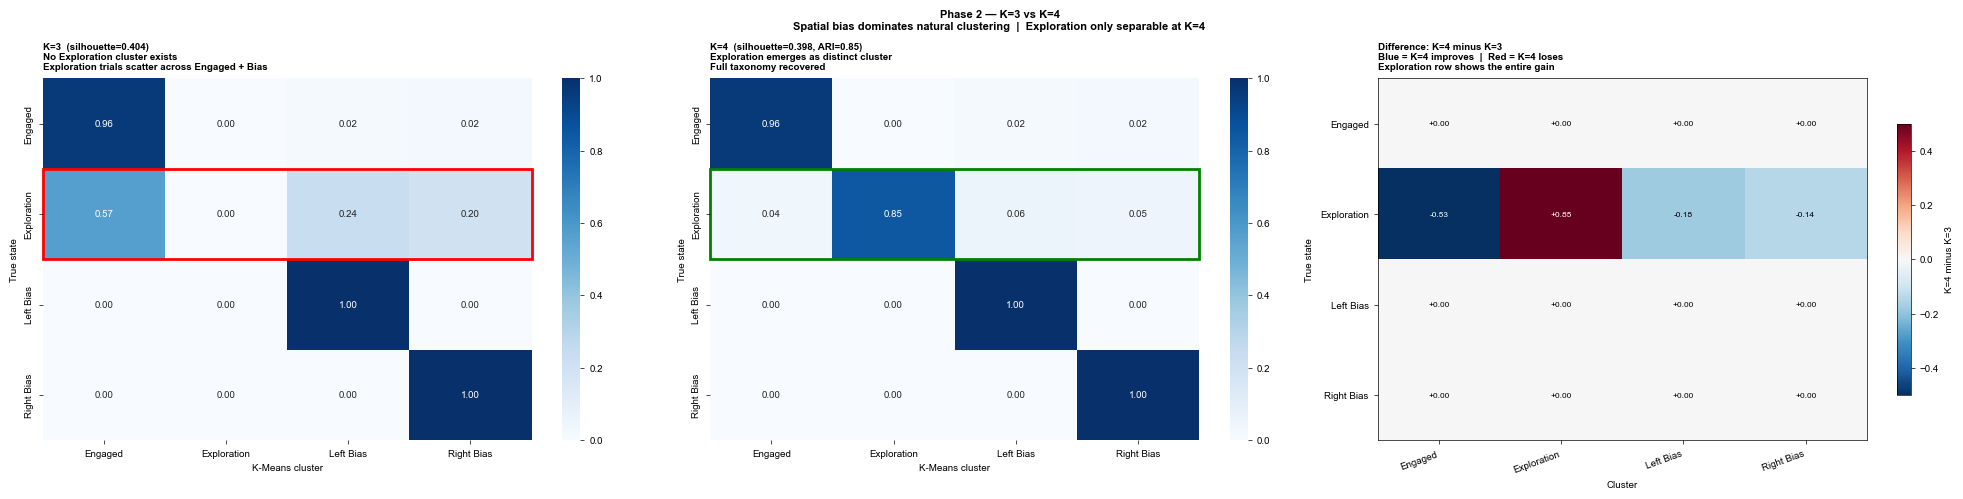

In [120]:
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(20, 5))

# ── K=3 ───────────────────────────────────────────────────────────────────────
sns.heatmap(cm_k3_4state, annot=True, fmt='.2f',
            xticklabels=CLASSES_V3,
            yticklabels=CLASSES_V3,
            cmap='Blues', ax=axes_cm[0])
axes_cm[0].set_title(
    'K=3  (silhouette=0.404)\n'
    'No Exploration cluster exists\n'
    'Exploration trials scatter across Engaged + Bias',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
axes_cm[0].set_xlabel('K-Means cluster', fontsize=FONTSIZE)
axes_cm[0].set_ylabel('True state', fontsize=FONTSIZE)

# Highlight the Exploration row — this is where the difference is
axes_cm[0].add_patch(plt.Rectangle(
    (0, 1), 4, 1,
    fill=False, edgecolor='red',
    lw=2, clip_on=False
))

# ── K=4 ───────────────────────────────────────────────────────────────────────
sns.heatmap(cm_k4, annot=True, fmt='.2f',
            xticklabels=CLASSES_V3,
            yticklabels=CLASSES_V3,
            cmap='Blues', ax=axes_cm[1])
axes_cm[1].set_title(
    f'K=4  (silhouette=0.398, ARI={ari_test:.2f})\n'
    'Exploration emerges as distinct cluster\n'
    'Full taxonomy recovered',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
axes_cm[1].set_xlabel('K-Means cluster', fontsize=FONTSIZE)
axes_cm[1].set_ylabel('True state', fontsize=FONTSIZE)

# Highlight the Exploration row
axes_cm[1].add_patch(plt.Rectangle(
    (0, 1), 4, 1,
    fill=False, edgecolor='green',
    lw=2, clip_on=False
))

# ── Difference panel — K=4 minus K=3 ─────────────────────────────────────────
diff = cm_k4 - cm_k3_4state
im = axes_cm[2].imshow(diff, cmap='RdBu_r',
                        vmin=-0.5, vmax=0.5, aspect='auto')
axes_cm[2].set_xticks(range(len(CLASSES_V3)))
axes_cm[2].set_yticks(range(len(CLASSES_V3)))
axes_cm[2].set_xticklabels(CLASSES_V3, fontsize=FONTSIZE,
                             rotation=20, ha='right')
axes_cm[2].set_yticklabels(CLASSES_V3, fontsize=FONTSIZE)

for i in range(len(CLASSES_V3)):
    for j in range(len(CLASSES_V3)):
        axes_cm[2].text(j, i, f'{diff[i,j]:+.2f}',
                         ha='center', va='center',
                         fontsize=FONTSIZE-1,
                         color='white' if abs(diff[i,j]) > 0.3
                         else 'black')

plt.colorbar(im, ax=axes_cm[2], shrink=0.75,
             label='K=4 minus K=3')
axes_cm[2].set_title(
    'Difference: K=4 minus K=3\n'
    'Blue = K=4 improves  |  Red = K=4 loses\n'
    'Exploration row shows the entire gain',
    fontsize=FONTSIZE, fontweight='bold', loc='left'
)
axes_cm[2].set_xlabel('Cluster', fontsize=FONTSIZE)
axes_cm[2].set_ylabel('True state', fontsize=FONTSIZE)

fig_cm.suptitle(
    'Phase 2 — K=3 vs K=4\n'
    'Spatial bias dominates natural clustering  |  '
    'Exploration only separable at K=4',
    fontsize=FONTSIZE+1, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/phase2_k3_vs_k4.svg', bbox_inches='tight')
plt.show()

In [116]:
# How many bias trials in train vs test?
print("Bias trials in train:")
print(df_train_clust[TARGET_V3].isin(
    ['Left Bias','Right Bias']).sum())
print("Bias trials in test:")
print(df_test_clust[TARGET_V3].isin(
    ['Left Bias','Right Bias']).sum())

# What does K=3 actually find?
km3_check = KMeans(n_clusters=3, random_state=SEED, n_init=20)
km3_check.fit(X_train_clust)
km3_labels = km3_check.predict(X_test_clust)

mapping_km3 = hungarian_match(
    df_test_clust[TARGET_V3],
    km3_labels,
    CLASSES_V3, 3
)
print(f"\nK=3 mapping: {mapping_km3}")

df_test_clust['KMeans_K3'] = pd.Series(km3_labels).map(mapping_km3).values

# What did K=3 do with the bias states?
print("\nK=3 assignment for bias trials:")
bias_test = df_test_clust[
    df_test_clust[TARGET_V3].isin(['Left Bias','Right Bias'])
]
print(bias_test['KMeans_K3'].value_counts())

# Silhouette at K=3 vs K=4
from sklearn.metrics import silhouette_score
for k, km in [(3, km3_check),
              (4, km4_train)]:
    labels = km.predict(X_test_clust)
    sil    = silhouette_score(X_test_clust, labels,
                               sample_size=5000,
                               random_state=SEED)
    print(f"K={k} silhouette on TEST: {sil:.3f}")

Bias trials in train:
5901
Bias trials in test:
1552

K=3 mapping: {0: 'Engaged', 1: 'Left Bias', 2: 'Right Bias'}

K=3 assignment for bias trials:
KMeans_K3
Right Bias    806
Left Bias     746
Name: count, dtype: int64
K=3 silhouette on TEST: 0.404
K=4 silhouette on TEST: 0.398


Clustering: 36473 trials, 4 features
Behavioral_State_v3
Engaged        17367
Exploration    11653
Left Bias       3736
Right Bias      3717
Name: count, dtype: int64

Fitting K range...
  K=2 | Silhouette=0.320 | BIC=-89139
  K=3 | Silhouette=0.392 | BIC=-240778
  K=4 | Silhouette=0.401 | BIC=-318369
  K=5 | Silhouette=0.337 | BIC=-429515
  K=6 | Silhouette=0.356 | BIC=-408870
  K=7 | Silhouette=0.332 | BIC=-489936
  K=8 | Silhouette=0.346 | BIC=-528165

Silhouette peak: K=4
BIC minimum    : K=8

K-Means K=4 ARI: 0.848

K-Means K=4 cluster profiles:
              Signed_Deviation  Choice_Deviation  Rolling_Accuracy  \
KMeans_State                                                         
Engaged                 -0.003             0.173             0.786   
Exploration             -0.009             0.188             0.461   
Left Bias               -0.639             0.639             0.403   
Right Bias               0.643             0.643             0.423   

              Rolling_

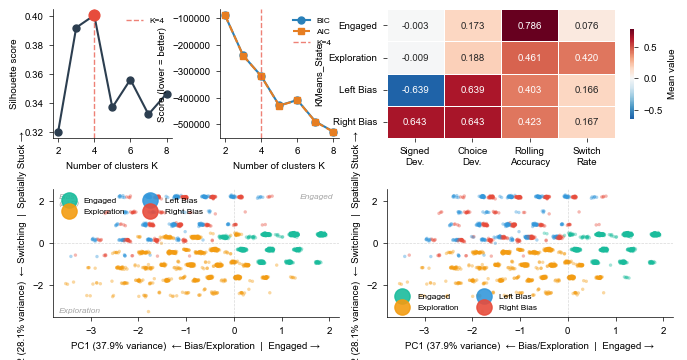

Phase 2 figure saved.


In [197]:
# CHUNK 2 — PHASE 2: UNSUPERVISED CLUSTERING
# Question: What structure does the data naturally contain?
# Key result: K=4 natural solution (silhouette peak), ARI=0.58 vs v3 labels
# ═══════════════════════════════════════════════════════════════════════════════

FEATURES_CLUST = [
    'Signed_Deviation',
    'Choice_Deviation',
    'Rolling_Accuracy',
    'Rolling_Switch_Rate',
]
K_RANGE = range(2, 9)

# ── 1.  Data preparation ──────────────────────────────────────────────────────
df_clust = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .dropna(subset=FEATURES_CLUST + [TARGET_V3])
    .copy()
    .reset_index(drop=True)
)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_clust[FEATURES_CLUST])

print(f"Clustering: {len(df_clust)} trials, {len(FEATURES_CLUST)} features")
print(df_clust[TARGET_V3].value_counts())

# ── 2.  Model selection ───────────────────────────────────────────────────────
sil_scores, bic_scores, aic_scores = [], [], []

print("\nFitting K range...")
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kml = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, kml,
                                       sample_size=5000, random_state=SEED))
    gmm = GaussianMixture(n_components=k, random_state=SEED,
                          n_init=5, covariance_type='full')
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    print(f"  K={k} | Silhouette={sil_scores[-1]:.3f} | BIC={bic_scores[-1]:.0f}")

best_k_sil = list(K_RANGE)[np.argmax(sil_scores)]
best_k_bic = list(K_RANGE)[np.argmin(bic_scores)]
print(f"\nSilhouette peak: K={best_k_sil}")
print(f"BIC minimum    : K={best_k_bic}")

# ── 3.  K-Means K=4 ──────────────────────────────────────────────────────────
K_BEST = 4
km4    = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=20)
km_labels = km4.fit_predict(X_scaled)
df_clust['KMeans_Cluster'] = km_labels

mapping_km4 = hungarian_match(df_clust[TARGET_V3], km_labels, CLASSES_V3, K_BEST)
df_clust['KMeans_State'] = df_clust['KMeans_Cluster'].map(mapping_km4)

ari_km4 = adjusted_rand_score(df_clust[TARGET_V3], df_clust['KMeans_State'])
print(f"\nK-Means K=4 ARI: {ari_km4:.3f}")

# Cluster profiles
clust_profiles = (
    df_clust.groupby('KMeans_State')[FEATURES_CLUST]
    .mean()
    .reindex(CLASSES_V3)
)
print("\nK-Means K=4 cluster profiles:")
print(clust_profiles.round(3))

# ── 4.  PCA for visualization ─────────────────────────────────────────────────
pca       = PCA(n_components=3, random_state=SEED)
X_pca     = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

df_clust['PC1'] = X_pca[:, 0]
df_clust['PC2'] = X_pca[:, 1]

print(f"\nPCA: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%")
print("PCA loadings:")
print(pd.DataFrame(pca.components_[:2].T,
                   index=FEATURES_CLUST,
                   columns=['PC1', 'PC2']).round(3))

# Jitter for visualization (discrete feature lattice)
rng = np.random.default_rng(SEED)
# Change frac=0.35 to a session-balanced subsample

N_PER_SESSION = 30
df_plot = (
    df_clust
    .groupby('Session_ID', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_PER_SESSION),
                               random_state=SEED))
    .reset_index(drop=True)
    .copy()
)
rng = np.random.default_rng(SEED)
df_plot['PC1_j'] = df_plot['PC1'] + rng.normal(0, 0.03, len(df_plot))
df_plot['PC2_j'] = df_plot['PC2'] + rng.normal(0, 0.03, len(df_plot))

# df_plot = df_clust.sample(frac=0.35, random_state=SEED).copy()
# df_plot['PC1_j'] = df_plot['PC1'] + rng.normal(0, 0.03, len(df_plot))
# df_plot['PC2_j'] = df_plot['PC2'] + rng.normal(0, 0.03, len(df_plot))

# ── 5.  Publication figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 4))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.4,
    wspace        = 0.4,
    # height_ratios = [1, 1.3],
)

# ── A: Silhouette ─────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.plot(list(K_RANGE), sil_scores, 'o-',
          color='#2c3e50', linewidth=1.5, markersize=5)
ax_A.axvline(K_BEST, color='#e74c3c', ls='--', lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_A.scatter(best_k_sil, max(sil_scores), s=60, color='#e74c3c', zorder=5)
ax_A.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_A.set_ylabel('Silhouette score', fontsize=FONTSIZE)
# ax_A.set_title('A  Model selection — Silhouette',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE - 1, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: BIC / AIC ─────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
ax_B.plot(list(K_RANGE), bic_scores, 'o-',
          color='#2980b9', linewidth=1.5, markersize=5, label='BIC')
ax_B.plot(list(K_RANGE), aic_scores, 's--',
          color='#e67e22', linewidth=1.5, markersize=5, label='AIC')
ax_B.axvline(K_BEST, color='#e74c3c', ls='--', lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_B.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_B.set_ylabel('Score (lower = better)', fontsize=FONTSIZE)
# ax_B.set_title('B  Model selection — BIC / AIC',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE - 1, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Cluster profiles heatmap ───────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2:4])

feat_labels_short = ['Signed\nDev.', 'Choice\nDev.',
                     'Rolling\nAccuracy', 'Switch\nRate']
sns.heatmap(
    clust_profiles,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Mean value'},
    xticklabels=feat_labels_short,
    yticklabels=CLASSES_V3,
    ax=ax_C
)
# ax_C.set_title(f'C  K-Means K={K_BEST} cluster profiles  (ARI = {ari_km4:.2f})',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.tick_params(axis='both', labelsize=FONTSIZE)
ax_C.set_yticklabels(ax_C.get_yticklabels(), rotation=0)

# ── D: PCA v3 labels ─────────────────────────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 0:2])

ax_D.scatter(
    df_plot['PC1_j'], df_plot['PC2_j'],
    c=df_plot[TARGET_V3].map(STATE_COLORS),
    s=6, alpha=0.4, linewidths=0
)
for state, color in STATE_COLORS.items():
    if state in CLASSES_V3:
        ax_D.scatter([], [], color=color, label=state, s=30, alpha=0.9)

ax_D.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)  '
                '← Bias/Exploration  |  Engaged →',
                fontsize=FONTSIZE)
ax_D.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)  '
                '← Switching  |  Spatially Stuck →',
                fontsize=FONTSIZE)
# ax_D.set_title('D  PCA — v3 classifier labels',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.legend(fontsize=FONTSIZE - 1, frameon=False,
            markerscale=2, ncol=2, loc='upper left')
ax_D.spines[['top', 'right']].set_visible(False)


# Remove old text lines and replace with:
ax_D.text(0.02, 0.97, 'Bias\n(L+R)',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='top', ha='left')
ax_D.text(0.98, 0.97, 'Engaged',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='top', ha='right')
ax_D.text(0.02, 0.03, 'Exploration',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='bottom', ha='left')
# Same for ax_E

# ── E: PCA K-Means labels ─────────────────────────────────────────────────────
ax_E = fig.add_subplot(gs[1, 2:4])

km_state_colors = {v: STATE_COLORS.get(v, '#bdc3c7') for v in mapping_km4.values()}
ax_E.scatter(
    df_plot['PC1_j'], df_plot['PC2_j'],
    c=df_plot['KMeans_State'].map(km_state_colors),
    s=6, alpha=0.4, linewidths=0
)
for state in CLASSES_V3:
    ax_E.scatter([], [], color=STATE_COLORS[state], label=state,
                 s=30, alpha=0.9)

ax_E.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)  '
                '← Bias/Exploration  |  Engaged →',
                fontsize=FONTSIZE)
ax_E.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)  '
                '← Switching  |  Spatially Stuck →',
                fontsize=FONTSIZE)
# ax_E.set_title(f'E  PCA — K-Means K={K_BEST} clusters  (ARI = {ari_km4:.2f})',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_E.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_E.legend(fontsize=FONTSIZE - 1, frameon=False, markerscale=2, ncol=2)
ax_E.spines[['top', 'right']].set_visible(False)

# fig.suptitle(
#     'Phase 2 — Unsupervised Clustering Recovers Four-State Behavioral Taxonomy',
#     fontsize=FONTSIZE + 1, fontweight='bold', y=1.01
# )

plt.savefig(f'{FIGURE_PATH}/phase2_unsupervised_clustering_small.svg',
            bbox_inches='tight')
plt.show()
print("Phase 2 figure saved.")

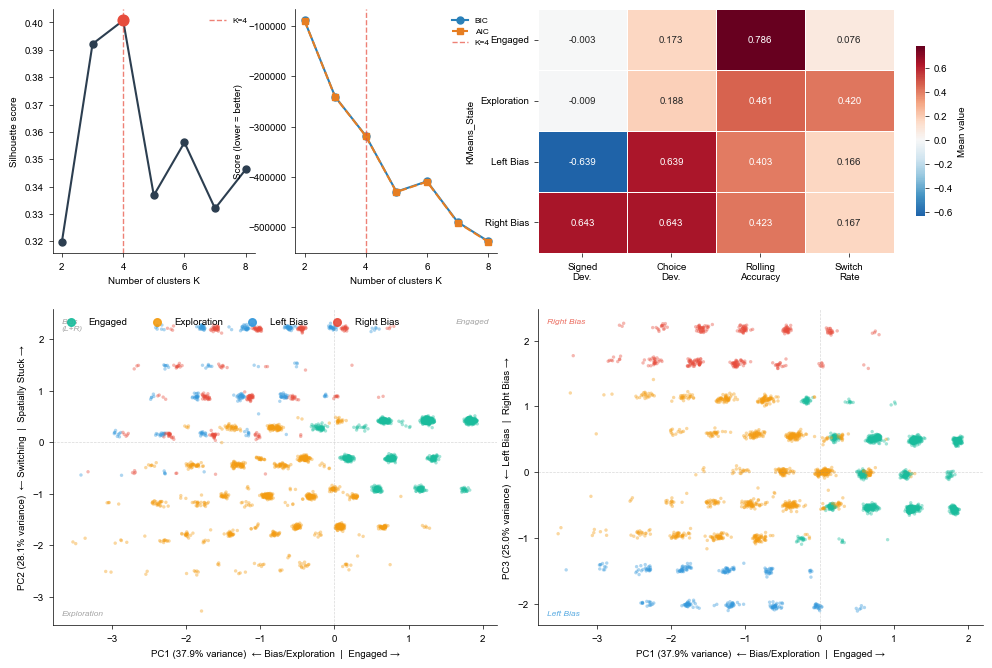

Phase 2 figure saved.


In [108]:
# ── 5.  Publication figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    # hspace        = 0.5,
    # wspace        = 0.5,
    height_ratios = [1, 1.3],
    # width_ratios  = [0.8, 0.8, 0.8, 0.8],
)

# ── A: Silhouette ─────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.plot(list(K_RANGE), sil_scores, 'o-',
          color='#2c3e50', linewidth=1.5, markersize=5)
ax_A.axvline(K_BEST, color='#e74c3c', ls='--', lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_A.scatter(best_k_sil, max(sil_scores), s=60, color='#e74c3c', zorder=5)
ax_A.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_A.set_ylabel('Silhouette score', fontsize=FONTSIZE)
# ax_A.set_title('A  Model selection — Silhouette',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE - 1, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: BIC / AIC ─────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
ax_B.plot(list(K_RANGE), bic_scores, 'o-',
          color='#2980b9', linewidth=1.5, markersize=5, label='BIC')
ax_B.plot(list(K_RANGE), aic_scores, 's--',
          color='#e67e22', linewidth=1.5, markersize=5, label='AIC')
ax_B.axvline(K_BEST, color='#e74c3c', ls='--', lw=1, alpha=0.7, label=f'K={K_BEST}')
ax_B.set_xlabel('Number of clusters K', fontsize=FONTSIZE)
ax_B.set_ylabel('Score (lower = better)', fontsize=FONTSIZE)
# ax_B.set_title('B  Model selection — BIC / AIC',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE - 1, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Cluster profiles heatmap ───────────────────────────────────────────────
ax_C = fig.add_subplot(gs[0, 2:4])

feat_labels_short = ['Signed\nDev.', 'Choice\nDev.',
                     'Rolling\nAccuracy', 'Switch\nRate']
sns.heatmap(
    clust_profiles,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Mean value'},
    xticklabels=feat_labels_short,
    yticklabels=CLASSES_V3,
    ax=ax_C
)
# ax_C.set_title(f'C  K-Means K={K_BEST} cluster profiles  (ARI = {ari_km4:.2f})',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.tick_params(axis='both', labelsize=FONTSIZE)
ax_C.set_yticklabels(ax_C.get_yticklabels(), rotation=0)

# ── D: PCA v3 labels ─────────────────────────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 0:2])

ax_D.scatter(
    df_plot['PC1_j'], df_plot['PC2_j'],
    c=df_plot[TARGET_V3].map(STATE_COLORS),
    s=6, alpha=0.4, linewidths=0
)
for state, color in STATE_COLORS.items():
    if state in CLASSES_V3:
        ax_D.scatter([], [], color=color, label=state, s=30, alpha=0.9)

ax_D.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)  '
                '← Bias/Exploration  |  Engaged →',
                fontsize=FONTSIZE)
ax_D.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)  '
                '← Switching  |  Spatially Stuck →',
                fontsize=FONTSIZE)
# ax_D.set_title('D  PCA — v3 classifier labels',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_D.legend(fontsize=FONTSIZE, frameon=False,
            markerscale=1, ncol=4, loc='upper left')
ax_D.spines[['top', 'right']].set_visible(False)


# Remove old text lines and replace with:
ax_D.text(0.02, 0.97, 'Bias\n(L+R)',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='top', ha='left')
ax_D.text(0.98, 0.97, 'Engaged',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='top', ha='right')
ax_D.text(0.02, 0.03, 'Exploration',
          transform=ax_D.transAxes,
          color='gray', fontsize=FONTSIZE - 1,
          style='italic', alpha=0.7,
          va='bottom', ha='left')
# Same for ax_E

# ── In CHUNK 2, after fitting PCA ─────────────────────────────────────────────
# Make sure you're extracting PC3
df_clust['PC3'] = X_pca[:, 2]

# Update the subsample
df_plot = (
    df_clust
    .groupby('Session_ID', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 30), random_state=SEED))
    .reset_index(drop=True)
    .copy()
)
rng = np.random.default_rng(SEED)
df_plot['PC1_j'] = df_plot['PC1'] + rng.normal(0, 0.03, len(df_plot))
df_plot['PC2_j'] = df_plot['PC2'] + rng.normal(0, 0.03, len(df_plot))
df_plot['PC3_j'] = df_plot['PC3'] + rng.normal(0, 0.03, len(df_plot))


# ── Panel E: PC1 vs PC3 — bias direction axis ────────────────────────────────
ax_E = fig.add_subplot(gs[1, 2:4])

ax_E.scatter(
    df_plot['PC1_j'], df_plot['PC3_j'],
    c=df_plot[TARGET_V3].map(STATE_COLORS),
    s=6, alpha=0.4, linewidths=0
)
for state in CLASSES_V3:
    ax_E.scatter([], [], color=STATE_COLORS[state],
                 label=state, s=30, alpha=0.9)

ax_E.set_xlabel(
    f'PC1 ({explained[0]*100:.1f}% variance)  '
    '← Bias/Exploration  |  Engaged →',
    fontsize=FONTSIZE
)
ax_E.set_ylabel(
    f'PC3 ({explained[2]*100:.1f}% variance)  '
    '← Left Bias  |  Right Bias →',
    fontsize=FONTSIZE
)
# ax_E.set_title(
#     f'E  PCA — PC1 vs PC3\n'
#     f'PC3 captures bias direction  '
#     f'({explained[2]*100:.1f}% variance)',
#     fontsize=FONTSIZE, fontweight='bold', loc='left'
# )
ax_E.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
ax_E.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.3)
# ax_E.legend(fontsize=FONTSIZE - 1, frameon=False,
#             markerscale=2, ncol=2)
ax_E.spines[['top', 'right']].set_visible(False)

# Let the data tell you which direction each bias sits
mean_pc3_left  = df_clust[df_clust[TARGET_V3]=='Left Bias' ]['PC3'].mean()
mean_pc3_right = df_clust[df_clust[TARGET_V3]=='Right Bias']['PC3'].mean()

# Place annotations based on actual means
top_state    = 'Left Bias'  if mean_pc3_left  > mean_pc3_right else 'Right Bias'
bottom_state = 'Right Bias' if mean_pc3_left  > mean_pc3_right else 'Left Bias'

ax_E.text(0.02, 0.97, top_state,
          transform=ax_E.transAxes,
          color=STATE_COLORS[top_state],
          fontsize=FONTSIZE - 1, style='italic',
          va='top', ha='left', alpha=0.8)

ax_E.text(0.02, 0.03, bottom_state,
          transform=ax_E.transAxes,
          color=STATE_COLORS[bottom_state],
          fontsize=FONTSIZE - 1, style='italic',
          va='bottom', ha='left', alpha=0.8)

plt.savefig(f'{FIGURE_PATH}/phase2_unsupervised_clustering.svg',
            bbox_inches='tight')
plt.show()
print("Phase 2 figure saved.")

AUC: 0.835
Threshold: 0.413
Sensitivity: 0.747
Specificity: 0.776


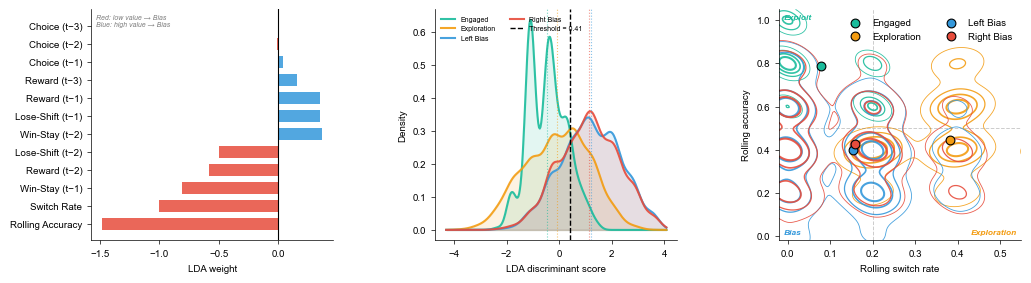

In [191]:
# ── Generate df_lda and df_plot_lda ──────────────────────────────────────────
FEATURES_LDA_INDEPENDENT = [
    'Rolling_Accuracy',
    'Rolling_Switch_Rate',
    'WinStay_Lag1',  'LoseShift_Lag1',
    'WinStay_Lag2',  'LoseShift_Lag2',
    'Reward_Lag1',   'Reward_Lag2',   'Reward_Lag3',
    'Choice_Lag1',   'Choice_Lag2',   'Choice_Lag3',
]

df_lda = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .dropna(subset=FEATURES_LDA_INDEPENDENT + [TARGET_V3])
    .copy()
)

df_lda['Is_Bias'] = df_lda[TARGET_V3].isin(
    ['Left Bias', 'Right Bias']
).astype(int)

# Fit LDA
scaler_lda = StandardScaler()
X_lda      = scaler_lda.fit_transform(df_lda[FEATURES_LDA_INDEPENDENT])

lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_lda, df_lda['Is_Bias'])
df_lda['LDA_Score'] = lda.transform(X_lda).ravel()

# ROC for threshold
fpr, tpr, thresholds = roc_curve(df_lda['Is_Bias'], df_lda['LDA_Score'])
youden_idx = np.argmax(tpr - fpr)
opt_thresh = thresholds[youden_idx]
auc        = roc_auc_score(df_lda['Is_Bias'], df_lda['LDA_Score'])

# Subsample for plotting
df_plot_lda = df_lda.sample(frac=0.3, random_state=SEED).copy()

# Feature weights
coef_df = pd.Series(
    lda.coef_[0],
    index=FEATURES_LDA_INDEPENDENT
).sort_values(key=abs, ascending=False)

FEATURE_LABELS_LDA = {
    'Rolling_Accuracy'   : 'Rolling Accuracy',
    'Rolling_Switch_Rate': 'Switch Rate',
    'WinStay_Lag1'       : 'Win-Stay (t−1)',
    'Reward_Lag2'        : 'Reward (t−2)',
    'LoseShift_Lag2'     : 'Lose-Shift (t−2)',
    'WinStay_Lag2'       : 'Win-Stay (t−2)',
    'LoseShift_Lag1'     : 'Lose-Shift (t−1)',
    'Reward_Lag1'        : 'Reward (t−1)',
    'Reward_Lag3'        : 'Reward (t−3)',
    'Choice_Lag1'        : 'Choice (t−1)',
    'Choice_Lag2'        : 'Choice (t−2)',
    'Choice_Lag3'        : 'Choice (t−3)',
}
coef_renamed = coef_df.rename(FEATURE_LABELS_LDA)

print(f"AUC: {auc:.3f}")
print(f"Threshold: {opt_thresh:.3f}")
print(f"Sensitivity: {tpr[youden_idx]:.3f}")
print(f"Specificity: {1-fpr[youden_idx]:.3f}")

# ── Then run the figure code ──────────────────────────────────────────────────
# ... (all the plotting code goes here)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 3))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42)

# ── A: LDA weights ────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0])

# Color by sign — negative = drives bias (red), positive = drives non-bias (blue)
colors_lda = ['#e74c3c' if c < 0 else '#3498db'
               for c in coef_renamed.values]

ax_A.barh(coef_renamed.index, coef_renamed.values,
          color=colors_lda, edgecolor='none',
          height=0.65, alpha=0.85)
ax_A.axvline(0, color='black', lw=0.8)

# Annotate the key insight
ax_A.text(0.02, 0.98,
          'Red: low value → Bias\nBlue: high value → Bias',
          transform=ax_A.transAxes,
          fontsize=FONTSIZE - 2, color='gray',
          va='top', ha='left', style='italic')

ax_A.set_xlabel('LDA weight', fontsize=FONTSIZE)
# ax_A.set_title('A  Discriminant axis\n(independent features only)',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Score distributions ────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])

from scipy.stats import gaussian_kde

x_range = np.linspace(df_lda['LDA_Score'].min() - 0.5,
                       df_lda['LDA_Score'].max() + 0.5, 300)

for state in CLASSES_V3:
    vals = df_lda[df_lda[TARGET_V3] == state]['LDA_Score'].values
    if len(vals) < 10:
        continue
    kde = gaussian_kde(vals, bw_method=0.25)
    ax_B.plot(x_range, kde(x_range),
              color=STATE_COLORS[state],
              linewidth=1.5, label=state, alpha=0.9)
    ax_B.fill_between(x_range, kde(x_range),
                       alpha=0.12, color=STATE_COLORS[state])

ax_B.axvline(opt_thresh, color='black', ls='--', lw=1,
             label=f'Threshold = {opt_thresh:.2f}')

# Annotate state means
for state in CLASSES_V3:
    m = df_lda[df_lda[TARGET_V3] == state]['LDA_Score'].mean()
    ax_B.axvline(m, color=STATE_COLORS[state],
                  ls=':', lw=0.8, alpha=0.6)

ax_B.set_xlabel('LDA discriminant score', fontsize=FONTSIZE)
ax_B.set_ylabel('Density', fontsize=FONTSIZE)
# ax_B.set_title(f'B  Score distributions by state\n'
#                f'AUC = {auc:.3f}  |  consistent with Phase 1 (73%)',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=2)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: 2D scatter — the key insight ──────────────────────────────────────────
# Plot the two most diagnostic features directly
# Low accuracy + low switching = Bias (unique corner)
ax_C = fig.add_subplot(gs[2])

df_plot_lda = df_lda.sample(frac=0.3, random_state=SEED)
# Replace scatter with 2D density for each state
from scipy.stats import gaussian_kde

ax_C.cla()
ax_C.set_facecolor('white')

for state in CLASSES_V3:
    sdf = df_plot_lda[df_plot_lda[TARGET_V3] == state]
    if len(sdf) < 20:
        continue

    x   = sdf['Rolling_Switch_Rate'].values
    y   = sdf['Rolling_Accuracy'].values
    xy  = np.vstack([x, y])
    kde = gaussian_kde(xy, bw_method=0.3)

    xi  = np.linspace(-0.02, 0.55, 150)
    yi  = np.linspace(-0.02, 1.05, 150)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi  = kde(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
    Zi  = Zi / Zi.max()   # normalise

    # Contour lines only
    ax_C.contour(Xi, Yi, Zi,
                 levels=[0.2, 0.4, 0.6, 0.8],
                 colors=[STATE_COLORS[state]],
                 linewidths=[0.6, 0.9, 1.2, 1.5],
                 alpha=0.9)

    # State mean dot
    ax_C.scatter(x.mean(), y.mean(),
                 color=STATE_COLORS[state],
                 s=40, zorder=6,
                 edgecolors='black', linewidths=0.8,
                 label=state)

# Reference lines at state boundaries
ax_C.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.4)
ax_C.axvline(0.2, color='gray', ls='--', lw=0.7, alpha=0.4)

# Corner annotations
ax_C.text(0.02, 0.98, 'Exploit',
          transform=ax_C.transAxes,
          color=STATE_COLORS['Engaged'],
          fontsize=FONTSIZE-1, va='top', ha='left',
          style='italic', fontweight='bold')
ax_C.text(0.98, 0.02, 'Exploration',
          transform=ax_C.transAxes,
          color=STATE_COLORS['Exploration'],
          fontsize=FONTSIZE-1, va='bottom', ha='right',
          style='italic', fontweight='bold')
ax_C.text(0.02, 0.02, 'Bias',
          transform=ax_C.transAxes,
          color=STATE_COLORS['Left Bias'],
          fontsize=FONTSIZE-1, va='bottom', ha='left',
          style='italic', fontweight='bold')

# ax_C.set_xlim(-0.02, 0.55)
# ax_C.set_ylim(-0.02, 1.05)
ax_C.set_xlabel('Rolling switch rate', fontsize=FONTSIZE)
ax_C.set_ylabel('Rolling accuracy',    fontsize=FONTSIZE)
# ax_C.set_title('C  Two most diagnostic features\n'
#                'Bias = unique low-acc + low-switch corner',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE, frameon=False,
            ncol=2, loc='upper right')
ax_C.spines[['top', 'right']].set_visible(False)

plt.savefig(f'{FIGURE_PATH}/lda_bias_separation.svg', bbox_inches='tight')
plt.show()


In [213]:
# plot the win-stay, lose-switch for each state
df_with_states.columns


Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       ...
       'chose_less_recent', 'Model_P_Right_ZeroQ', 'ZeroQ_Prediction',
       'Follows_ZeroQ', 'Signed_Deviation', 'Abs_Deviation', 'Chose_High_Prob',
       'Choice_Entropy', 'Behavioral_State_v3', 'States_Merged_v3'],
      dtype='object', length=172)

Train: 80 sessions
Test:  20 sessions

Train trials : 28382
Test  trials : 7591

Train class distribution:
States_Merged_v3
Engaged        13428
Exploration     9088
Bias            5866
Name: count, dtype: int64

Test class distribution:
States_Merged_v3
Engaged        3741
Exploration    2299
Bias           1551
Name: count, dtype: int64

Train session lengths — min=29, max=593, mean=354.8
Test  session lengths — min=164, max=506, mean=379.6

K-Means initialisation means (train):
             Abs_Deviation  Choice_Deviation  Rolling_Accuracy  \
Bias                 0.706             0.706             0.407   
Engaged              0.166             0.166             0.787   
Exploration          0.234             0.234             0.435   

             Rolling_Switch_Rate  
Bias                       0.156  
Engaged                    0.088  
Exploration                0.381  

Fitting HMM on train sessions...


Model is not converging.  Current: -75243.18149376506 is not greater than -75243.17421158304. Delta is -0.007282182021299377


  Restart 0 → LogLik=-75243.2  ✅  new best
  Restart 1 → LogLik=-30726.7  ✅  new best
  Restart 3 → LogLik=-29615.2  ✅  new best

Converged : True
Train LogLik: -29615.2

── ARI Results ───────────────────────────────────────────
  Train 3-state  : 0.492  ← expected to be higher
  Test  3-state  : 0.487  ← honest generalisation
  Test  4-state  : 0.474  ← with post-hoc direction
  K-Means (test) : report from Phase 2

── Transition Matrix ─────────────────────────────────────
              Bias  Engaged  Exploration
Bias         0.750    0.007        0.243
Engaged      0.066    0.837        0.097
Exploration  0.064    0.090        0.846

── Emission Means ────────────────────────────────────────
             Abs_Deviation  Choice_Deviation  Rolling_Accuracy  \
Bias                 0.707             0.707             0.407   
Engaged              0.200             0.200             0.809   
Exploration          0.189             0.189             0.555   

             Rolling_Switch_Ra

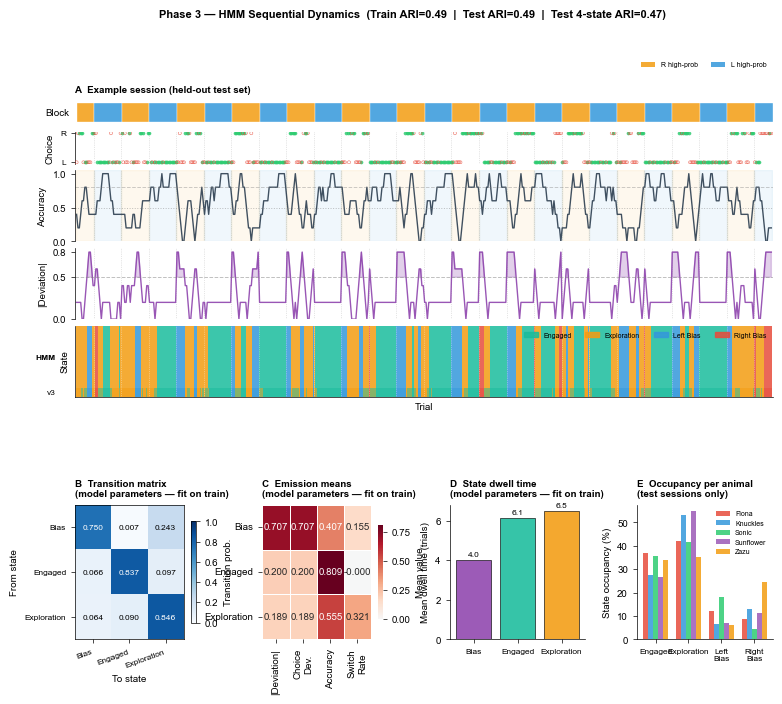


── Final Reported Numbers (TEST SET) ─────────────────────
  HMM 3-state ARI  : 0.487
  HMM 4-state ARI  : 0.474
  Train ARI        : 0.492
  Gap (train-test) : 0.006


In [192]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHUNK 3 — PHASE 3: HIDDEN MARKOV MODEL (TRAIN/TEST SPLIT)
# ═══════════════════════════════════════════════════════════════════════════════

from hmmlearn import hmm as hmmlearn
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
FEATURES_HMM    = ['Abs_Deviation', 'Choice_Deviation',
                   'Rolling_Accuracy', 'Rolling_Switch_Rate']
TARGET_3        = 'States_Merged_v3'   # Bias / Engaged / Exploration
TARGET_V3       = 'Behavioral_State_v3'  # 4-state
N_TRIALS_DROP   = 5
N_RESTARTS      = 10
SEED            = 42

# ── 1. SHARED SESSION-LEVEL TRAIN/TEST SPLIT ──────────────────────────────────
# Defined once here — same split used for all evaluation
sessions_all = df_with_states['Session_ID'].unique()
train_sessions, test_sessions = train_test_split(
    sessions_all, test_size=0.2, random_state=SEED
)

print(f"Train: {len(train_sessions)} sessions")
print(f"Test:  {len(test_sessions)} sessions")

# ── 2. PREPARE TRAIN AND TEST SETS ────────────────────────────────────────────
def prepare_hmm_df(df, sessions, features, target_3, target_v3,
                   n_drop=5):
    """Clean, sort, drop warmup trials for a given set of sessions."""
    out = (
        df
        .loc[df['Session_ID'].isin(sessions)]
        .loc[df[target_v3] != 'Unknown']
        .dropna(subset=features + [target_3, target_v3,
                                    'High_Prob_Is_Right'])
        .sort_values(['Session_ID', 'Trial'])
        .copy()
        .reset_index(drop=True)
    )
    out['_tis'] = out.groupby('Session_ID').cumcount()
    out = out[out['_tis'] >= n_drop].drop('_tis', axis=1)
    out = out.reset_index(drop=True)
    return out

df_hmm_train = prepare_hmm_df(df_with_states, train_sessions,
                               FEATURES_HMM, TARGET_3, TARGET_V3,
                               N_TRIALS_DROP)
df_hmm_test  = prepare_hmm_df(df_with_states, test_sessions,
                               FEATURES_HMM, TARGET_3, TARGET_V3,
                               N_TRIALS_DROP)

print(f"\nTrain trials : {len(df_hmm_train)}")
print(f"Test  trials : {len(df_hmm_test)}")
print(f"\nTrain class distribution:")
print(df_hmm_train[TARGET_3].value_counts())
print(f"\nTest class distribution:")
print(df_hmm_test[TARGET_3].value_counts())

# Session lengths — CRITICAL for boundary masking
train_lengths = df_hmm_train.groupby('Session_ID', sort=False).size().values
test_lengths  = df_hmm_test.groupby('Session_ID',  sort=False).size().values

print(f"\nTrain session lengths — "
      f"min={train_lengths.min()}, "
      f"max={train_lengths.max()}, "
      f"mean={train_lengths.mean():.1f}")
print(f"Test  session lengths — "
      f"min={test_lengths.min()}, "
      f"max={test_lengths.max()}, "
      f"mean={test_lengths.mean():.1f}")

# ── 3. SCALE — fit on train only ──────────────────────────────────────────────
scaler_hmm    = StandardScaler()
X_train_hmm   = scaler_hmm.fit_transform(df_hmm_train[FEATURES_HMM])
X_test_hmm    = scaler_hmm.transform(df_hmm_test[FEATURES_HMM])   # ← transform only

# Tiny jitter to avoid singular covariance
rng          = np.random.default_rng(SEED)
X_train_fit  = X_train_hmm + rng.normal(0, 0.01, X_train_hmm.shape)
X_test_fit   = X_test_hmm  + rng.normal(0, 0.01, X_test_hmm.shape)

# ── 4. K-MEANS INITIALISATION — on train only ─────────────────────────────────
CLASSES_3 = sorted(df_hmm_train[TARGET_3].unique())

km3_train = KMeans(n_clusters=3, random_state=SEED, n_init=20)
km3_train.fit(X_train_hmm)

mapping_km3 = hungarian_match(
    df_hmm_train[TARGET_3],
    km3_train.predict(X_train_hmm),
    CLASSES_3, 3
)
order_init   = [k for k, v in sorted(mapping_km3.items(),
                                      key=lambda x: CLASSES_3.index(x[1]))]
init_means   = km3_train.cluster_centers_[order_init]

print("\nK-Means initialisation means (train):")
print(pd.DataFrame(
    scaler_hmm.inverse_transform(init_means),
    index=CLASSES_3, columns=FEATURES_HMM
).round(3))

# ── 5. FIT HMM ON TRAIN ───────────────────────────────────────────────────────
best_model, best_ll = None, -np.inf

print("\nFitting HMM on train sessions...")
for restart in range(N_RESTARTS):
    try:
        model = hmmlearn.GaussianHMM(
            n_components    = 3,
            covariance_type = 'diag',
            n_iter          = 200,
            random_state    = SEED + restart,
            verbose         = False,
            init_params     = 'stc',
            params          = 'stmc',
        )
        model.means_ = init_means.copy()
        model.fit(X_train_fit, lengths=train_lengths)
        ll = model.score(X_train_fit, lengths=train_lengths)

        if ll > best_ll:
            best_ll, best_model = ll, model
            print(f"  Restart {restart} → LogLik={ll:.1f}  ✅  new best")

    except ValueError as e:
        print(f"  Restart {restart} → failed ({e})")

print(f"\nConverged : {best_model.monitor_.converged}")
print(f"Train LogLik: {best_ll:.1f}")

# ── 6. DECODE TRAIN AND TEST ──────────────────────────────────────────────────
# Train — for transition matrix and emission means
train_raw = best_model.predict(X_train_fit, lengths=train_lengths)
df_hmm_train['HMM_3_Raw'] = train_raw

mapping_train = hungarian_match(
    df_hmm_train[TARGET_3], train_raw, CLASSES_3, 3
)
df_hmm_train['HMM_3State'] = df_hmm_train['HMM_3_Raw'].map(mapping_train)

# Test — for all reported metrics
test_raw = best_model.predict(X_test_fit, lengths=test_lengths)
df_hmm_test['HMM_3_Raw'] = test_raw

# Use SAME mapping as train for consistency
df_hmm_test['HMM_3State'] = df_hmm_test['HMM_3_Raw'].map(mapping_train)

# Post-hoc Left/Right assignment — both train and test
for df_ in [df_hmm_train, df_hmm_test]:
    df_['HMM_4State'] = df_.apply(
        lambda r: (
            'Left Bias'  if r['HMM_3State'] == 'Bias'
                         and r['High_Prob_Is_Right'] == 1
            else 'Right Bias' if r['HMM_3State'] == 'Bias'
                              and r['High_Prob_Is_Right'] == 0
            else r['HMM_3State']
        ), axis=1
    )

# ── 7. EVALUATION — TEST SET ONLY ─────────────────────────────────────────────
ari_train_3 = adjusted_rand_score(df_hmm_train[TARGET_3],
                                   df_hmm_train['HMM_3State'])
ari_test_3  = adjusted_rand_score(df_hmm_test[TARGET_3],
                                   df_hmm_test['HMM_3State'])
ari_test_4  = adjusted_rand_score(df_hmm_test[TARGET_V3],
                                   df_hmm_test['HMM_4State'])

print(f"\n── ARI Results ───────────────────────────────────────────")
print(f"  Train 3-state  : {ari_train_3:.3f}  ← expected to be higher")
print(f"  Test  3-state  : {ari_test_3:.3f}  ← honest generalisation")
print(f"  Test  4-state  : {ari_test_4:.3f}  ← with post-hoc direction")
print(f"  K-Means (test) : report from Phase 2")

# ── 8. TRANSITION MATRIX + EMISSION MEANS ─────────────────────────────────────
# From fitted model — these are model parameters, not test metrics
# Report as model properties, not performance metrics
state_order  = [k for k, v in sorted(mapping_train.items(),
                                      key=lambda x: CLASSES_3.index(x[1]))]
trans_mat    = best_model.transmat_[np.ix_(state_order, state_order)]
stickiness   = np.diag(trans_mat)
mean_dwells  = [1 / max(1 - s, 1e-6) for s in stickiness]

means_orig   = scaler_hmm.inverse_transform(best_model.means_[state_order])
means_df     = pd.DataFrame(means_orig,
                              index=CLASSES_3, columns=FEATURES_HMM)

print(f"\n── Transition Matrix ─────────────────────────────────────")
print(pd.DataFrame(trans_mat,
                   index=CLASSES_3,
                   columns=CLASSES_3).round(3))

print(f"\n── Emission Means ────────────────────────────────────────")
print(means_df.round(3))

print(f"\n── State Stickiness ──────────────────────────────────────")
for i, s in enumerate(CLASSES_3):
    print(f"  {s:<15} self-transition={stickiness[i]:.3f}  "
          f"mean dwell={mean_dwells[i]:.1f} trials")

# ── 9. CONFUSION MATRIX ON TEST SET ───────────────────────────────────────────
cm_test = confusion_matrix(
    df_hmm_test[TARGET_3],
    df_hmm_test['HMM_3State'],
    labels=CLASSES_3, normalize='true'
)

print(f"\n── Confusion Matrix (TEST SET) ───────────────────────────")
print(pd.DataFrame(cm_test,
                   index=CLASSES_3,
                   columns=CLASSES_3).round(3))

# ── 10. PER-ANIMAL OCCUPANCY FROM TEST SET ────────────────────────────────────
hmm_occ_rows = []
for animal in animals_ordered:
    adf = df_hmm_test[df_hmm_test['Animal_Name'] == animal]
    if len(adf) == 0:
        continue
    tot = len(adf)
    for state in CLASSES_V3:
        hmm_occ_rows.append({
            'Animal'    : animal,
            'State'     : state,
            'Occupancy' : (adf['HMM_4State'] == state).sum() / tot * 100
        })
hmm_occ = pd.DataFrame(hmm_occ_rows)

# ── 11. EXAMPLE SESSION FROM TEST SET ─────────────────────────────────────────
# Always use test sessions for example — more honest
state_div_test = df_hmm_test.groupby('Session_ID')['HMM_4State'].nunique()
len_sess_test  = df_hmm_test.groupby('Session_ID').size()
cand_test      = state_div_test[state_div_test == 4].index
EXAMPLE        = len_sess_test.loc[cand_test].sort_values(
    ascending=False).index[0]
df_ex          = df_hmm_test[
    df_hmm_test['Session_ID'] == EXAMPLE
].reset_index(drop=True)
df_ex['t']     = np.arange(len(df_ex))

print(f"\nExample session (TEST): {EXAMPLE} ({len(df_ex)} trials)")
print(df_ex['HMM_4State'].value_counts())

# ── 12. PUBLICATION FIGURE ────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.38,
    height_ratios = [2.2, 1],
)

# ── Panel A: Example session ──────────────────────────────────────────────────
gs_A = gridspec.GridSpecFromSubplotSpec(
    5, 1,
    subplot_spec  = gs[0, :],
    hspace        = 0.12,
    height_ratios = [0.35, 0.45, 1, 1, 1],
)
ax_A1 = fig.add_subplot(gs_A[0])
ax_A2 = fig.add_subplot(gs_A[1], sharex=ax_A1)
ax_A3 = fig.add_subplot(gs_A[2], sharex=ax_A1)
ax_A4 = fig.add_subplot(gs_A[3], sharex=ax_A1)
ax_A5 = fig.add_subplot(gs_A[4], sharex=ax_A1)

HR_COL = '#f39c12'
HL_COL = '#3498db'
block_starts = df_ex.groupby('BlockCount')['t'].min()

# A1: block structure
for _, bdf in df_ex.groupby('BlockCount'):
    s, e  = bdf['t'].min(), bdf['t'].max()
    color = HR_COL if bdf['High_Prob_Is_Right'].iloc[0] else HL_COL
    ax_A1.barh(0, e-s+1, left=s, height=0.6,
               color=color, edgecolor='white',
               linewidth=0.3, alpha=0.85)
ax_A1.set_xlim(-1, len(df_ex))
ax_A1.set_ylim(-0.4, 0.4)
ax_A1.set_yticks([])
ax_A1.set_xticks([])
ax_A1.spines[['top','right','bottom','left']].set_visible(False)
ax_A1.set_ylabel('Block', fontsize=FONTSIZE,
                  rotation=0, ha='right', va='center')
ax_A1.legend(
    handles=[mpatches.Patch(facecolor=HR_COL, label='R high-prob', alpha=0.85),
             mpatches.Patch(facecolor=HL_COL, label='L high-prob', alpha=0.85)],
    fontsize=FONTSIZE-2, frameon=False,
    loc='upper right', bbox_to_anchor=(1.0, 2.8), ncol=2
)
ax_A1.set_title('A  Example session (held-out test set)',
                fontsize=FONTSIZE, fontweight='bold', loc='left')

# A2: choices
rewarded   = df_ex[df_ex['Outcome_Binary'] == 1]
unrewarded = df_ex[df_ex['Outcome_Binary'] == 0]
for trials, fc, ec in [
    (rewarded[rewarded['Choice_Binary']==1],   '#2ecc71', '#2ecc71'),
    (rewarded[rewarded['Choice_Binary']==0],   '#2ecc71', '#2ecc71'),
    (unrewarded[unrewarded['Choice_Binary']==1],'none',   '#e74c3c'),
    (unrewarded[unrewarded['Choice_Binary']==0],'none',   '#e74c3c'),
]:
    ax_A2.scatter(trials['t'], trials['Choice_Binary'],
                  s=5, facecolors=fc, edgecolors=ec,
                  linewidth=0.4, alpha=0.8, zorder=3)
for _, st in block_starts.items():
    if st > 0:
        ax_A2.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A2.set_yticks([0, 1])
ax_A2.set_yticklabels(['L', 'R'], fontsize=FONTSIZE-1)
ax_A2.set_ylabel('Choice', fontsize=FONTSIZE)
ax_A2.spines[['top','bottom','right']].set_visible(False)
ax_A2.tick_params(axis='x', labelbottom=False, length=0)

# A3: rolling accuracy
for _, bdf in df_ex.groupby('BlockCount'):
    s, e  = bdf['t'].min(), bdf['t'].max()
    color = HR_COL if bdf['High_Prob_Is_Right'].iloc[0] else HL_COL
    ax_A3.axvspan(s-0.5, e+0.5, alpha=0.07, color=color)
for _, st in block_starts.items():
    if st > 0:
        ax_A3.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A3.plot(df_ex['t'], df_ex['Rolling_Accuracy'],
           color='#2c3e50', linewidth=1.0, alpha=0.9)
ax_A3.axhline(0.5, color='gray', ls=':', lw=0.7, alpha=0.5)
ax_A3.axhline(0.8, color='gray', ls='--', lw=0.7, alpha=0.4)
ax_A3.set_ylim(0, 1.05)
ax_A3.set_yticks([0, 0.5, 1.0])
ax_A3.set_ylabel('Accuracy', fontsize=FONTSIZE)
ax_A3.spines[['top','bottom','right']].set_visible(False)
ax_A3.tick_params(axis='x', labelbottom=False, length=0)

# A4: abs deviation
for _, st in block_starts.items():
    if st > 0:
        ax_A4.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A4.plot(df_ex['t'], df_ex['Abs_Deviation'],
           color=STATE_COLORS['Bias'], linewidth=1.0, alpha=0.9)
ax_A4.fill_between(df_ex['t'], 0.5, df_ex['Abs_Deviation'],
                    where=df_ex['Abs_Deviation'] >= 0.5,
                    color=STATE_COLORS['Bias'], alpha=0.25)
ax_A4.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
ax_A4.set_ylim(0, 0.85)
ax_A4.set_yticks([0, 0.5, 0.8])
ax_A4.set_ylabel('|Deviation|', fontsize=FONTSIZE)
ax_A4.spines[['top','bottom','right']].set_visible(False)
ax_A4.tick_params(axis='x', labelbottom=False, length=0)

# A5: HMM state sequence + v3 reference
for idx, row in df_ex.iterrows():
    ax_A5.axvspan(idx-0.5, idx+0.5,
                  color=STATE_COLORS.get(row['HMM_4State'], 'grey'),
                  alpha=0.85, linewidth=0)
for idx, row in df_ex.iterrows():
    ax_A5.axvspan(idx-0.5, idx+0.5,
                  ymin=0, ymax=0.12,
                  color=STATE_COLORS.get(row[TARGET_V3], 'grey'),
                  alpha=0.5, linewidth=0)
for _, st in block_starts.items():
    if st > 0:
        ax_A5.axvline(st-0.5, color='white', ls=':', lw=0.5, alpha=0.6)

state_handles = [mpatches.Patch(color=STATE_COLORS[s], label=s, alpha=0.85)
                 for s in CLASSES_V3]
ax_A5.legend(handles=state_handles, fontsize=FONTSIZE-2,
              frameon=False, ncol=4, loc='upper right')
ax_A5.set_yticks([])
ax_A5.text(-15, 0.06, 'v3',  fontsize=FONTSIZE-1, ha='right', va='center')
ax_A5.text(-15, 0.56, 'HMM', fontsize=FONTSIZE-1, ha='right',
           va='center', fontweight='bold')
ax_A5.set_ylabel('State', fontsize=FONTSIZE)
ax_A5.set_xlabel('Trial', fontsize=FONTSIZE)
ax_A5.spines[['top','right']].set_visible(False)

# ── Panel B: Transition matrix ────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1, 0])

im_t = ax_B.imshow(trans_mat, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax_B.set_xticks(range(3))
ax_B.set_yticks(range(3))
ax_B.set_xticklabels(CLASSES_3, fontsize=FONTSIZE-1, rotation=20, ha='right')
ax_B.set_yticklabels(CLASSES_3, fontsize=FONTSIZE-1)
ax_B.set_xlabel('To state', fontsize=FONTSIZE)
ax_B.set_ylabel('From state', fontsize=FONTSIZE)
for i in range(3):
    for j in range(3):
        ax_B.text(j, i, f'{trans_mat[i,j]:.3f}',
                  ha='center', va='center', fontsize=FONTSIZE-1,
                  color='white' if trans_mat[i,j] > 0.55 else 'black')
plt.colorbar(im_t, ax=ax_B, shrink=0.75, label='Transition prob.')
ax_B.set_title(f'B  Transition matrix\n'
               f'(model parameters — fit on train)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')

# ── Panel C: Emission means ───────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 1])

feat_labels_hmm = ['|Deviation|', 'Choice\nDev.', 'Accuracy', 'Switch\nRate']
sns.heatmap(
    means_df,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Mean value'},
    xticklabels=feat_labels_hmm,
    yticklabels=CLASSES_3,
    ax=ax_C
)
ax_C.set_title('C  Emission means\n(model parameters — fit on train)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.tick_params(axis='both', labelsize=FONTSIZE)
ax_C.set_yticklabels(ax_C.get_yticklabels(), rotation=0)

# ── Panel D: Dwell times ──────────────────────────────────────────────────────
ax_D = fig.add_subplot(gs[1, 2])

ax_D.bar(range(3), mean_dwells,
         color=[STATE_COLORS[s] for s in CLASSES_3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88)
ax_D.set_xticks(range(3))
ax_D.set_xticklabels(CLASSES_3, fontsize=FONTSIZE-1)
ax_D.set_ylabel('Mean dwell time (trials)', fontsize=FONTSIZE)
ax_D.set_title('D  State dwell time\n(model parameters — fit on train)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
for i, (s, d) in enumerate(zip(CLASSES_3, mean_dwells)):
    ax_D.text(i, d+0.2, f'{d:.1f}', ha='center',
              fontsize=FONTSIZE-1, color='black')
ax_D.spines[['top','right']].set_visible(False)

# ── Panel E: Occupancy per animal — TEST SET ──────────────────────────────────
ax_E = fig.add_subplot(gs[1, 3])

x_occ   = np.arange(len(CLASSES_V3))
width_g = 0.15
offsets = np.linspace(-(len(animals_ordered)-1)*width_g/2,
                       (len(animals_ordered)-1)*width_g/2,
                       len(animals_ordered))

for k, animal in enumerate(animals_ordered):
    adf_o = hmm_occ[hmm_occ['Animal'] == animal]
    vals  = [adf_o[adf_o['State']==s]['Occupancy'].values[0]
             if len(adf_o[adf_o['State']==s]) else 0
             for s in CLASSES_V3]
    ax_E.bar(x_occ + offsets[k], vals, width_g,
             color=ANIMAL_COLORS[animal],
             edgecolor='none', alpha=0.85, label=animal)

ax_E.set_xticks(x_occ)
ax_E.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE-1)
ax_E.set_ylabel('State occupancy (%)', fontsize=FONTSIZE)
ax_E.set_title('E  Occupancy per animal\n(test sessions only)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_E.legend(fontsize=FONTSIZE-2, frameon=False, ncol=1,
             loc='upper right')
ax_E.spines[['top','right']].set_visible(False)

# ── Summary title ─────────────────────────────────────────────────────────────
fig.suptitle(
    f'Phase 3 — HMM Sequential Dynamics  '
    f'(Train ARI={ari_train_3:.2f}  |  '
    f'Test ARI={ari_test_3:.2f}  |  '
    f'Test 4-state ARI={ari_test_4:.2f})',
    fontsize=FONTSIZE+1, fontweight='bold', y=1.01
)

plt.savefig(f'{FIGURE_PATH}/phase3_hmm.svg', bbox_inches='tight')
plt.show()

print(f"\n── Final Reported Numbers (TEST SET) ─────────────────────")
print(f"  HMM 3-state ARI  : {ari_test_3:.3f}")
print(f"  HMM 4-state ARI  : {ari_test_4:.3f}")
print(f"  Train ARI        : {ari_train_3:.3f}")
print(f"  Gap (train-test) : {ari_train_3 - ari_test_3:.3f}")

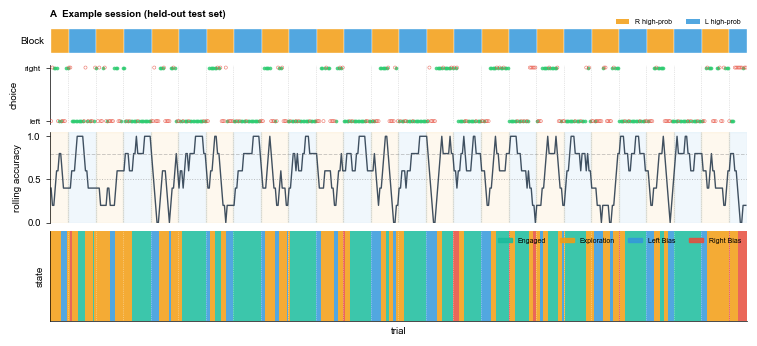

In [210]:
# ── 12. PUBLICATION FIGURE ────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7))
gs  = gridspec.GridSpec(
    2, 4,
    figure        = fig,
    hspace        = 0.50,
    wspace        = 0.38,
    height_ratios = [2.2, 1],
)

# ── Panel A: Example session ──────────────────────────────────────────────────
gs_A = gridspec.GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec  = gs[0, :],
    hspace        = 0.12,
    height_ratios = [0.35, 0.65, 1, 1],
)
ax_A1 = fig.add_subplot(gs_A[0])
ax_A2 = fig.add_subplot(gs_A[1], sharex=ax_A1)
ax_A3 = fig.add_subplot(gs_A[2], sharex=ax_A1)
ax_A4 = fig.add_subplot(gs_A[3], sharex=ax_A1)
# ax_A5 = fig.add_subplot(gs_A[4], sharex=ax_A1)

HR_COL = '#f39c12'
HL_COL = '#3498db'
block_starts = df_ex.groupby('BlockCount')['t'].min()

# A1: block structure
for _, bdf in df_ex.groupby('BlockCount'):
    s, e  = bdf['t'].min(), bdf['t'].max()
    color = HR_COL if bdf['High_Prob_Is_Right'].iloc[0] else HL_COL
    ax_A1.barh(0, e-s+1, left=s, height=0.6,
               color=color, edgecolor='white',
               linewidth=0.3, alpha=0.85)
ax_A1.set_xlim(-1, len(df_ex))
ax_A1.set_ylim(-0.4, 0.4)
ax_A1.set_yticks([])
ax_A1.set_xticks([])
ax_A1.spines[['top','right','bottom','left']].set_visible(False)
ax_A1.set_ylabel('Block', fontsize=FONTSIZE,
                  rotation=0, ha='right', va='center')
ax_A1.legend(
    handles=[mpatches.Patch(facecolor=HR_COL, label='R high-prob', alpha=0.85),
             mpatches.Patch(facecolor=HL_COL, label='L high-prob', alpha=0.85)],
    fontsize=FONTSIZE-2, frameon=False,
    loc='upper right', bbox_to_anchor=(1.0, 1.4), ncol=2
)
ax_A1.set_title('A  Example session (held-out test set)',
                fontsize=FONTSIZE, fontweight='bold', loc='left')

# A2: choices
rewarded   = df_ex[df_ex['Outcome_Binary'] == 1]
unrewarded = df_ex[df_ex['Outcome_Binary'] == 0]
for trials, fc, ec in [
    (rewarded[rewarded['Choice_Binary']==1],   '#2ecc71', '#2ecc71'),
    (rewarded[rewarded['Choice_Binary']==0],   '#2ecc71', '#2ecc71'),
    (unrewarded[unrewarded['Choice_Binary']==1],'none',   '#e74c3c'),
    (unrewarded[unrewarded['Choice_Binary']==0],'none',   '#e74c3c'),
]:
    ax_A2.scatter(trials['t'], trials['Choice_Binary'],
                  s=5, facecolors=fc, edgecolors=ec,
                  linewidth=0.4, alpha=0.8, zorder=3)
for _, st in block_starts.items():
    if st > 0:
        ax_A2.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A2.set_yticks([0, 1])
ax_A2.set_yticklabels(['left', 'right'], fontsize=FONTSIZE-1)
ax_A2.set_ylabel('choice', fontsize=FONTSIZE)
ax_A2.spines[['top','bottom','right']].set_visible(False)
ax_A2.tick_params(axis='x', labelbottom=False, length=0)

# A3: rolling accuracy
for _, bdf in df_ex.groupby('BlockCount'):
    s, e  = bdf['t'].min(), bdf['t'].max()
    color = HR_COL if bdf['High_Prob_Is_Right'].iloc[0] else HL_COL
    ax_A3.axvspan(s-0.5, e+0.5, alpha=0.07, color=color)
for _, st in block_starts.items():
    if st > 0:
        ax_A3.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
ax_A3.plot(df_ex['t'], df_ex['Rolling_Accuracy'],
           color='#2c3e50', linewidth=1.0, alpha=0.9)
ax_A3.axhline(0.5, color='gray', ls=':', lw=0.7, alpha=0.5)
ax_A3.axhline(0.8, color='gray', ls='--', lw=0.7, alpha=0.4)
ax_A3.set_ylim(0, 1.05)
ax_A3.set_yticks([0, 0.5, 1.0])
ax_A3.set_ylabel('rolling accuracy', fontsize=FONTSIZE)
ax_A3.spines[['top','bottom','right']].set_visible(False)
ax_A3.tick_params(axis='x', labelbottom=False, length=0)

# # A4: abs deviation
# for _, st in block_starts.items():
#     if st > 0:
#         ax_A4.axvline(st-0.5, color='gray', ls=':', lw=0.5, alpha=0.4)
# ax_A4.plot(df_ex['t'], df_ex['Abs_Deviation'],
#            color=STATE_COLORS['Bias'], linewidth=1.0, alpha=0.9)
# ax_A4.fill_between(df_ex['t'], 0.5, df_ex['Abs_Deviation'],
#                     where=df_ex['Abs_Deviation'] >= 0.5,
#                     color=STATE_COLORS['Bias'], alpha=0.25)
# ax_A4.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
# ax_A4.set_ylim(0, 0.85)
# ax_A4.set_yticks([0, 0.5, 0.8])
# ax_A4.set_ylabel('|Deviation|', fontsize=FONTSIZE)
# ax_A4.spines[['top','bottom','right']].set_visible(False)
# ax_A4.tick_params(axis='x', labelbottom=False, length=0)

# A5: HMM state sequence + v3 reference
for idx, row in df_ex.iterrows():
    ax_A4.axvspan(idx-0.5, idx+0.5,
                  color=STATE_COLORS.get(row['HMM_4State'], 'grey'),
                  alpha=0.85, linewidth=0)
# for idx, row in df_ex.iterrows():
#     ax_A4.axvspan(idx-0.5, idx+0.5,
#                   ymin=0, ymax=0.12,
#                   color=STATE_COLORS.get(row[TARGET_V3], 'grey'),
#                   alpha=0.5, linewidth=0)
for _, st in block_starts.items():
    if st > 0:
        ax_A4.axvline(st-0.5, color='white', ls=':', lw=0.5, alpha=0.6)

state_handles = [mpatches.Patch(color=STATE_COLORS[s], label=s, alpha=0.85)
                 for s in CLASSES_V3]
ax_A4.legend(handles=state_handles, fontsize=FONTSIZE-2,
              frameon=False, ncol=4, loc='upper right')
ax_A4.set_yticks([])
# ax_A4.set_ylim(0, 4)
# ax_A4.text(-15, 0.06, 'v3',  fontsize=FONTSIZE-1, ha='right', va='center')
# ax_A4.text(-15, 0.56, 'HMM', fontsize=FONTSIZE-1, ha='right',
#            va='center', fontweight='bold')
ax_A4.set_ylabel('state', fontsize=FONTSIZE)
ax_A4.set_xlabel('trial', fontsize=FONTSIZE)
ax_A4.spines[['top','right']].set_visible(False)


plt.savefig(f'{FIGURE_PATH}/phase3_hmm_justsequences.svg', bbox_inches='tight')
plt.show()

Q-Alignment and Choice Entropy by state:
             Q_align_mean  Q_align_sem  Entropy_mean  Entropy_sem
State                                                            
Engaged             0.809        0.016         0.247        0.015
Exploration         0.638        0.014         0.865        0.004
Left Bias           0.557        0.020         0.355        0.029
Right Bias          0.580        0.023         0.336        0.024

Spearman r(Q-align, Entropy) = -0.218, p = 0.3557


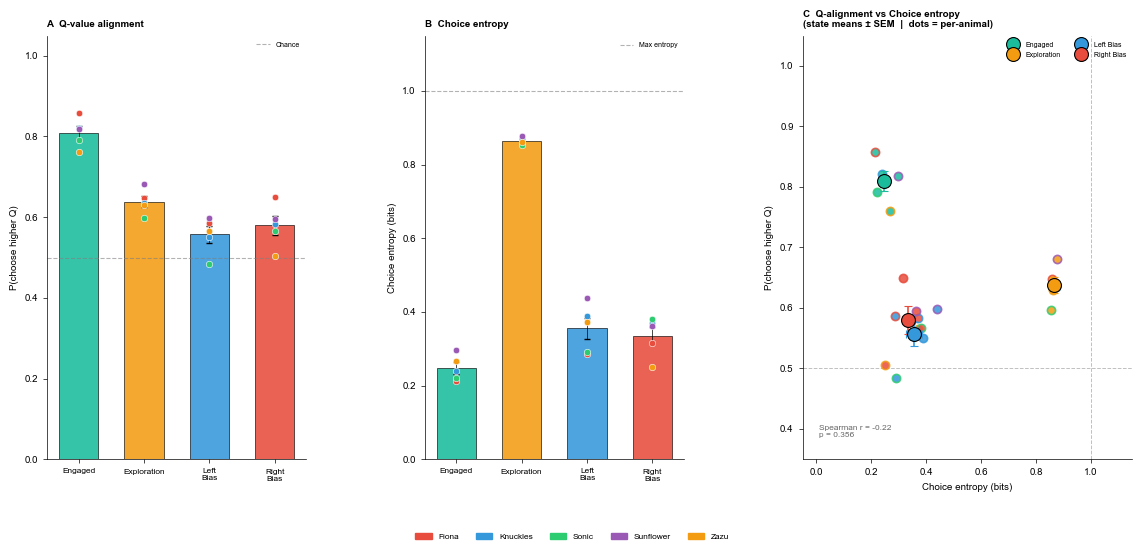

Q-alignment figure saved.


In [105]:
# Q-VALUE ALIGNMENT vs CHOICE ENTROPY BY BEHAVIORAL STATE
# Q-alignment: does the animal choose the higher Q-value option?
# Choice entropy: how random are the choices?
# Prediction: Engaged = high alignment + low entropy
#             Exploration = moderate alignment + high entropy
#             Bias = low alignment + moderate entropy
# ═══════════════════════════════════════════════════════════════════════════════

def compute_q_alignment(sdf):
    valid = sdf[sdf['Q_diff'].abs() > 0]
    if len(valid) == 0:
        return np.nan
    chose_higher = (
        ((valid['Choice_Binary'] == 1) & (valid['Q_diff'] > 0)) |
        ((valid['Choice_Binary'] == 0) & (valid['Q_diff'] < 0))
    )
    return chose_higher.mean()

# ── 1.  Compute per-animal per-state metrics ───────────────────────────────────
df_valid = (
    df_with_states
    .loc[df_with_states[TARGET_V3] != 'Unknown']
    .dropna(subset=['Q_diff', 'Choice_Binary',
                    'Choice_Entropy', 'Rolling_PRight'])
    .copy()
)

rows = []
for animal in animals_ordered:
    adf = df_valid[df_valid['Animal_Name'] == animal]
    for state in CLASSES_V3:
        sdf = adf[adf[TARGET_V3] == state]
        if len(sdf) < 20:
            continue
        rows.append({
            'Animal'       : animal,
            'State'        : state,
            'Q_Alignment'  : compute_q_alignment(sdf),
            'Choice_Entropy': sdf['Choice_Entropy'].mean(),
            'N_trials'     : len(sdf),
        })

df_qa = pd.DataFrame(rows)

# Summary stats
summary = df_qa.groupby('State').agg(
    Q_align_mean   = ('Q_Alignment',   'mean'),
    Q_align_sem    = ('Q_Alignment',   lambda x: sem(x.dropna())),
    Entropy_mean   = ('Choice_Entropy','mean'),
    Entropy_sem    = ('Choice_Entropy', lambda x: sem(x.dropna())),
).reindex(CLASSES_V3)

print("Q-Alignment and Choice Entropy by state:")
print(summary.round(3))

# Correlation across animals × states
r, p = spearmanr(df_qa['Q_Alignment'].dropna(),
                 df_qa['Choice_Entropy'].loc[df_qa['Q_Alignment'].notna()])
print(f"\nSpearman r(Q-align, Entropy) = {r:.3f}, p = {p:.4f}")

# ── 2.  Publication figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5.5))
gs  = gridspec.GridSpec(
    1, 3,
    figure  = fig,
    wspace  = 0.42,
    width_ratios = [1.1, 1.1, 1.4],
)

x     = np.arange(len(CLASSES_V3))
width = 0.6

# ── A: Q-alignment per state ──────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0])

ax_A.bar(x, summary['Q_align_mean'], width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_A.errorbar(x, summary['Q_align_mean'],
              yerr=summary['Q_align_sem'],
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per-animal dots
for animal in animals_ordered:
    adf_q = df_qa[df_qa['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        row = adf_q[adf_q['State'] == state]
        if len(row):
            ax_A.scatter(i, row['Q_Alignment'].values[0],
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

ax_A.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6,
             label='Chance')
ax_A.set_xticks(x)
ax_A.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE - 1)
ax_A.set_ylabel('P(choose higher Q)', fontsize=FONTSIZE)
ax_A.set_ylim(0, 1.05)
ax_A.set_title('A  Q-value alignment',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Choice entropy per state ───────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])

ax_B.bar(x, summary['Entropy_mean'], width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_B.errorbar(x, summary['Entropy_mean'],
              yerr=summary['Entropy_sem'],
              fmt='none', color='black',
              capsize=2, linewidth=LINE_WIDTH, zorder=3)

# Per-animal dots
for animal in animals_ordered:
    adf_q = df_qa[df_qa['Animal'] == animal]
    for i, state in enumerate(CLASSES_V3):
        row = adf_q[adf_q['State'] == state]
        if len(row):
            ax_B.scatter(i, row['Choice_Entropy'].values[0],
                         color=ANIMAL_COLORS[animal],
                         s=22, zorder=5,
                         edgecolors='white', linewidths=0.4)

ax_B.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6,
             label='Max entropy')
ax_B.set_xticks(x)
ax_B.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE - 1)
ax_B.set_ylabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_B.set_ylim(0, 1.15)
ax_B.set_title('B  Choice entropy',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Scatter — Q-alignment vs choice entropy ────────────────────────────────
ax_C = fig.add_subplot(gs[2])

for state in CLASSES_V3:
    sdf_s = df_qa[df_qa['State'] == state].dropna(
        subset=['Q_Alignment', 'Choice_Entropy'])

    # State mean with error ellipse-style crosshair
    m_qa = sdf_s['Q_Alignment'].mean()
    m_ce = sdf_s['Choice_Entropy'].mean()
    s_qa = sem(sdf_s['Q_Alignment'])
    s_ce = sem(sdf_s['Choice_Entropy'])

    # Per-animal dots
    for animal in animals_ordered:
        arow = sdf_s[sdf_s['Animal'] == animal]
        if len(arow):
            ax_C.scatter(
                arow['Choice_Entropy'].values[0],
                arow['Q_Alignment'].values[0],
                color=STATE_COLORS[state],
                s=35, alpha=0.85, zorder=4,
                edgecolors=ANIMAL_COLORS[animal],
                linewidths=1.2
            )

    # State mean ± SEM crosshair
    ax_C.errorbar(m_ce, m_qa,
                  xerr=s_ce, yerr=s_qa,
                  fmt='o', color=STATE_COLORS[state],
                  markersize=10, markeredgecolor='black',
                  markeredgewidth=0.8,
                  capsize=3, linewidth=1.2,
                  zorder=6, label=state)

# Reference lines
ax_C.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
ax_C.axvline(1.0, color='gray', ls='--', lw=0.7, alpha=0.5)

# Spearman annotation
ax_C.text(0.05, 0.05,
          f'Spearman r = {r:.2f}\np = {p:.3f}',
          transform=ax_C.transAxes,
          fontsize=FONTSIZE - 1, va='bottom',
          color='dimgray')

ax_C.set_xlabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_C.set_ylabel('P(choose higher Q)', fontsize=FONTSIZE)
ax_C.set_xlim(-0.05, 1.15)
ax_C.set_ylim(0.35, 1.05)
ax_C.set_title('C  Q-alignment vs Choice entropy\n'
               '(state means ± SEM  |  dots = per-animal)',
               fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE - 2, frameon=False,
            ncol=2, loc='upper right')
ax_C.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE - 1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.05))

# fig.suptitle(
#     'Q-Value Alignment and Choice Entropy by Behavioral State',
#     fontsize=FONTSIZE + 1, fontweight='bold', y=1.02
# )

plt.savefig(f'{FIGURE_PATH}/q_alignment_entropy.svg',
            bbox_inches='tight')
plt.show()
print("Q-alignment figure saved.")

In [40]:
# What does Q_diff look like for bias trials?
bias_df = df_valid[df_valid[TARGET_V3].isin(['Left Bias', 'Right Bias'])]

print("Q_diff distribution in bias states:")
print(bias_df.groupby(TARGET_V3)['Q_diff'].describe().round(3))
print()

# What is the Q-alignment at different deviation thresholds?
print("Q-alignment by Abs_Deviation threshold:")
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    strict = df_valid[df_valid['Abs_Deviation'] >= thresh]
    q_aln  = compute_q_alignment(strict)
    n      = len(strict)
    print(f"  Abs_Dev >= {thresh:.1f}  →  Q-align={q_aln:.3f}  "
          f"N={n}")

print()
# What does Q_diff look like specifically for the most biased trials?
print("Q_diff for highly biased trials (Abs_Dev >= 0.7):")
very_biased = df_valid[df_valid['Abs_Deviation'] >= 0.7]
print(very_biased['Q_diff'].describe().round(3))
print()
print("Q-alignment for very biased trials:")
print(f"  {compute_q_alignment(very_biased):.3f}")

# Also check: are the Q-values even meaningful during bias?
# If Q_diff is near zero, alignment is uninformative
print("\nMean |Q_diff| by state:")
for state in CLASSES_V3:
    sdf = df_valid[df_valid[TARGET_V3] == state]
    print(f"  {state:<15} {sdf['Q_diff'].abs().mean():.3f}")

Q_diff distribution in bias states:
                      count   mean    std  min    25%    50%    75%  max
Behavioral_State_v3                                                     
Left Bias            3736.0  0.011  0.545 -1.0 -0.229  0.000  0.242  1.0
Right Bias           3717.0  0.043  0.541 -1.0 -0.191  0.014  0.281  1.0

Q-alignment by Abs_Deviation threshold:
  Abs_Dev >= 0.3  →  Q-align=0.563  N=12221
  Abs_Dev >= 0.4  →  Q-align=0.561  N=9942
  Abs_Dev >= 0.5  →  Q-align=0.561  N=7453
  Abs_Dev >= 0.6  →  Q-align=0.562  N=7444
  Abs_Dev >= 0.7  →  Q-align=0.643  N=3931
  Abs_Dev >= 0.8  →  Q-align=0.643  N=3931

Q_diff for highly biased trials (Abs_Dev >= 0.7):
count    3931.000
mean        0.042
std         0.551
min        -1.000
25%        -0.211
50%         0.007
75%         0.291
max         1.000
Name: Q_diff, dtype: float64

Q-alignment for very biased trials:
  0.643

Mean |Q_diff| by state:
  Engaged         0.624
  Exploration     0.536
  Left Bias       0.404
  Righ

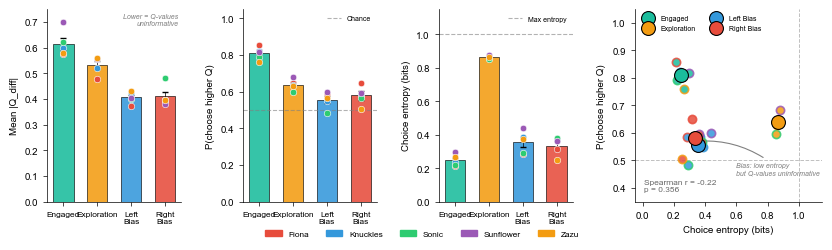

In [106]:
# Add a fourth panel showing mean |Q_diff| per state
# This contextualises why bias alignment is near chance

fig = plt.figure(figsize=(10, 2.5))
gs  = gridspec.GridSpec(
    1, 4,
    figure       = fig,
    wspace       = 0.42,
    width_ratios = [1, 1, 1, 1.4],
)

# ── Compute |Q_diff| per animal per state ─────────────────────────────────────
rows_qdiff = []
for animal in animals_ordered:
    adf = df_valid[df_valid['Animal_Name'] == animal]
    for state in CLASSES_V3:
        sdf = adf[adf[TARGET_V3] == state]
        if len(sdf) < 20:
            continue
        rows_qdiff.append({
            'Animal'      : animal,
            'State'       : state,
            'Q_Alignment' : compute_q_alignment(sdf),
            'Choice_Entropy': sdf['Choice_Entropy'].mean(),
            'Abs_Q_diff'  : sdf['Q_diff'].abs().mean(),
        })
df_qa2 = pd.DataFrame(rows_qdiff)

summary2 = df_qa2.groupby('State').agg(
    Q_align_mean    = ('Q_Alignment',    'mean'),
    Q_align_sem     = ('Q_Alignment',    lambda x: sem(x.dropna())),
    Entropy_mean    = ('Choice_Entropy', 'mean'),
    Entropy_sem     = ('Choice_Entropy', lambda x: sem(x.dropna())),
    AbsQdiff_mean   = ('Abs_Q_diff',     'mean'),
    AbsQdiff_sem    = ('Abs_Q_diff',     lambda x: sem(x.dropna())),
).reindex(CLASSES_V3)

x     = np.arange(len(CLASSES_V3))
width = 0.6

def add_dots(ax, metric, df_qa_in):
    """Add per-animal dots to a bar panel."""
    for animal in animals_ordered:
        adf_a = df_qa_in[df_qa_in['Animal'] == animal]
        for i, state in enumerate(CLASSES_V3):
            row = adf_a[adf_a['State'] == state]
            if len(row):
                ax.scatter(i, row[metric].values[0],
                           color=ANIMAL_COLORS[animal],
                           s=22, zorder=5,
                           edgecolors='white', linewidths=0.4)

# ── A: |Q_diff| per state ─────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0])
ax_A.bar(x, summary2['AbsQdiff_mean'], width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_A.errorbar(x, summary2['AbsQdiff_mean'],
              yerr=summary2['AbsQdiff_sem'],
              fmt='none', color='black', capsize=2,
              linewidth=LINE_WIDTH, zorder=3)
add_dots(ax_A, 'Abs_Q_diff', df_qa2)
ax_A.set_xticks(x)
ax_A.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE - 1)
ax_A.set_ylabel('Mean |Q_diff|', fontsize=FONTSIZE)
ax_A.set_ylim(0, 0.75)
# ax_A.set_title('A  Q-value signal strength\n(|Q_left − Q_right|)',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_A.text(0.98, 0.98,
          'Lower = Q-values\nuninformative',
          transform=ax_A.transAxes,
          fontsize=FONTSIZE - 2, color='gray',
          ha='right', va='top', style='italic')
ax_A.spines[['top', 'right']].set_visible(False)

# ── B: Q-alignment ────────────────────────────────────────────────────────────
ax_B = fig.add_subplot(gs[1])
ax_B.bar(x, summary2['Q_align_mean'], width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_B.errorbar(x, summary2['Q_align_mean'],
              yerr=summary2['Q_align_sem'],
              fmt='none', color='black', capsize=2,
              linewidth=LINE_WIDTH, zorder=3)
add_dots(ax_B, 'Q_Alignment', df_qa2)
ax_B.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6, label='Chance')
ax_B.set_xticks(x)
ax_B.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE - 1)
ax_B.set_ylabel('P(choose higher Q)', fontsize=FONTSIZE)
ax_B.set_ylim(0, 1.05)
# ax_B.set_title('B  Q-value alignment',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_B.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_B.spines[['top', 'right']].set_visible(False)

# ── C: Choice entropy ─────────────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[2])
ax_C.bar(x, summary2['Entropy_mean'], width,
         color=[STATE_COLORS[s] for s in CLASSES_V3],
         edgecolor='black', linewidth=LINE_WIDTH, alpha=0.88, zorder=2)
ax_C.errorbar(x, summary2['Entropy_mean'],
              yerr=summary2['Entropy_sem'],
              fmt='none', color='black', capsize=2,
              linewidth=LINE_WIDTH, zorder=3)
add_dots(ax_C, 'Choice_Entropy', df_qa2)
ax_C.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='Max entropy')
ax_C.set_xticks(x)
ax_C.set_xticklabels([s.replace(' ', '\n') for s in CLASSES_V3],
                     fontsize=FONTSIZE - 1)
ax_C.set_ylabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_C.set_ylim(0, 1.15)
# ax_C.set_title('C  Choice entropy',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_C.legend(fontsize=FONTSIZE - 2, frameon=False)
ax_C.spines[['top', 'right']].set_visible(False)

# ── D: Scatter Q-alignment vs entropy ────────────────────────────────────────
ax_D = fig.add_subplot(gs[3])

for state in CLASSES_V3:
    sdf_s = df_qa2[df_qa2['State'] == state].dropna(
        subset=['Q_Alignment', 'Choice_Entropy'])
    m_qa  = sdf_s['Q_Alignment'].mean()
    m_ce  = sdf_s['Choice_Entropy'].mean()
    s_qa  = sem(sdf_s['Q_Alignment'])
    s_ce  = sem(sdf_s['Choice_Entropy'])

    for animal in animals_ordered:
        arow = sdf_s[sdf_s['Animal'] == animal]
        if len(arow):
            ax_D.scatter(
                arow['Choice_Entropy'].values[0],
                arow['Q_Alignment'].values[0],
                color=STATE_COLORS[state], s=35,
                alpha=0.85, zorder=4,
                edgecolors=ANIMAL_COLORS[animal],
                linewidths=1.2
            )
    ax_D.errorbar(m_ce, m_qa, xerr=s_ce, yerr=s_qa,
                  fmt='o', color=STATE_COLORS[state],
                  markersize=10,
                  markeredgecolor='black', markeredgewidth=0.8,
                  capsize=3, linewidth=1.2, zorder=6, label=state)

ax_D.axhline(0.5, color='gray', ls='--', lw=0.7, alpha=0.5)
ax_D.axvline(1.0, color='gray', ls='--', lw=0.7, alpha=0.5)

r2, p2 = spearmanr(
    df_qa2['Q_Alignment'].dropna(),
    df_qa2['Choice_Entropy'].loc[df_qa2['Q_Alignment'].notna()]
)
ax_D.text(0.05, 0.05,
          f'Spearman r = {r2:.2f}\np = {p2:.3f}',
          transform=ax_D.transAxes,
          fontsize=FONTSIZE - 1, va='bottom', color='dimgray')

# Annotate the key finding
ax_D.annotate(
    'Bias: low entropy\nbut Q-values uninformative',
    xy=(0.35, 0.57), xytext=(0.60, 0.45),
    fontsize=FONTSIZE - 2, color='gray', style='italic',
    arrowprops=dict(arrowstyle='->', color='gray',
                    lw=0.8, connectionstyle='arc3,rad=0.2')
)

ax_D.set_xlabel('Choice entropy (bits)', fontsize=FONTSIZE)
ax_D.set_ylabel('P(choose higher Q)', fontsize=FONTSIZE)
ax_D.set_xlim(-0.05, 1.15)
ax_D.set_ylim(0.35, 1.05)
# ax_D.set_title('D  Q-alignment vs Choice entropy\n'
#                '(state means ± SEM  |  dots = per-animal)',
#                fontsize=FONTSIZE, fontweight='bold', loc='left')
ax_D.legend(fontsize=FONTSIZE - 2, frameon=False, ncol=2)
ax_D.spines[['top', 'right']].set_visible(False)

# ── Animal legend ─────────────────────────────────────────────────────────────
handles_a = [mpatches.Patch(color=ANIMAL_COLORS[a], label=a)
             for a in animals_ordered]
fig.legend(handles=handles_a,
           fontsize=FONTSIZE - 1, frameon=False,
           ncol=len(animals_ordered),
           loc='lower center',
           bbox_to_anchor=(0.5, -0.06))

# fig.suptitle(
#     'Q-Value Alignment and Choice Entropy by Behavioral State\n'
#     'Bias states: strong spatial policy not captured by RL model',
#     fontsize=FONTSIZE + 1, fontweight='bold', y=1.04
# )

plt.savefig(f'{FIGURE_PATH}/q_alignment_entropy_v2.svg',
            bbox_inches='tight')
plt.show()

In [112]:
# Check the actual distribution of switch rates for Engaged trials
engaged = df_with_states[df_with_states[TARGET_V3] == 'Engaged']

print("Rolling_Switch_Rate distribution for Engaged (v3 labels):")
print(engaged['Rolling_Switch_Rate'].value_counts(normalize=True)
      .sort_index().round(3))

print("\nRolling_Switch_Rate distribution for HMM Engaged:")
hmm_engaged = df_hmm[df_hmm['HMM_3State'] == 'Engaged']
print(hmm_engaged['Rolling_Switch_Rate'].value_counts(normalize=True)
      .sort_index().round(3))

print("\nMean switch rate:")
print(f"  v3  Engaged: {engaged['Rolling_Switch_Rate'].mean():.3f}")
print(f"  HMM Engaged: {hmm_engaged['Rolling_Switch_Rate'].mean():.3f}")

Rolling_Switch_Rate distribution for Engaged (v3 labels):
Rolling_Switch_Rate
0.0    0.599
0.2    0.401
Name: proportion, dtype: float64

Rolling_Switch_Rate distribution for HMM Engaged:
Rolling_Switch_Rate
0.0    1.0
Name: proportion, dtype: float64

Mean switch rate:
  v3  Engaged: 0.080
  HMM Engaged: 0.000
